In [1]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
# read in the cleaned CSV with data from central valley stations
path = 'E:/Central Valley Fog/CV_all_rows_wind_codes_temp.csv'
if os.path.exists(path):
    CV_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/CV_all_rows_wind_codes_temp.csv'
    CV_rows = pd.read_csv(path, low_memory = False)

print(CV_rows)

           STATION_ID  LATITUDE  LONGITUDE                 DATE REPORT_TYPE  \
0         USM00074917   35.1170  -119.3000  1941-12-01 00:00:00         SAO   
1         USM00074917   35.1170  -119.3000  1941-12-01 01:00:00         SAO   
2         USM00074917   35.1170  -119.3000  1941-12-01 02:00:00         SAO   
3         USM00074917   35.1170  -119.3000  1941-12-01 03:00:00         SAO   
4         USM00074917   35.1170  -119.3000  1941-12-01 04:00:00         SAO   
...               ...       ...        ...                  ...         ...   
14495830  USW00024257   40.5175  -122.2986  2026-06-20 04:53:00       FM-15   
14495831  USW00024257   40.5175  -122.2986  2026-06-20 05:53:00       FM-15   
14495832  USW00024257   40.5175  -122.2986  2026-06-20 06:53:00       FM-15   
14495833  USW00024257   40.5175  -122.2986  2026-06-20 07:53:00       FM-15   
14495834  USW00024257   40.5175  -122.2986  2026-06-20 08:53:00       FM-15   

          HourlyDewPointTemperature  HourlyDryBulbT

In [3]:
# Exclude days from April through October (months 4-10) in CV_rows
CV_rows = CV_rows[~CV_rows['month'].isin([4, 5, 6, 7, 8, 9, 10])]

print("CV_rows after removing April-October:", CV_rows.shape)

CV_rows after removing April-October: (6404926, 19)


In [4]:
# filtering based on precipitation
# filtering visibility threshold to identify outliers

CV_filtered_rows = CV_rows[CV_rows["HourlyVisibility"] < 17.000]


print("CV_filtered_rows:", CV_filtered_rows.shape)

CV_filtered_rows: (4815127, 19)


In [5]:
CV_filtered_rows['HourlyDewpointDepression'] = (
    CV_filtered_rows['HourlyDryBulbTemperature'] - CV_filtered_rows['HourlyDewPointTemperature']
)

CV_filtered_rows[['HourlyDryBulbTemperature', 'HourlyDewPointTemperature', 'HourlyDewpointDepression']].head()

,HourlyDryBulbTemperature,HourlyDewPointTemperature,HourlyDewpointDepression
0,13.0,11.9,1.1
1,12.4,10.7,1.7
2,12.4,11.3,1.1
3,12.4,11.3,1.1
4,13.0,11.9,1.1


In [6]:
negative_dewpoint_depressions = CV_filtered_rows[
    CV_filtered_rows["HourlyDewpointDepression"] < 0
].copy()

print("Rows with dewpoint depression < 0:", len(negative_dewpoint_depressions))
display(negative_dewpoint_depressions)

Rows with dewpoint depression < 0: 2124


,STATION_ID,LATITUDE,LONGITUDE,DATE,REPORT_TYPE,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyPrecipitation,HourlyPresentWeatherType,HourlySkyConditions,HourlyVisibility,HourlyWindDirection,HourlyWindSpeed,year,month,day,hour,minute,STATION,HourlyDewpointDepression
1013948,USW00053125,36.73333,-119.8000,1933-01-05 02:00:00,WBO_F,5.0,4.9,0.0,||13,OVC:08,1.609,315.0,3.1,1933,1,5,2,0,FRESNO,-0.1
1013949,USW00053125,36.73333,-119.8000,1933-01-05 05:00:00,WBO_F,5.0,4.9,0.0,||13,NaN,1.609,315.0,3.1,1933,1,5,5,0,FRESNO,-0.1
1015698,USW00053125,36.73333,-119.8000,1933-12-21 02:00:00,WBO_F,3.3,3.1,0.0,||13,OVC:08,1.609,315.0,0.9,1933,12,21,2,0,FRESNO,-0.2
1015699,USW00053125,36.73333,-119.8000,1933-12-21 05:00:00,WBO_F,3.3,3.1,0.0,||13,NaN,1.609,315.0,0.9,1933,12,21,5,0,FRESNO,-0.2
1015723,USW00053125,36.73333,-119.8000,1933-12-26 02:00:00,WBO_F,1.7,1.4,0.0,||13,OVC:08,0.000,90.0,1.3,1933,12,26,2,0,FRESNO,-0.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14152628,USW00024257,40.51750,-122.2986,1997-12-06 19:00:00,FM-15,10.6,10.0,0.0,||RA FG RA,OVC:08 2.40,4.800,80.0,2.1,1997,12,6,19,0,REDDING AP,-0.6
14268221,USW00024257,40.51750,-122.2986,2007-11-10 16:47:00,FM-15,11.0,1.0,0.0,BR:1 ||,FEW:02 OVC:08,2.414,0.0,0.0,2007,11,10,16,47,REDDING AP,-10.0
14354914,USW00024257,40.51750,-122.2986,2015-02-03 05:58:00,FM-16,2.0,1.0,0.0,BR:1 ||BR,NaN,2.414,0.0,0.0,2015,2,3,5,58,REDDING AP,-1.0
14402781,USW00024257,40.51750,-122.2986,2019-01-11 19:53:00,FM-15,18.0,11.0,0.0,NaN,FEW:02 18.29 SCT:04 22.86 OVC:08 27.43,16.000,80.0,2.1,2019,1,11,19,53,REDDING AP,-7.0


In [7]:
CV_filtered_rows["HourlyDewpointDepression"] = (
    CV_filtered_rows["HourlyDewpointDepression"].clip(lower=0)
)

print(CV_filtered_rows["HourlyDewpointDepression"].min())

0.0


In [8]:
CV_fog_rows = CV_filtered_rows[
    (CV_filtered_rows["HourlyVisibility"] < 1.000)
    & (CV_filtered_rows["HourlyPrecipitation"] < 0.03)
]

print("CV_fog_rows:", CV_fog_rows.shape)

CV_fog_rows: (263418, 20)


In [9]:
# # Remove outlier rows based on dewpoint depression using the IQR rule

# dd_col = "HourlyDewpointDepression"

# valid_dd = CV_fog_rows[dd_col].dropna()

# q1 = valid_dd.quantile(0.25)
# q3 = valid_dd.quantile(0.75)
# iqr = q3 - q1

# lower_bound = q1 - 1.5 * iqr
# upper_bound = q3 + 1.5 * iqr

# rows_before = len(CV_fog_rows)

# CV_fog_rows = CV_fog_rows[
#     CV_fog_rows[dd_col].between(lower_bound, upper_bound, inclusive="both")
# ].copy()

# print(f"IQR bounds: {lower_bound:.3f} to {upper_bound:.3f} °C")
# print(f"Rows before filtering: {rows_before}")
# print(f"Rows after filtering: {len(CV_fog_rows)}")
# print(f"Rows removed: {rows_before - len(CV_fog_rows)}")

In [10]:
# # Dewpoint depression for each fog observation (fog event row)
fog_events = CV_fog_rows.dropna(
    subset=["HourlyDryBulbTemperature", "HourlyDewPointTemperature"]
).copy()

fog_events["HourlyDewpointDepression"] = (
    fog_events["HourlyDryBulbTemperature"] - fog_events["HourlyDewPointTemperature"]
)

fog_events["HourlyDewpointDepression"] = (
    fog_events["HourlyDewpointDepression"].clip(lower=0, upper=6)
)

fog_events["DATE"] = pd.to_datetime(fog_events["DATE"], errors="coerce")
fog_events = fog_events.sort_values(["STATION", "DATE"])

fog_event_dd = fog_events[
    ["STATION", "DATE", "HourlyVisibility",
     "HourlyDryBulbTemperature", "HourlyDewPointTemperature",
     "HourlyDewpointDepression"]
]

print(fog_event_dd.head(20))
print("Total fog events with dewpoint depression:", len(fog_event_dd))

                STATION                DATE  HourlyVisibility  \
6109682  BAKERSFIELD AP 1930-01-23 07:00:00               0.0   
6109683  BAKERSFIELD AP 1930-01-23 08:00:00               0.0   
6109684  BAKERSFIELD AP 1930-01-23 09:00:00               0.0   
6109685  BAKERSFIELD AP 1930-01-23 10:00:00               0.8   
6109695  BAKERSFIELD AP 1930-01-24 07:00:00               0.0   
6109696  BAKERSFIELD AP 1930-01-24 08:00:00               0.0   
6109697  BAKERSFIELD AP 1930-01-24 09:00:00               0.0   
6109698  BAKERSFIELD AP 1930-01-24 10:00:00               0.2   
6109699  BAKERSFIELD AP 1930-01-24 11:00:00               0.8   
6109735  BAKERSFIELD AP 1930-01-27 08:00:00               0.8   
6109736  BAKERSFIELD AP 1930-01-27 09:00:00               0.4   
6110357  BAKERSFIELD AP 1930-03-15 07:00:00               0.4   
6115712  BAKERSFIELD AP 1930-11-28 05:00:00               0.8   
6115715  BAKERSFIELD AP 1930-11-28 08:00:00               0.8   
6115733  BAKERSFIELD AP 1

In [11]:
# Count unique fog days per station-year while varying the maximum hourly wind speed.
# Dewpoint depression criterion remains fixed at < 4.6 °C.

ideal_source = CV_filtered_rows.copy()

ideal_source["DATE"] = pd.to_datetime(ideal_source["DATE"], errors="coerce")
ideal_source["HourlyWindSpeed"] = pd.to_numeric(
    ideal_source["HourlyWindSpeed"], errors="coerce"
)

ideal_source["HourlyDewpointDepression"] = (
    ideal_source["HourlyDryBulbTemperature"]
    - ideal_source["HourlyDewPointTemperature"]
).clip(lower=0)

ideal_source["fog_date"] = ideal_source["DATE"].dt.normalize()
ideal_source["year"] = ideal_source["DATE"].dt.year

ideal_source = ideal_source.dropna(
    subset=[
        "STATION",
        "DATE",
        "fog_date",
        "year",
        "HourlyDewpointDepression",
        "HourlyWindSpeed",
    ]
)

wind_speed_limits = np.arange(0.5, 7.01, 0.5)
results = []

for wind_limit in wind_speed_limits:
    qualifying_days = ideal_source[
        (ideal_source["HourlyDewpointDepression"] < 2)
        & (ideal_source["HourlyWindSpeed"] <= wind_limit)
    ]

    annual_days = (
        qualifying_days
        .drop_duplicates(["STATION", "year", "fog_date"])
        .groupby(["STATION", "year"], as_index=False)
        .size()
        .rename(columns={"size": "ideal_fog_days"})
    )

    annual_days["max_wind_speed"] = wind_limit
    results.append(annual_days)

ideal_fog_days_by_wind = (
    pd.concat(results, ignore_index=True)
    .sort_values(["max_wind_speed", "STATION", "year"])
    .reset_index(drop=True)
)

print(ideal_fog_days_by_wind.head(20))

# Wide-format table: rows = station-year, columns = wind-speed criterion
ideal_fog_days_pivot = (
    ideal_fog_days_by_wind
    .pivot_table(
        index=["STATION", "year"],
        columns="max_wind_speed",
        values="ideal_fog_days",
        fill_value=0
    )
    .rename_axis(columns="Max hourly wind speed")
    .reset_index()
)

display(ideal_fog_days_pivot)

           STATION  year  ideal_fog_days  max_wind_speed
0   BAKERSFIELD AP  1930              13             0.5
1   BAKERSFIELD AP  1931              44             0.5
2   BAKERSFIELD AP  1932              40             0.5
3   BAKERSFIELD AP  1933              39             0.5
4   BAKERSFIELD AP  1934              50             0.5
5   BAKERSFIELD AP  1935              51             0.5
6   BAKERSFIELD AP  1936              22             0.5
7   BAKERSFIELD AP  1937              18             0.5
8   BAKERSFIELD AP  1938              36             0.5
9   BAKERSFIELD AP  1939              22             0.5
10  BAKERSFIELD AP  1940              23             0.5
11  BAKERSFIELD AP  1941              19             0.5
12  BAKERSFIELD AP  1942              21             0.5
13  BAKERSFIELD AP  1943              20             0.5
14  BAKERSFIELD AP  1944              21             0.5
15  BAKERSFIELD AP  1945              27             0.5
16  BAKERSFIELD AP  1946       

Max hourly wind speed,STATION,year,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0,5.5,6.0,6.5,7.0
0,BAKERSFIELD AP,1930,13.0,16.0,21.0,23.0,24.0,28.0,28.0,29.0,30.0,30.0,30.0,30.0,31.0,32.0
1,BAKERSFIELD AP,1931,44.0,63.0,70.0,74.0,78.0,79.0,79.0,79.0,80.0,81.0,81.0,81.0,81.0,82.0
2,BAKERSFIELD AP,1932,40.0,54.0,71.0,86.0,98.0,101.0,103.0,103.0,103.0,103.0,103.0,103.0,103.0,103.0
3,BAKERSFIELD AP,1933,39.0,51.0,66.0,68.0,73.0,77.0,82.0,83.0,84.0,85.0,85.0,85.0,85.0,86.0
4,BAKERSFIELD AP,1934,50.0,74.0,85.0,89.0,91.0,94.0,96.0,96.0,96.0,96.0,96.0,96.0,96.0,96.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1249,WILLIAMS CAA AIRPORT,1948,18.0,23.0,32.0,32.0,33.0,34.0,34.0,35.0,35.0,35.0,35.0,35.0,35.0,35.0
1250,WILLIAMS CAA AIRPORT,1949,40.0,58.0,82.0,82.0,90.0,93.0,100.0,103.0,103.0,103.0,105.0,106.0,106.0,107.0
1251,WILLIAMS CAA AIRPORT,1950,53.0,63.0,103.0,103.0,106.0,109.0,113.0,115.0,121.0,121.0,121.0,122.0,123.0,123.0
1252,WILLIAMS CAA AIRPORT,1951,39.0,53.0,79.0,79.0,94.0,101.0,105.0,108.0,108.0,109.0,111.0,112.0,112.0,114.0


In [12]:
# Add observed fog-day counts to the station-year pivot table

fog_days_per_station_year = (
    CV_fog_rows.assign(
        fog_date=pd.to_datetime(CV_fog_rows["DATE"], errors="coerce").dt.normalize()
    )
    .dropna(subset=["STATION", "fog_date"])
    .assign(year=lambda df: df["fog_date"].dt.year)
    .drop_duplicates(["STATION", "year", "fog_date"])
    .groupby(["STATION", "year"], as_index=False)
    .size()
    .rename(columns={"size": "fog_days"})
)

ideal_fog_days_station_pivot = ideal_fog_days_pivot.merge(
    fog_days_per_station_year,
    on=["STATION", "year"],
    how="left"
)

ideal_fog_days_station_pivot["fog_days"] = (
    ideal_fog_days_station_pivot["fog_days"].fillna(0).astype(int)
)

display(ideal_fog_days_station_pivot)

,STATION,year,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0,5.5,6.0,6.5,7.0,fog_days
0,BAKERSFIELD AP,1930,13.0,16.0,21.0,23.0,24.0,28.0,28.0,29.0,30.0,30.0,30.0,30.0,31.0,32.0,14
1,BAKERSFIELD AP,1931,44.0,63.0,70.0,74.0,78.0,79.0,79.0,79.0,80.0,81.0,81.0,81.0,81.0,82.0,23
2,BAKERSFIELD AP,1932,40.0,54.0,71.0,86.0,98.0,101.0,103.0,103.0,103.0,103.0,103.0,103.0,103.0,103.0,15
3,BAKERSFIELD AP,1933,39.0,51.0,66.0,68.0,73.0,77.0,82.0,83.0,84.0,85.0,85.0,85.0,85.0,86.0,18
4,BAKERSFIELD AP,1934,50.0,74.0,85.0,89.0,91.0,94.0,96.0,96.0,96.0,96.0,96.0,96.0,96.0,96.0,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1249,WILLIAMS CAA AIRPORT,1948,18.0,23.0,32.0,32.0,33.0,34.0,34.0,35.0,35.0,35.0,35.0,35.0,35.0,35.0,13
1250,WILLIAMS CAA AIRPORT,1949,40.0,58.0,82.0,82.0,90.0,93.0,100.0,103.0,103.0,103.0,105.0,106.0,106.0,107.0,24
1251,WILLIAMS CAA AIRPORT,1950,53.0,63.0,103.0,103.0,106.0,109.0,113.0,115.0,121.0,121.0,121.0,122.0,123.0,123.0,30
1252,WILLIAMS CAA AIRPORT,1951,39.0,53.0,79.0,79.0,94.0,101.0,105.0,108.0,108.0,109.0,111.0,112.0,112.0,114.0,33


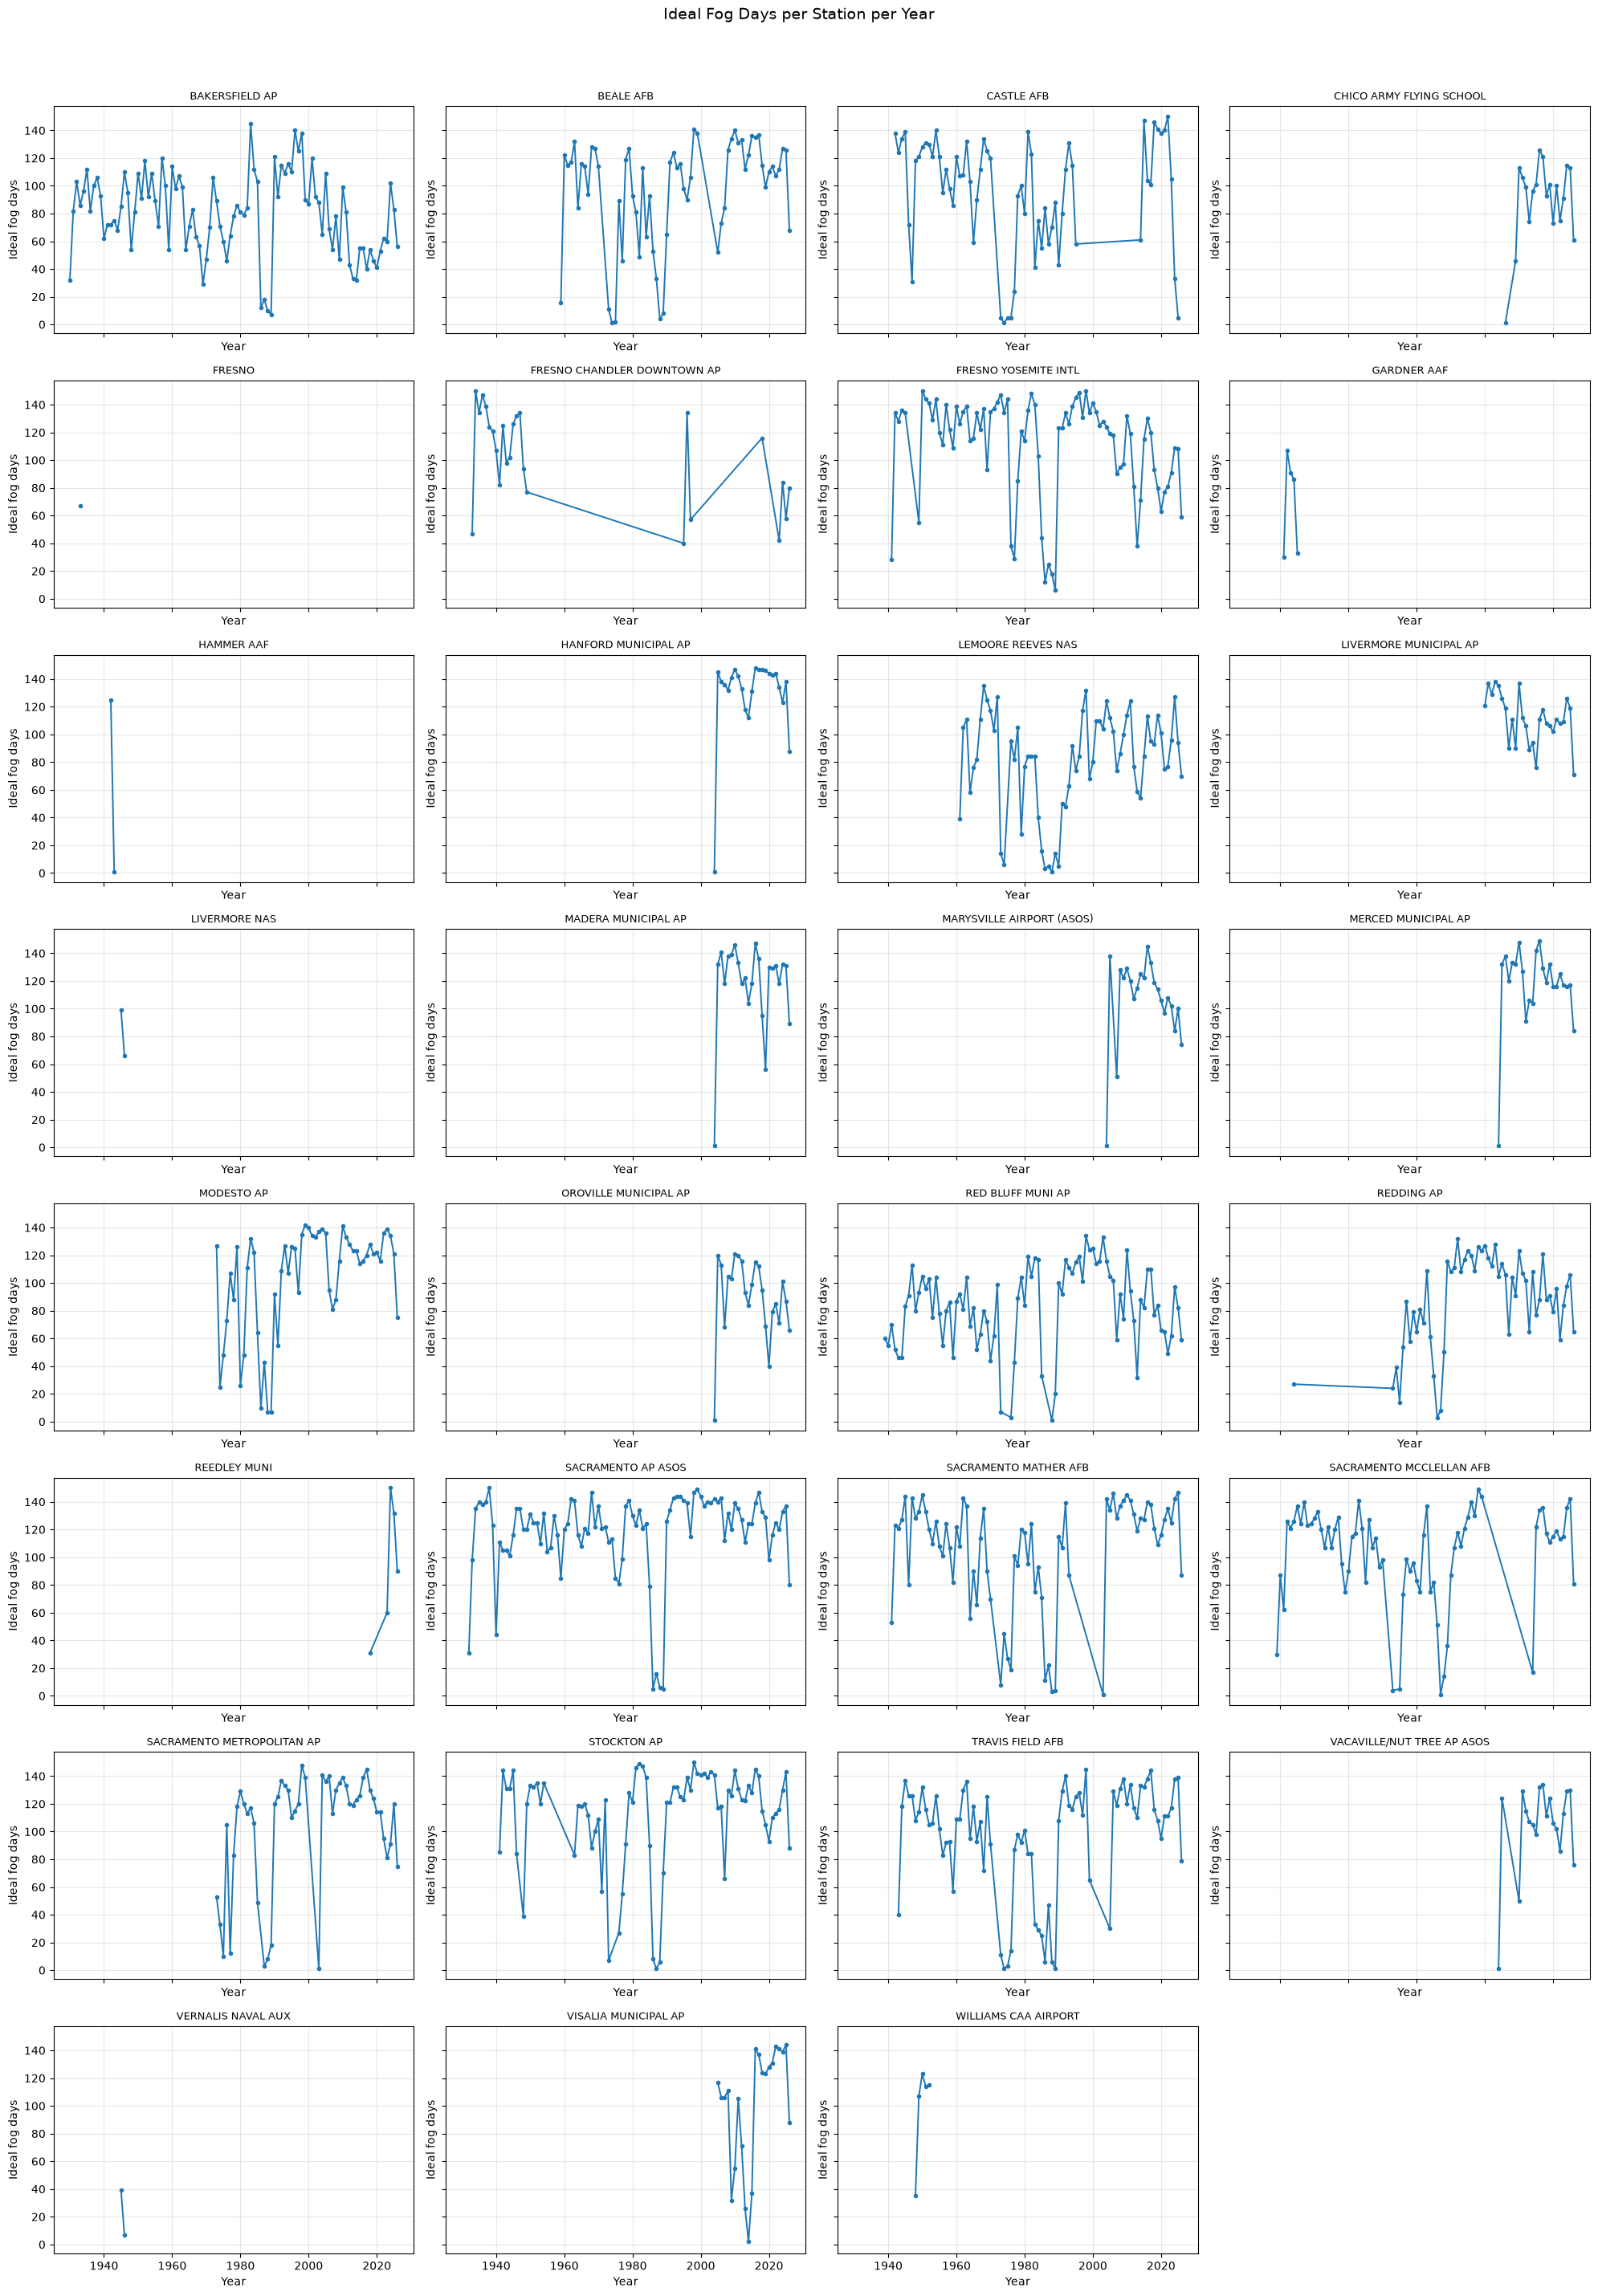

In [13]:
# Plot ideal fog days per station per year
# Use annual_days if present; otherwise use ideal_fog_days_by_wind and focus on the max wind threshold
if "annual_days" in globals():
    plot_df = annual_days.copy()
elif "ideal_fog_days_by_wind" in globals():
    plot_df = ideal_fog_days_by_wind.copy()
else:
    raise ValueError("No annual_days or ideal_fog_days_by_wind variable is available.")

# Clean and prepare
plot_df = plot_df.dropna(subset=["STATION", "year", "ideal_fog_days"]).copy()
plot_df["year"] = pd.to_numeric(plot_df["year"], errors="coerce")
plot_df["ideal_fog_days"] = pd.to_numeric(plot_df["ideal_fog_days"], errors="coerce")
plot_df = plot_df.dropna(subset=["year", "ideal_fog_days"])

# If the source contains multiple wind-speed thresholds, plot the highest threshold by default
# or the 7.0 m/s threshold if it exists.
if "max_wind_speed" in plot_df.columns:
    wind_values = sorted(plot_df["max_wind_speed"].dropna().unique())
    if 7.0 in wind_values:
        plot_df = plot_df[plot_df["max_wind_speed"] == 7.0].copy()
    elif len(wind_values) > 1:
        plot_df = plot_df[plot_df["max_wind_speed"] == wind_values[-1]].copy()

plot_df = plot_df.sort_values(["STATION", "year"]).reset_index(drop=True)

stations = sorted(plot_df["STATION"].unique())
ncols = 4
nrows = int(np.ceil(len(stations) / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5 * ncols, 3.5 * nrows),
    sharex=True,
    sharey=True
)
axes = np.asarray(axes).reshape(-1)

for i, station_name in enumerate(stations):
    ax = axes[i]
    g = plot_df[plot_df["STATION"] == station_name].sort_values("year")

    ax.plot(
        g["year"],
        g["ideal_fog_days"],
        marker="o",
        markersize=3,
        linewidth=1.4
    )
    ax.set_title(station_name, fontsize=9)
    ax.set_xlabel("Year")
    ax.set_ylabel("Ideal fog days")
    ax.grid(alpha=0.3)

for ax in axes[len(stations):]:
    ax.axis("off")

fig.suptitle(
    "Ideal Fog Days per Station per Year",
    y=1.02,
    fontsize=14
)
plt.tight_layout()
plt.show()

In [14]:
# filter out rows without both temperature and dewpoint values
CV_fog_rows = CV_fog_rows.dropna(subset=["HourlyDryBulbTemperature", "HourlyDewPointTemperature"])

# Set minimum values below zero to zero and maximum values above 6 to 6 for dewpoint depression
CV_fog_rows["HourlyDewpointDepression"] = CV_fog_rows["HourlyDewpointDepression"].clip(lower=0, upper=6)

monthly_station = (
    CV_fog_rows.groupby(["STATION", "year", "month"], as_index=False)["HourlyDewpointDepression"]
    .mean()
    .sort_values(["STATION", "year", "month"])
)

In [15]:
# Annual mean dewpoint depression by station/year
annual_station = (
    monthly_station.groupby(["STATION", "year"], as_index=False)["HourlyDewpointDepression"]
    .mean()
)

# Keep stations with >30 unique years of annual data
year_counts = annual_station.groupby("STATION")["year"].nunique()
eligible_stations_30 = year_counts[year_counts > 30].index

Total fog-event observations with dewpoint depression < 1 °C: 180663
          STATION  year  fog_events_gt1
0  BAKERSFIELD AP  1930              39
1  BAKERSFIELD AP  1931              80
2  BAKERSFIELD AP  1932              49
3  BAKERSFIELD AP  1933             163
4  BAKERSFIELD AP  1934             204


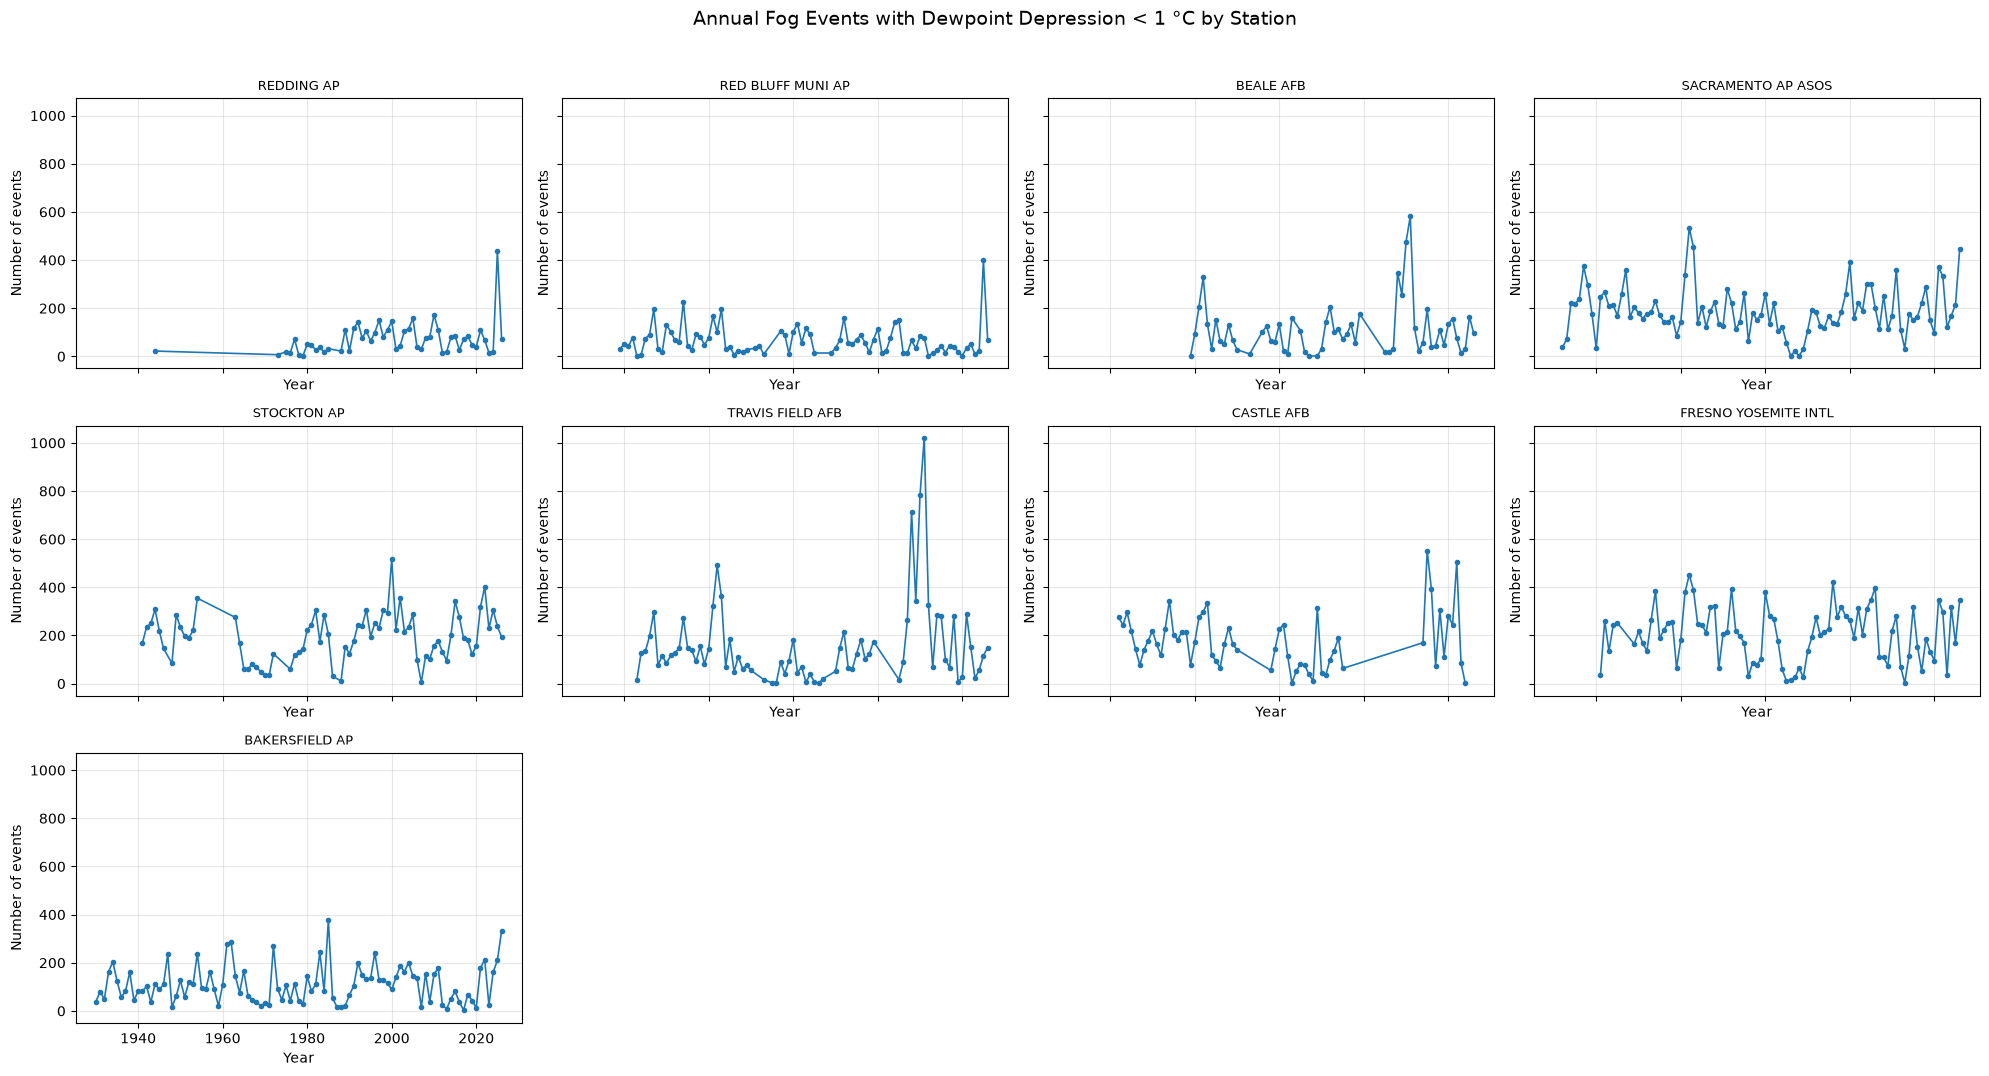

In [16]:
# Count fog-event observations with dewpoint depression < 1 °C
fog_events_gt1 = fog_event_dd.copy()
fog_events_gt1["DATE"] = pd.to_datetime(fog_events_gt1["DATE"], errors="coerce")
fog_events_gt1 = fog_events_gt1.dropna(
    subset=["DATE", "HourlyDewpointDepression"]
)

fog_events_gt1 = fog_events_gt1[
    fog_events_gt1["HourlyDewpointDepression"] < 1
].copy()

fog_events_gt1["year"] = fog_events_gt1["DATE"].dt.year

annual_events_gt1 = (
    fog_events_gt1.groupby(["STATION", "year"])
    .size()
    .reset_index(name="fog_events_gt1")
)

print("Total fog-event observations with dewpoint depression < 1 °C:",
      len(fog_events_gt1))
print(annual_events_gt1.head())

# Plot counts by year for each station
# stations = sorted(annual_events_gt1["STATION"].unique())
stations = ["REDDING AP", "RED BLUFF MUNI AP", "BEALE AFB", "SACRAMENTO AP ASOS", "STOCKTON AP", "TRAVIS FIELD AFB", "CASTLE AFB", "FRESNO YOSEMITE INTL", "BAKERSFIELD AP"]
ncols = 4
nrows = int(np.ceil(len(stations) / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5 * ncols, 3.5 * nrows),
    sharex=True,
    sharey=True
)
axes = np.asarray(axes).reshape(-1)

for i, station in enumerate(stations):
    ax = axes[i]
    data = annual_events_gt1[
        annual_events_gt1["STATION"] == station
    ].sort_values("year")

    ax.plot(
        data["year"],
        data["fog_events_gt1"],
        marker="o",
        markersize=3,
        linewidth=1.2
    )
    ax.set_title(station, fontsize=9)
    ax.set_xlabel("Year")
    ax.set_ylabel("Number of events")
    ax.grid(alpha=0.3)

for ax in axes[len(stations):]:
    ax.axis("off")

fig.suptitle(
    "Annual Fog Events with Dewpoint Depression < 1 °C by Station",
    y=1.02,
    fontsize=14
)
plt.tight_layout()
plt.show()

          STATION  year  fog_days_gt1
0  BAKERSFIELD AP  1930            12
1  BAKERSFIELD AP  1931            23
2  BAKERSFIELD AP  1932            15
3  BAKERSFIELD AP  1933            18
4  BAKERSFIELD AP  1934            39
Total fog days: 27643


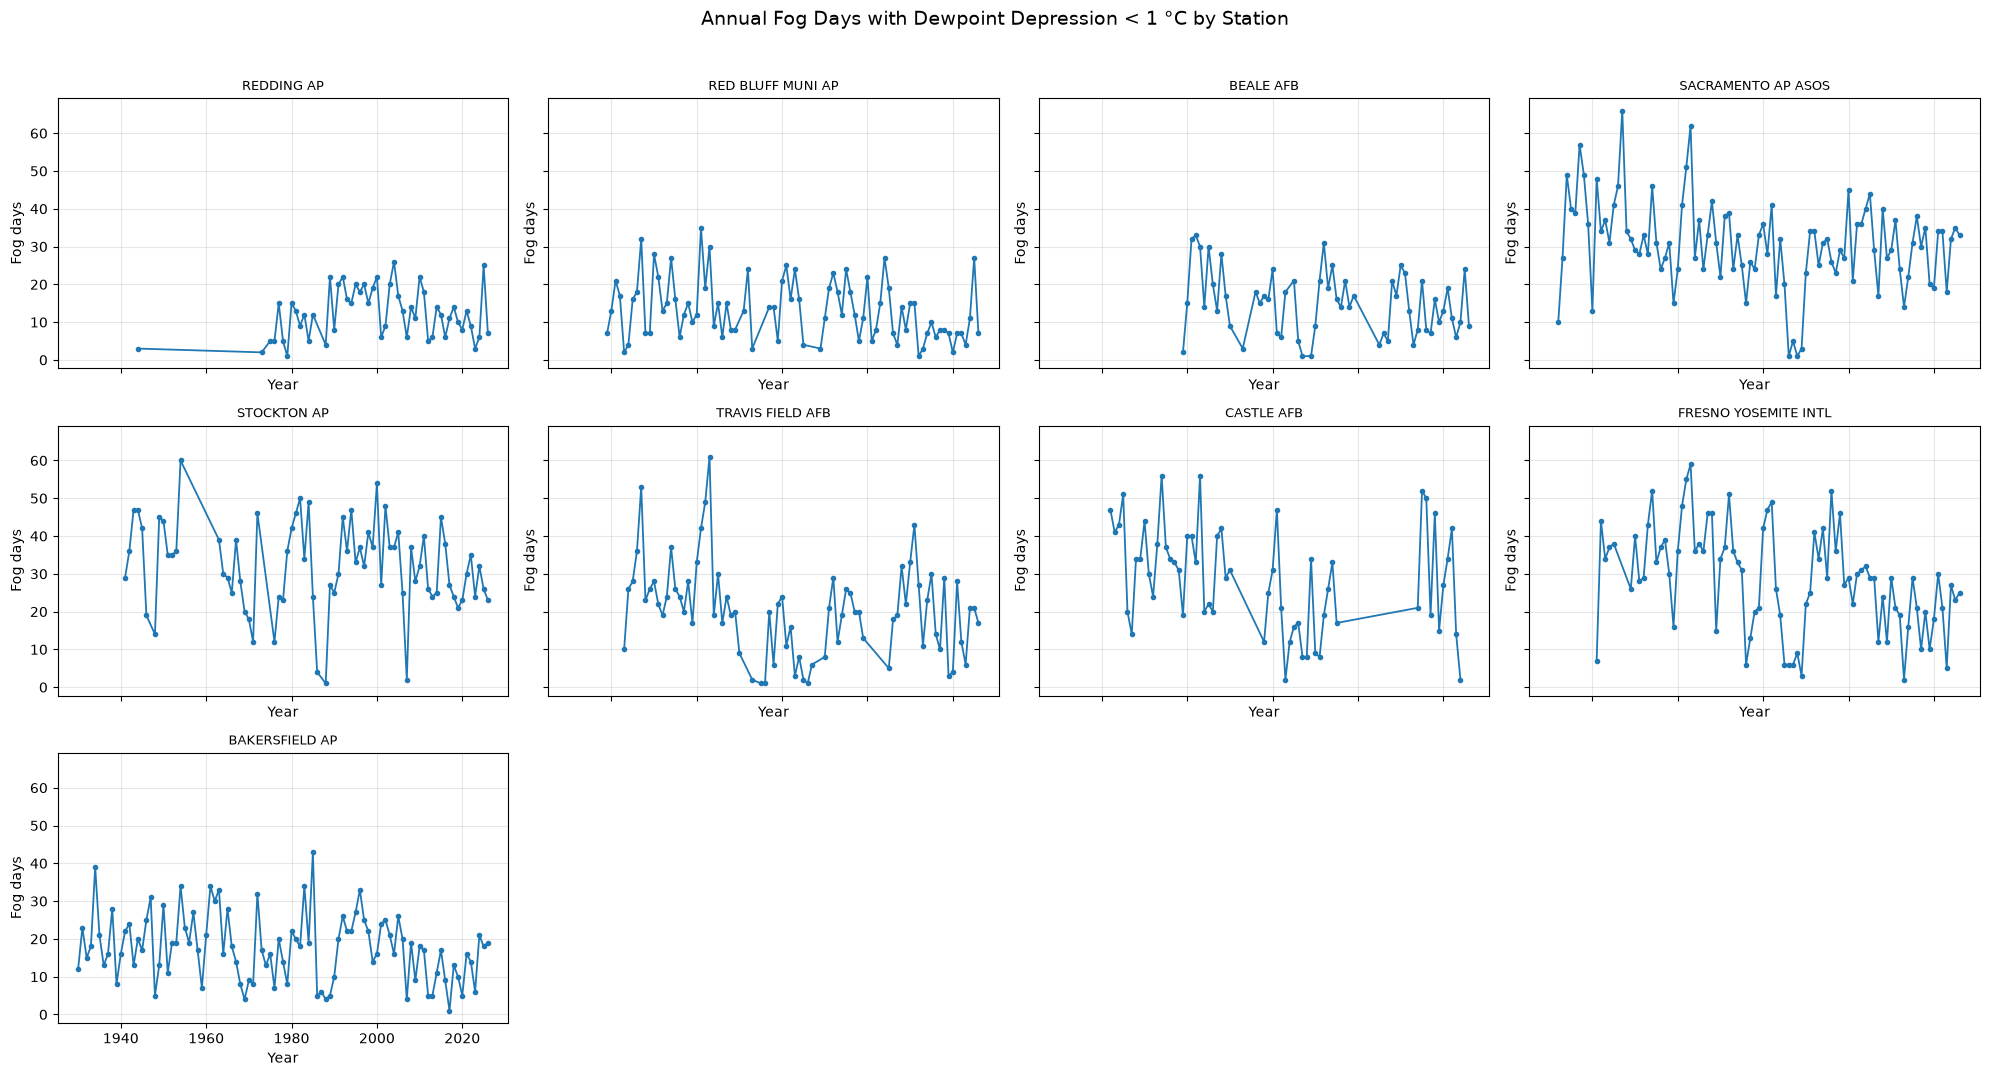

In [17]:
# Annual number of fog days with dewpoint depression < 1 °C by station

fog_days_gt1 = fog_event_dd.copy()
fog_days_gt1["DATE"] = pd.to_datetime(fog_days_gt1["DATE"], errors="coerce")

fog_days_gt1 = fog_days_gt1[
    (fog_days_gt1["HourlyDewpointDepression"] < 1)
    & fog_days_gt1["DATE"].notna()
].copy()

fog_days_gt1["year"] = fog_days_gt1["DATE"].dt.year
fog_days_gt1["fog_date"] = fog_days_gt1["DATE"].dt.normalize()

annual_fog_days_gt1 = (
    fog_days_gt1
    .drop_duplicates(["STATION", "fog_date"])
    .groupby(["STATION", "year"], as_index=False)
    .size()
    .rename(columns={"size": "fog_days_gt1"})
    .sort_values(["STATION", "year"])
)

print(annual_fog_days_gt1.head())
print("Total fog days:", annual_fog_days_gt1["fog_days_gt1"].sum())

stations_fog_days = ["REDDING AP", "RED BLUFF MUNI AP", "BEALE AFB", "SACRAMENTO AP ASOS", "STOCKTON AP", "TRAVIS FIELD AFB", "CASTLE AFB", "FRESNO YOSEMITE INTL", "BAKERSFIELD AP"]

if not stations_fog_days:
    print("No fog days found with dewpoint depression < 1 °C.")
else:
    ncols = 4
    nrows = int(np.ceil(len(stations_fog_days) / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(5 * ncols, 3.5 * nrows),
        sharex=True,
        sharey=True
    )
    axes = np.asarray(axes).reshape(-1)

    for i, station_name in enumerate(stations_fog_days):
        ax = axes[i]
        group = annual_fog_days_gt1[
            annual_fog_days_gt1["STATION"] == station_name
        ]

        ax.plot(
            group["year"],
            group["fog_days_gt1"],
            marker="o",
            markersize=3,
            linewidth=1.3
        )
        ax.set_title(station_name, fontsize=9)
        ax.set_xlabel("Year")
        ax.set_ylabel("Fog days")
        ax.grid(alpha=0.3)

    for ax in axes[len(stations_fog_days):]:
        ax.axis("off")

    fig.suptitle(
        "Annual Fog Days with Dewpoint Depression < 1 °C by Station",
        y=1.02,
        fontsize=14
    )
    plt.tight_layout()
    plt.show()

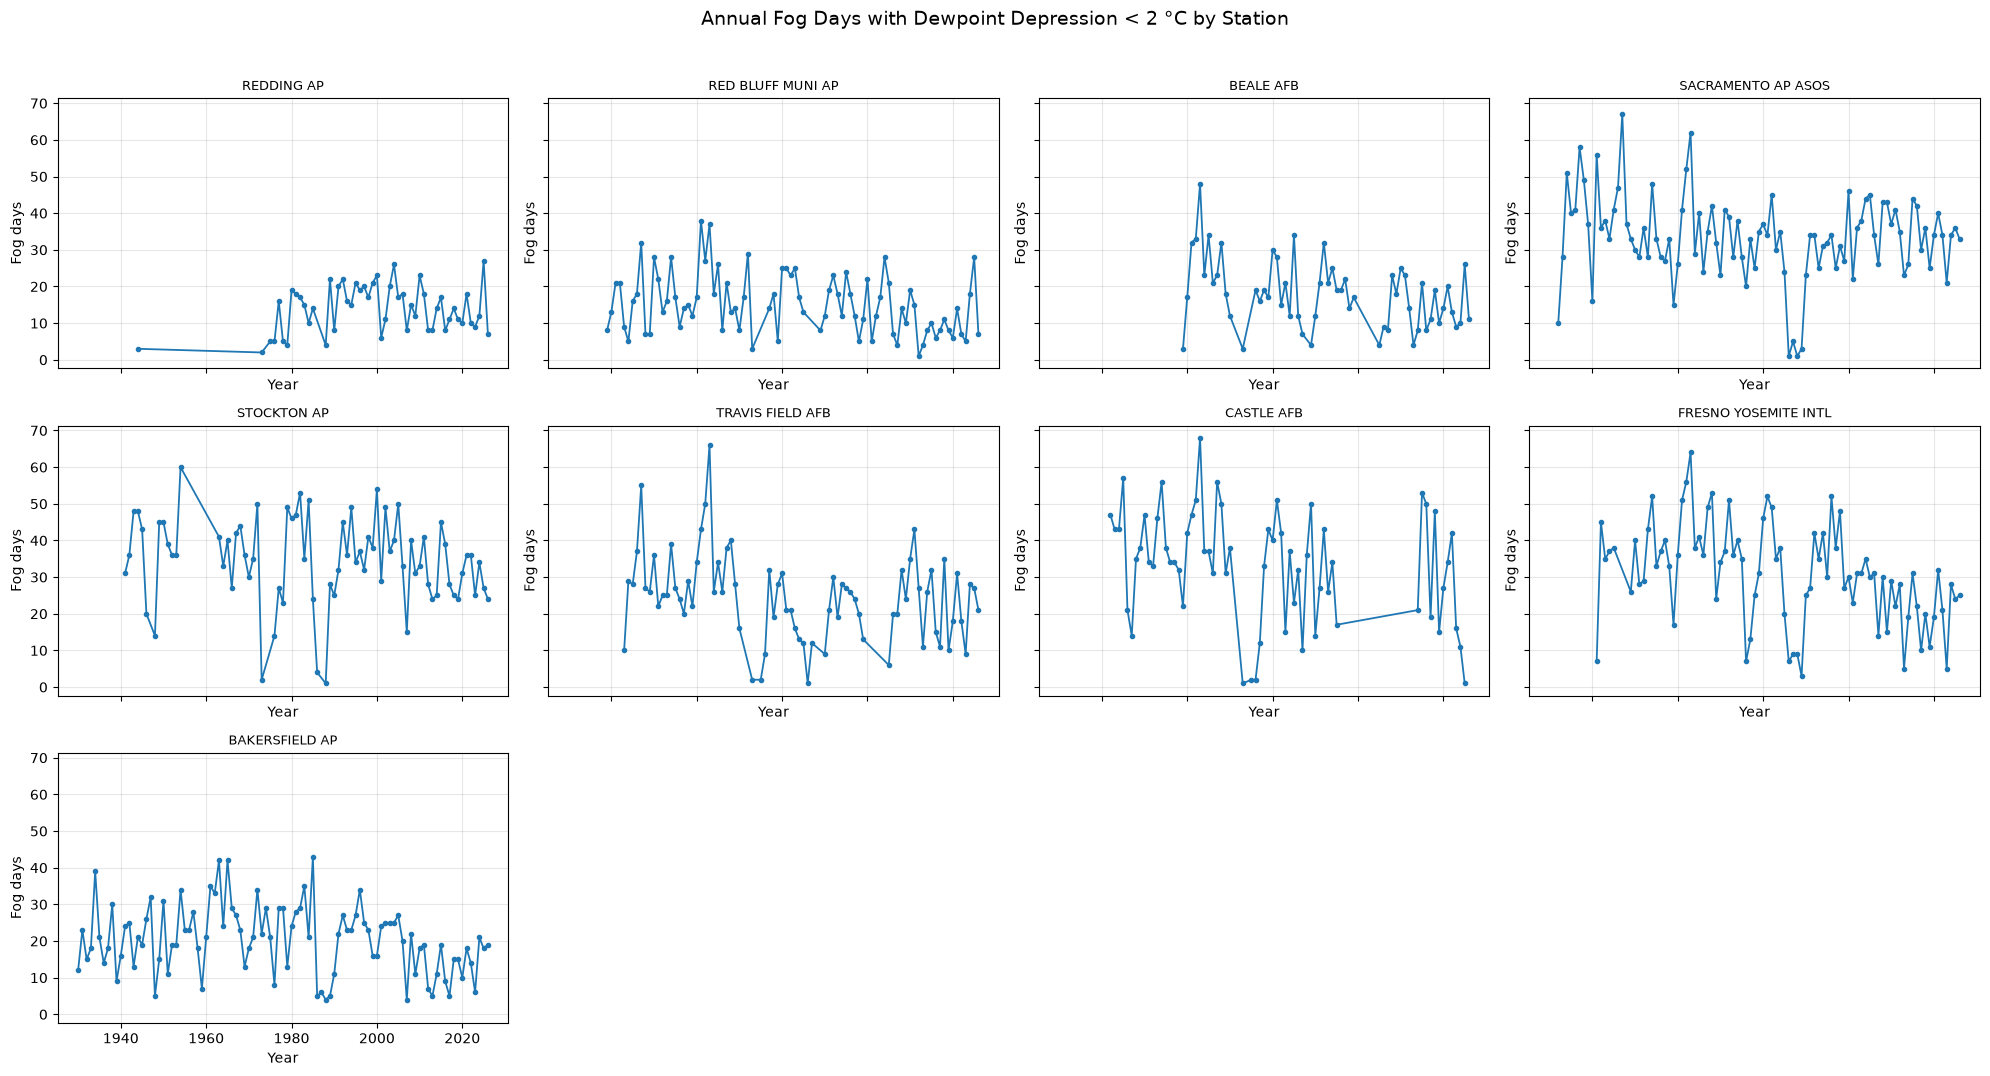

In [18]:
# Annual fog days with dewpoint depression < 2 °C by station

fog_days_gt2 = fog_event_dd.copy()
fog_days_gt2["DATE"] = pd.to_datetime(fog_days_gt2["DATE"], errors="coerce")

fog_days_gt2 = fog_days_gt2[
    (fog_days_gt2["HourlyDewpointDepression"] < 2)
    & fog_days_gt2["DATE"].notna()
].copy()

fog_days_gt2["year"] = fog_days_gt2["DATE"].dt.year
fog_days_gt2["fog_date"] = fog_days_gt2["DATE"].dt.normalize()

annual_fog_days_gt2 = (
    fog_days_gt2
    .drop_duplicates(["STATION", "fog_date"])
    .groupby(["STATION", "year"], as_index=False)
    .size()
    .rename(columns={"size": "fog_days_gt2"})
    .sort_values(["STATION", "year"])
)

stations_gt2 = ["REDDING AP", "RED BLUFF MUNI AP", "BEALE AFB", "SACRAMENTO AP ASOS", "STOCKTON AP", "TRAVIS FIELD AFB", "CASTLE AFB", "FRESNO YOSEMITE INTL", "BAKERSFIELD AP"]


if not stations_gt2:
    print("No fog days found with dewpoint depression < 2 °C.")
else:
    ncols = 4
    nrows = int(np.ceil(len(stations_gt2) / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(5 * ncols, 3.5 * nrows),
        sharex=True,
        sharey=True
    )
    axes = np.asarray(axes).reshape(-1)

    for i, station_name in enumerate(stations_gt2):
        ax = axes[i]
        group = annual_fog_days_gt2[
            annual_fog_days_gt2["STATION"] == station_name
        ]

        ax.plot(
            group["year"],
            group["fog_days_gt2"],
            marker="o",
            markersize=3,
            linewidth=1.3
        )
        ax.set_title(station_name, fontsize=9)
        ax.set_xlabel("Year")
        ax.set_ylabel("Fog days")
        ax.grid(alpha=0.3)

    for ax in axes[len(stations_gt2):]:
        ax.axis("off")

    fig.suptitle(
        "Annual Fog Days with Dewpoint Depression < 2 °C by Station",
        y=1.02,
        fontsize=14
    )
    plt.tight_layout()
    plt.show()

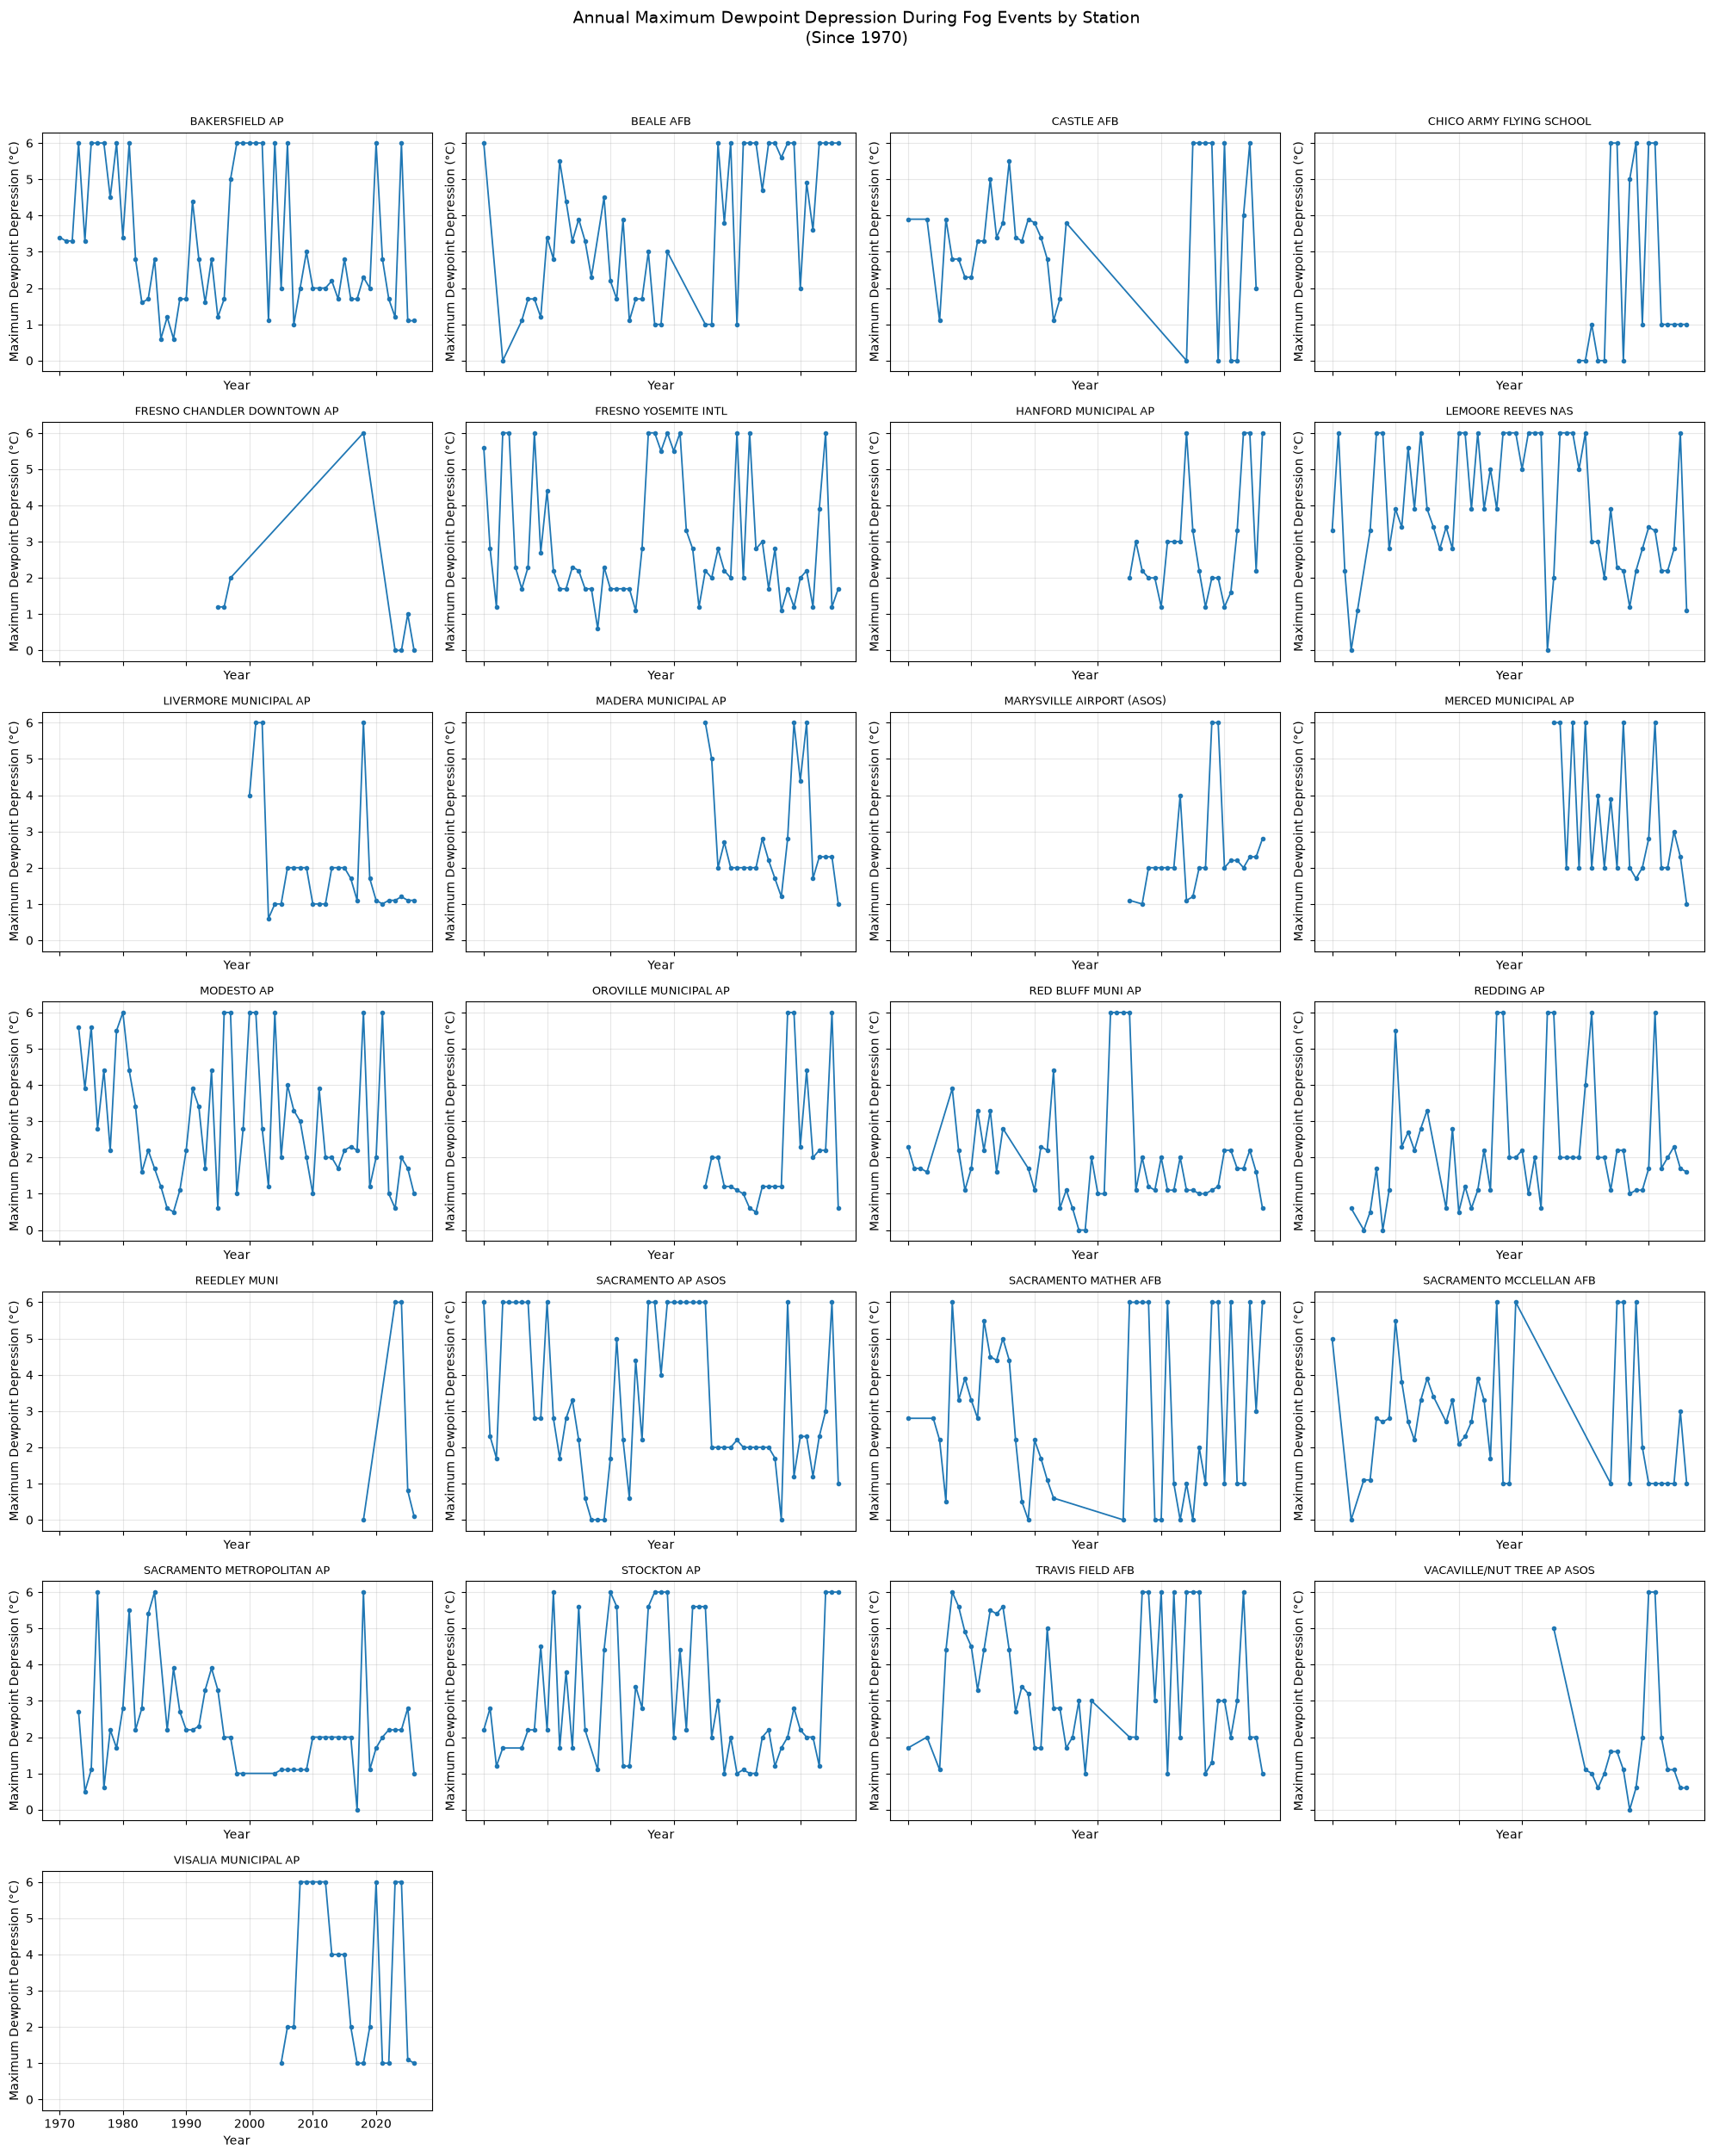

In [19]:
# Maximum dewpoint depression during fog events by station and year since 1970

fog_max_source = fog_event_dd.copy()
fog_max_source["DATE"] = pd.to_datetime(fog_max_source["DATE"], errors="coerce")

fog_max_source = fog_max_source[
    (fog_max_source["DATE"].dt.year >= 1970)
].dropna(
    subset=["STATION", "DATE", "HourlyDewpointDepression"]
).copy()

fog_max_source["year"] = fog_max_source["DATE"].dt.year

annual_max_dd = (
    fog_max_source
    .groupby(["STATION", "year"], as_index=False)["HourlyDewpointDepression"]
    .max()
    .sort_values(["STATION", "year"])
)

stations_max = sorted(annual_max_dd["STATION"].unique())

if not stations_max:
    print("No fog-event data found since 1970.")
else:
    ncols = 4
    nrows = int(np.ceil(len(stations_max) / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(5 * ncols, 3.5 * nrows),
        sharex=True,
        sharey=True
    )
    axes = np.asarray(axes).reshape(-1)

    for idx, station_name in enumerate(stations_max):
        ax = axes[idx]
        group = annual_max_dd[
            annual_max_dd["STATION"] == station_name
        ]

        ax.plot(
            group["year"],
            group["HourlyDewpointDepression"],
            marker="o",
            markersize=3,
            linewidth=1.3
        )
        ax.set_title(station_name, fontsize=9)
        ax.set_xlabel("Year")
        ax.set_ylabel("Maximum Dewpoint Depression (°C)")
        ax.grid(alpha=0.3)

    for ax in axes[len(stations_max):]:
        ax.axis("off")

    fig.suptitle(
        "Annual Maximum Dewpoint Depression During Fog Events by Station\n(Since 1970)",
        y=1.02,
        fontsize=14
    )
    plt.tight_layout()
    plt.show()

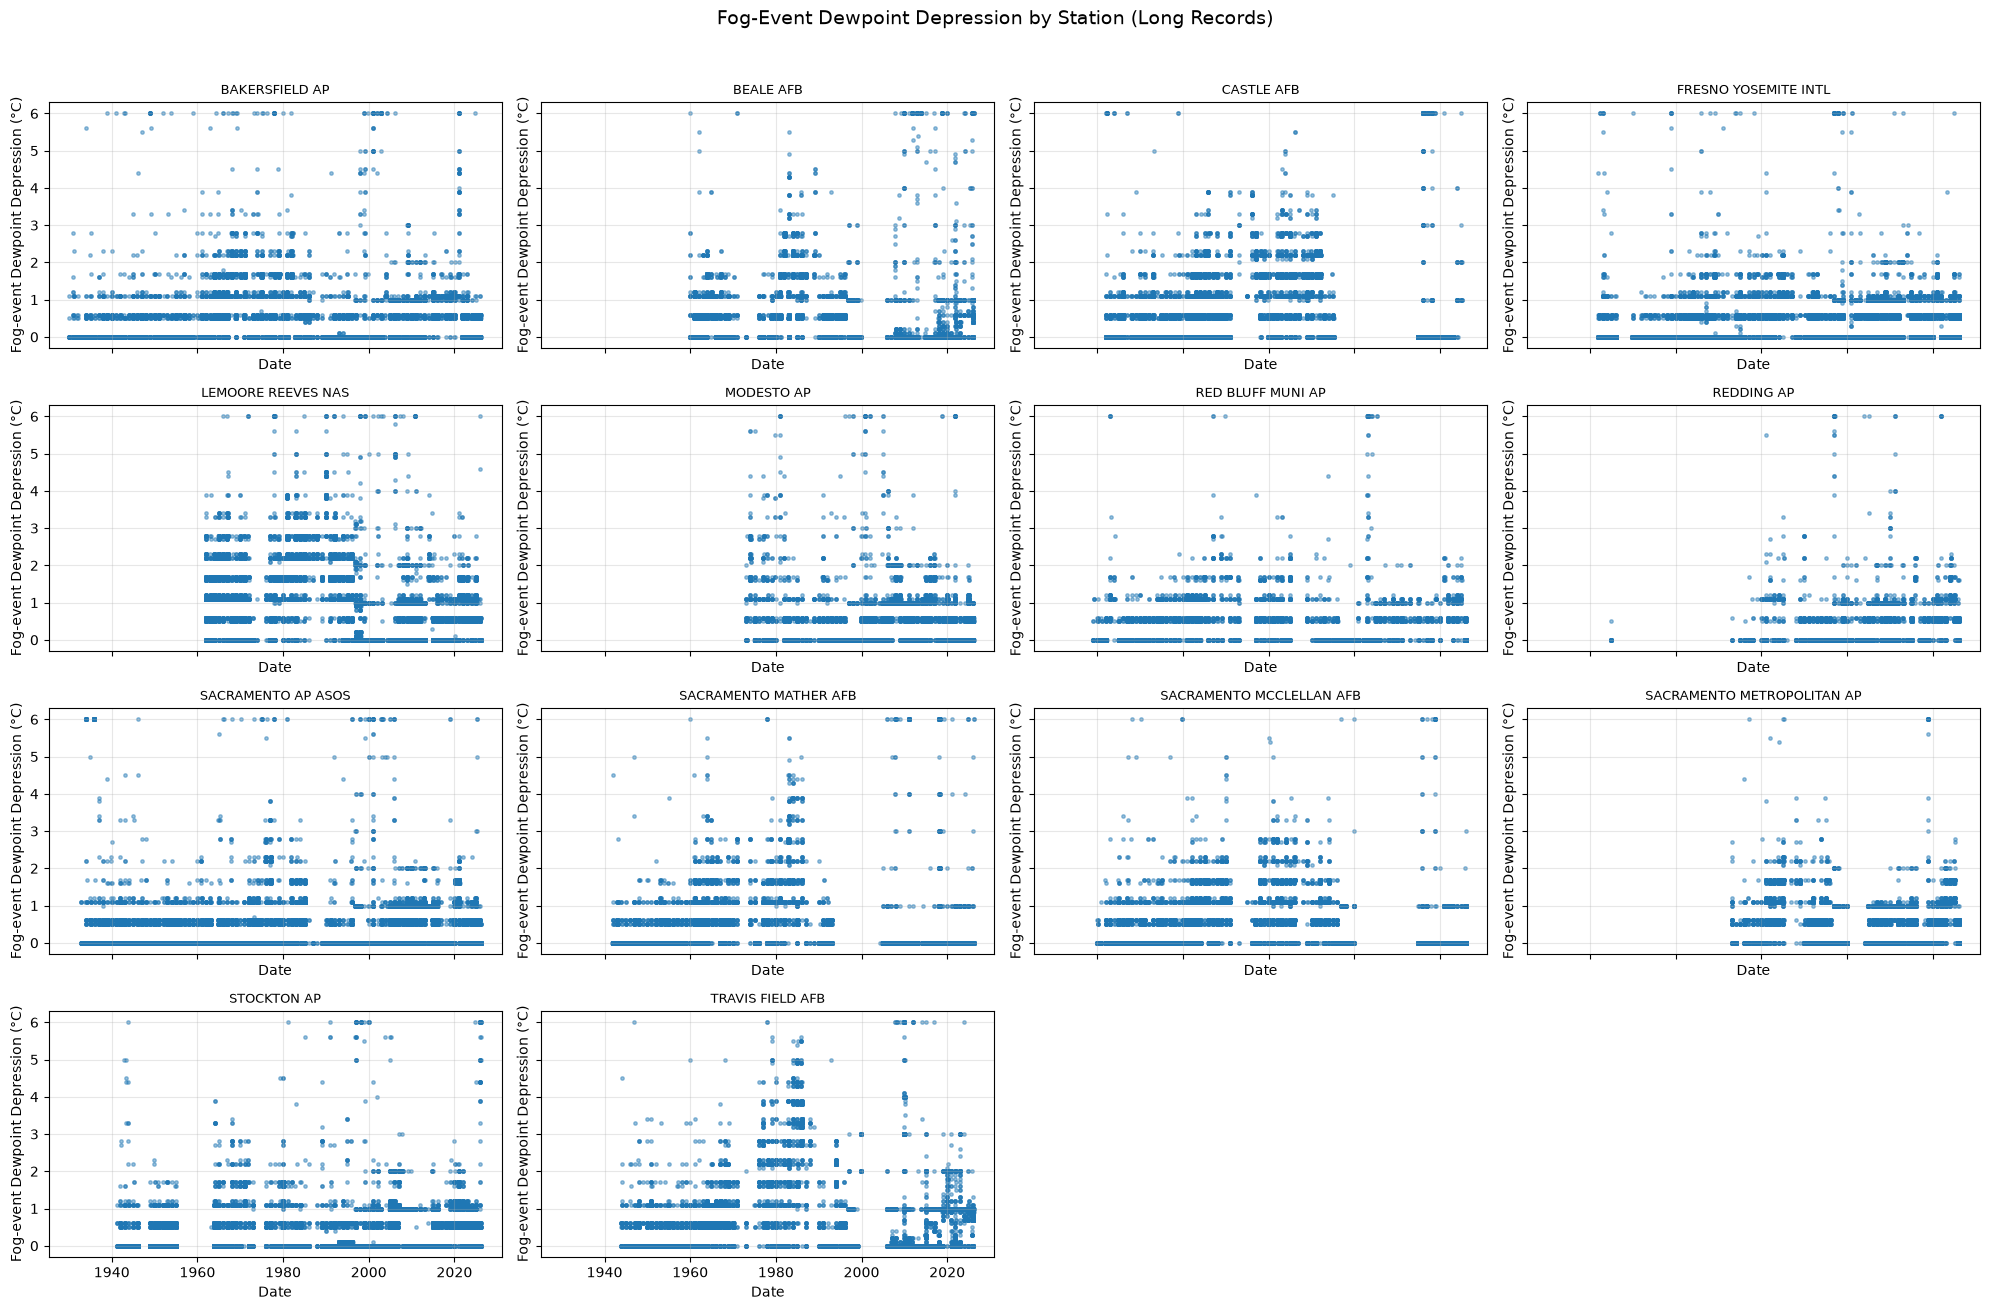

In [20]:
# Plot dewpoint depression for each fog event at long-record stations

# Use long-record station list if already created; otherwise build from CV_rows (>30 unique years)
if "eligible_stations_30" in globals():
    long_record_stations = set(eligible_stations_30)
else:
    year_counts = CV_rows.groupby("STATION")["year"].nunique()
    long_record_stations = set(year_counts[year_counts > 30].index)

fog_event_long = fog_event_dd[fog_event_dd["STATION"].isin(long_record_stations)].copy()
fog_event_long = fog_event_long.dropna(subset=["DATE", "HourlyDewpointDepression"])

stations_long = sorted(fog_event_long["STATION"].unique())
n_stations = len(stations_long)

if n_stations == 0:
    print("No long-record stations found in fog_event_dd.")
else:
    ncols = 4
    nrows = int(np.ceil(n_stations / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(5 * ncols, 3.2 * nrows),
        sharex=True,
        sharey=True
    )
    axes = np.array(axes).reshape(-1)

    for i, station_name in enumerate(stations_long):
        ax = axes[i]
        g = fog_event_long[fog_event_long["STATION"] == station_name].sort_values("DATE")

        ax.scatter(
            g["DATE"],
            g["HourlyDewpointDepression"],
            s=6,
            alpha=0.45
        )
        ax.set_title(station_name, fontsize=9)
        ax.set_xlabel("Date")
        ax.set_ylabel("Fog-event Dewpoint Depression (°C)")
        ax.grid(alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle("Fog-Event Dewpoint Depression by Station (Long Records)", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

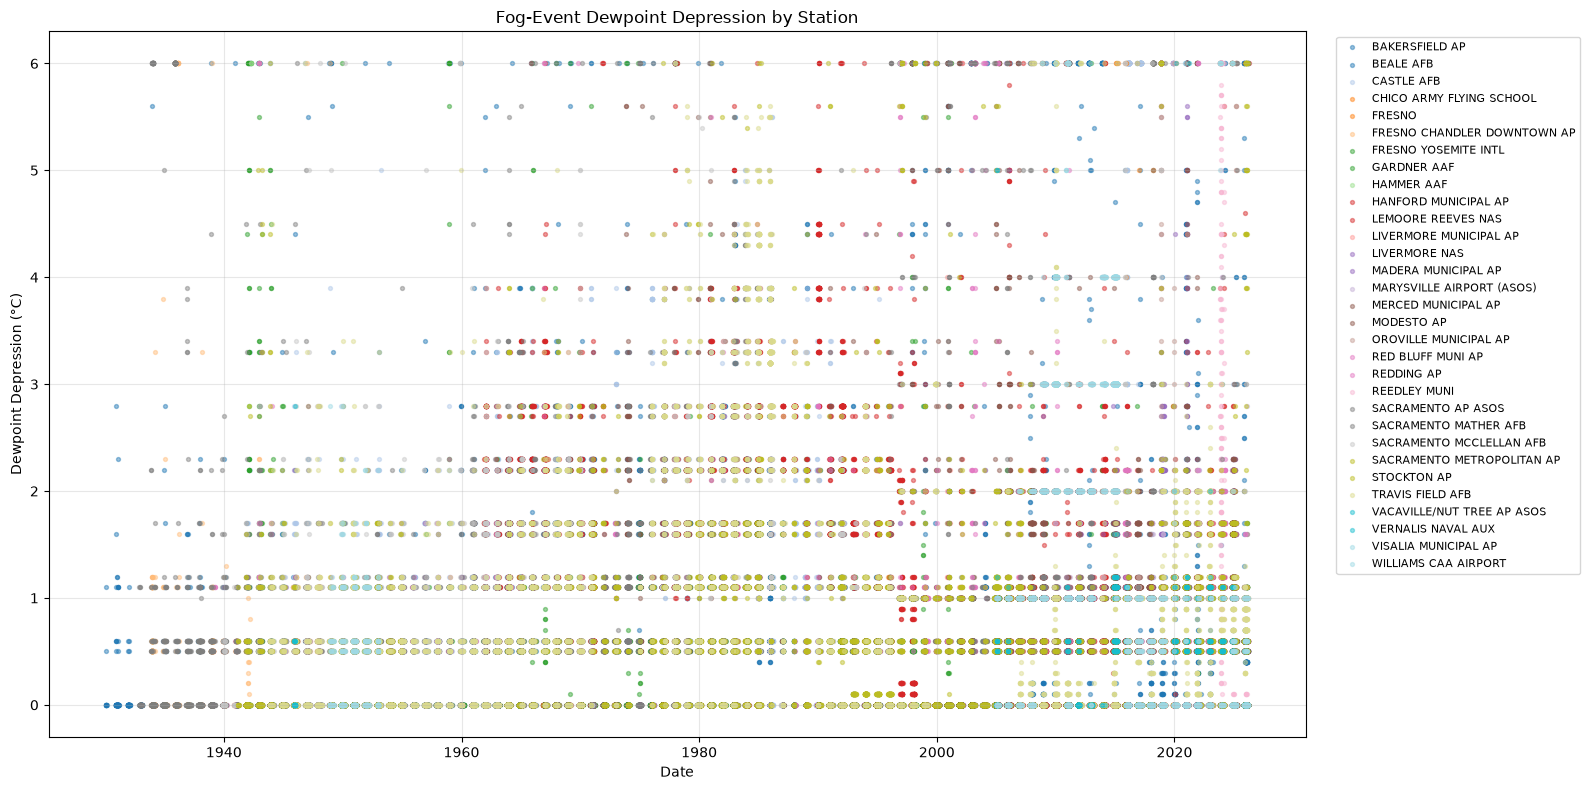

In [21]:
# Plot all fog-event dewpoint depressions on one plot, colored by station

plot_source = fog_event_dd.copy()
plot_source["DATE"] = pd.to_datetime(plot_source["DATE"], errors="coerce")
plot_source = plot_source.dropna(
    subset=["STATION", "DATE", "HourlyDewpointDepression"]
)

stations_all = sorted(plot_source["STATION"].unique())
colors = plt.cm.tab20(np.linspace(0, 1, len(stations_all)))

fig, ax = plt.subplots(figsize=(16, 8))

for station_name, color in zip(stations_all, colors):
    station_data = plot_source[plot_source["STATION"] == station_name]

    ax.scatter(
        station_data["DATE"],
        station_data["HourlyDewpointDepression"],
        s=8,
        alpha=0.45,
        color=color,
        label=station_name
    )

ax.set_title("Fog-Event Dewpoint Depression by Station")
ax.set_xlabel("Date")
ax.set_ylabel("Dewpoint Depression (°C)")
ax.grid(alpha=0.3)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8,
    ncol=1
)

plt.tight_layout()
plt.show()

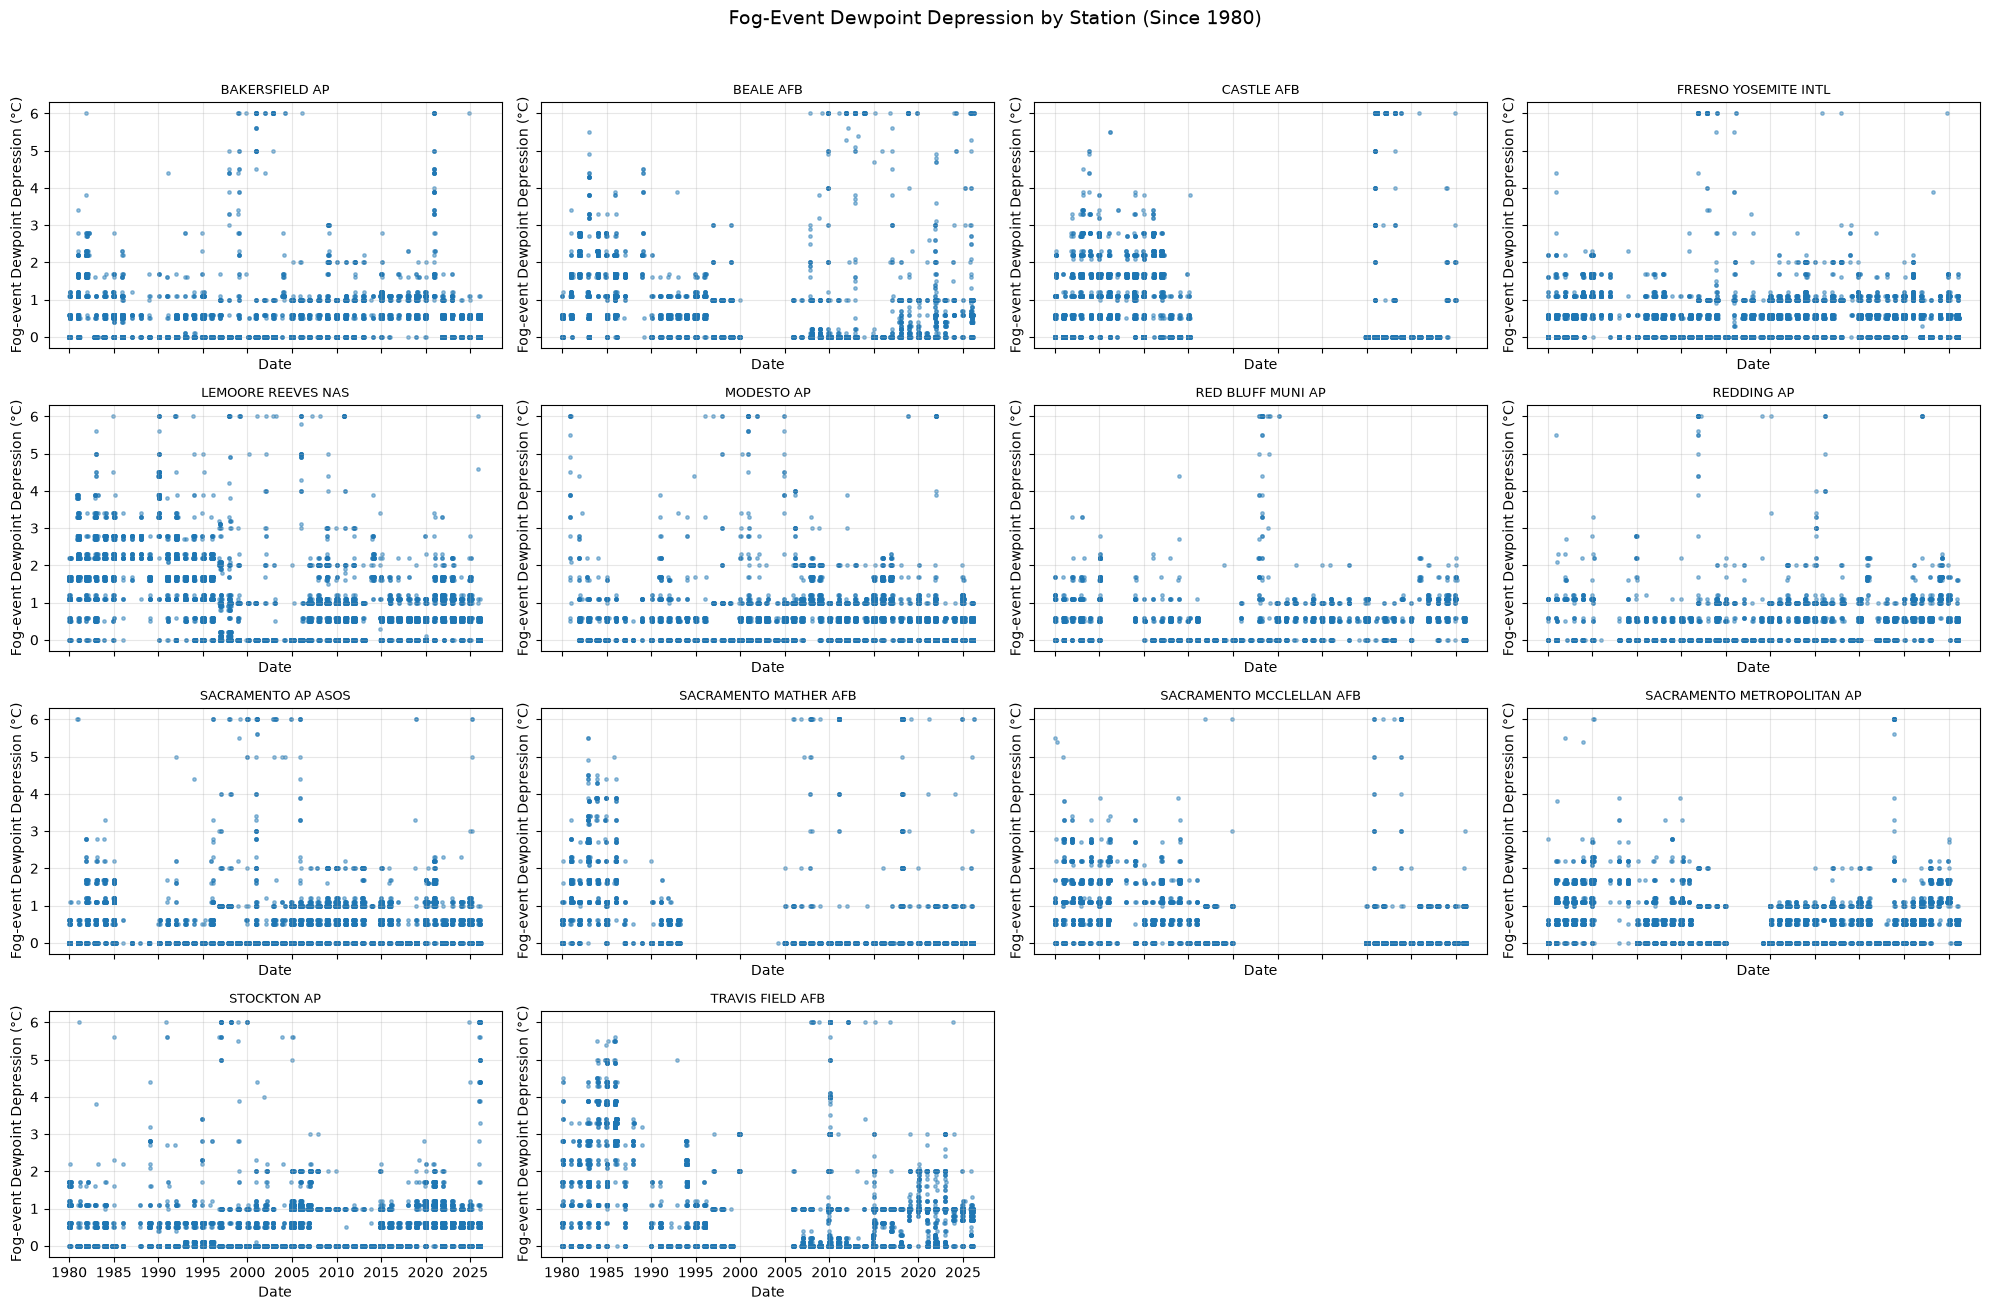

In [22]:
# Same fog-event dewpoint depression plot, but only for years since 1980

if "fog_event_long" in globals():
    fog_event_long_1980 = fog_event_long.copy()
else:
    fog_event_long_1980 = fog_event_dd[fog_event_dd["STATION"].isin(long_record_stations)].copy()

fog_event_long_1980["DATE"] = pd.to_datetime(fog_event_long_1980["DATE"], errors="coerce")
fog_event_long_1980 = fog_event_long_1980[
    fog_event_long_1980["DATE"].dt.year >= 1980
].dropna(subset=["DATE", "HourlyDewpointDepression"])

stations_long_1980 = sorted(fog_event_long_1980["STATION"].unique())
n_stations_1980 = len(stations_long_1980)

if n_stations_1980 == 0:
    print("No fog-event records since 1980 for long-record stations.")
else:
    ncols = 4
    nrows = int(np.ceil(n_stations_1980 / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(5 * ncols, 3.2 * nrows),
        sharex=True,
        sharey=True
    )
    axes = np.array(axes).reshape(-1)

    for i, station_name in enumerate(stations_long_1980):
        ax = axes[i]
        g = fog_event_long_1980[fog_event_long_1980["STATION"] == station_name].sort_values("DATE")

        ax.scatter(
            g["DATE"],
            g["HourlyDewpointDepression"],
            s=6,
            alpha=0.45
        )
        ax.set_title(station_name, fontsize=9)
        ax.set_xlabel("Date")
        ax.set_ylabel("Fog-event Dewpoint Depression (°C)")
        ax.grid(alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle("Fog-Event Dewpoint Depression by Station (Since 1980)", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

Trend results for all stations:


,STATION,n_years,n_fog_events,slope_C_per_year,slope_C_per_decade,p_value,r_squared,significant_p05
7,LEMOORE REEVES NAS,47,11768,-0.041616,-0.416164,1.372329e-07,0.463909,True
19,SACRAMENTO MCCLELLAN AFB,32,6948,-0.024152,-0.241520,1.423072e-07,0.608325,True
4,FRESNO CHANDLER DOWNTOWN AP,8,1522,-0.020438,-0.204382,1.543164e-06,0.983007,True
18,SACRAMENTO MATHER AFB,37,4968,-0.022276,-0.222759,2.511950e-03,0.232471,True
22,TRAVIS FIELD AFB,42,10512,-0.027129,-0.271291,2.575894e-03,0.205425,True
21,STOCKTON AP,46,12426,0.008313,0.083132,1.012366e-02,0.141004,True
20,SACRAMENTO METROPOLITAN AP,42,9570,-0.012443,-0.124426,1.988274e-02,0.128238,True
24,VISALIA MUNICIPAL AP,22,10158,-0.071190,-0.711899,2.024369e-02,0.241336,True
1,BEALE AFB,41,6598,-0.015232,-0.152318,3.633051e-02,0.107548,True
0,BAKERSFIELD AP,47,7204,0.008689,0.086892,4.450062e-02,0.086723,True


Stations with significant trends: 10


,STATION,n_years,n_fog_events,slope_C_per_year,slope_C_per_decade,p_value,r_squared,significant_p05
7,LEMOORE REEVES NAS,47,11768,-0.041616,-0.416164,1.372329e-07,0.463909,True
19,SACRAMENTO MCCLELLAN AFB,32,6948,-0.024152,-0.241520,1.423072e-07,0.608325,True
4,FRESNO CHANDLER DOWNTOWN AP,8,1522,-0.020438,-0.204382,1.543164e-06,0.983007,True
18,SACRAMENTO MATHER AFB,37,4968,-0.022276,-0.222759,2.511950e-03,0.232471,True
22,TRAVIS FIELD AFB,42,10512,-0.027129,-0.271291,2.575894e-03,0.205425,True
21,STOCKTON AP,46,12426,0.008313,0.083132,1.012366e-02,0.141004,True
20,SACRAMENTO METROPOLITAN AP,42,9570,-0.012443,-0.124426,1.988274e-02,0.128238,True
24,VISALIA MUNICIPAL AP,22,10158,-0.071190,-0.711899,2.024369e-02,0.241336,True
1,BEALE AFB,41,6598,-0.015232,-0.152318,3.633051e-02,0.107548,True
0,BAKERSFIELD AP,47,7204,0.008689,0.086892,4.450062e-02,0.086723,True


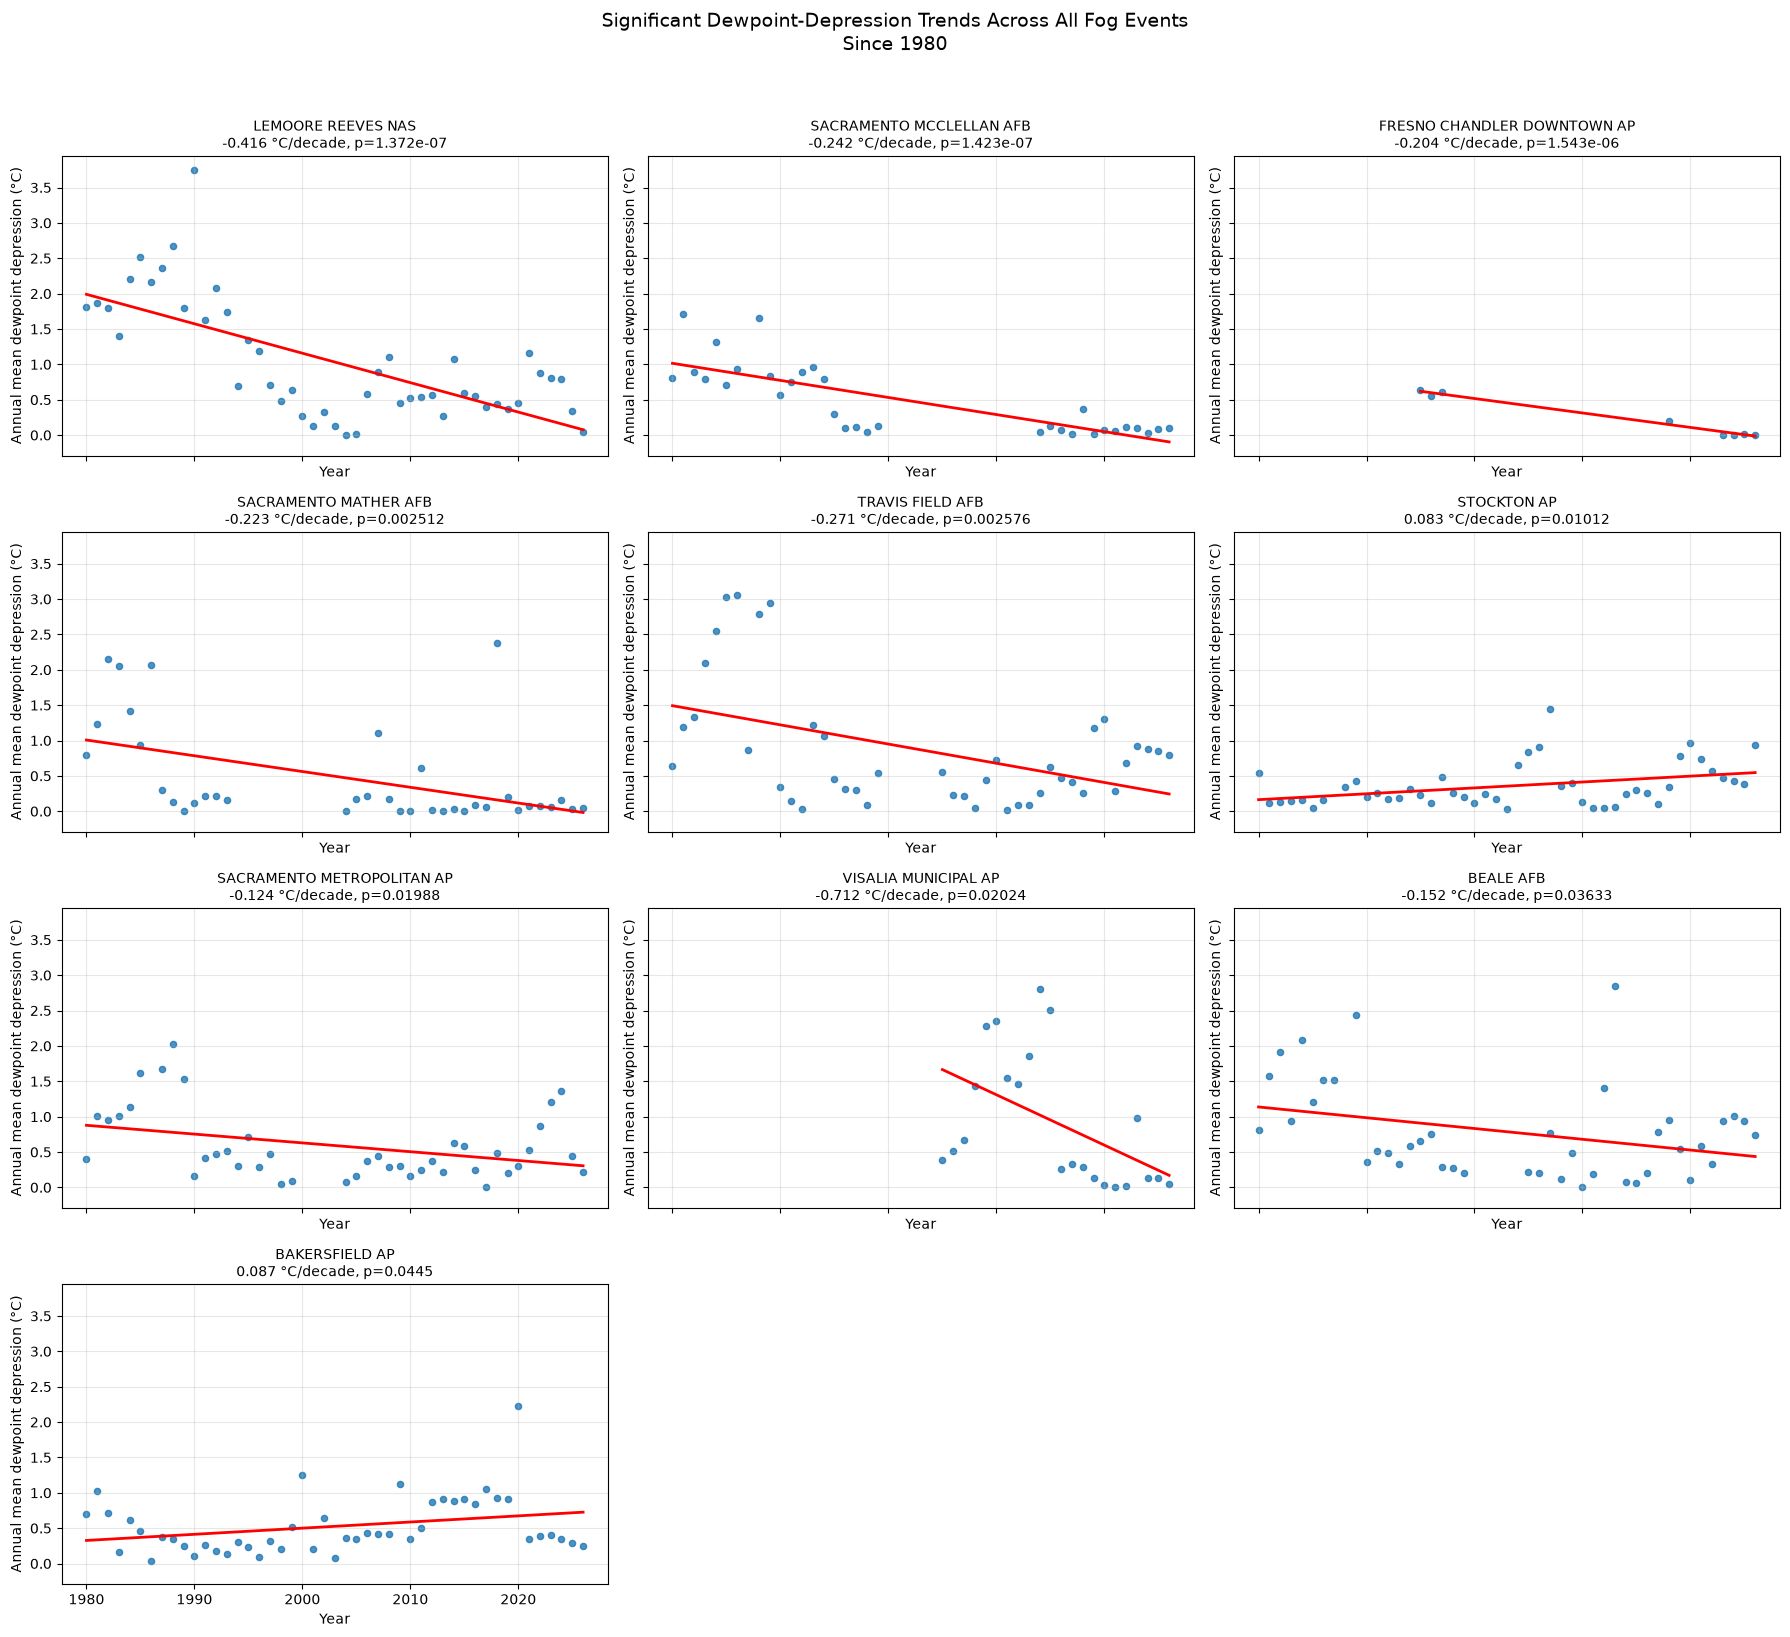

In [23]:
# Dewpoint-depression trends across all fog events by station since 1980
# Trends are calculated from annual station means and plotted only when p < 0.05.

trend_data = fog_event_dd.copy()
trend_data["DATE"] = pd.to_datetime(trend_data["DATE"], errors="coerce")

trend_data = trend_data.dropna(
    subset=["STATION", "DATE", "HourlyDewpointDepression"]
)
trend_data = trend_data[trend_data["DATE"].dt.year >= 1980].copy()
trend_data["year"] = trend_data["DATE"].dt.year

annual_fog_dd = (
    trend_data
    .groupby(["STATION", "year"], as_index=False)
    ["HourlyDewpointDepression"]
    .mean()
)

trend_rows = []

for station_name, group in annual_fog_dd.groupby("STATION"):
    group = group.sort_values("year")

    if group["year"].nunique() < 2:
        continue

    fit = stats.linregress(
        group["year"],
        group["HourlyDewpointDepression"]
    )

    trend_rows.append({
        "STATION": station_name,
        "n_years": group["year"].nunique(),
        "n_fog_events": len(
            trend_data[trend_data["STATION"] == station_name]
        ),
        "slope_C_per_year": fit.slope,
        "slope_C_per_decade": fit.slope * 10,
        "p_value": fit.pvalue,
        "r_squared": fit.rvalue ** 2,
        "significant_p05": fit.pvalue < 0.05
    })

fog_event_trends = (
    pd.DataFrame(trend_rows)
    .sort_values("p_value")
)

print("Trend results for all stations:")
display(fog_event_trends)

significant_trends = fog_event_trends[
    fog_event_trends["significant_p05"]
].copy()

print(f"Stations with significant trends: {len(significant_trends)}")
display(significant_trends)

# Plot only statistically significant station trends
if significant_trends.empty:
    print("No statistically significant trends found at p < 0.05.")
else:
    significant_stations = significant_trends["STATION"].tolist()
    ncols_sig = 3
    nrows_sig = int(np.ceil(len(significant_stations) / ncols_sig))

    fig, axes_sig = plt.subplots(
        nrows=nrows_sig,
        ncols=ncols_sig,
        figsize=(6 * ncols_sig, 4 * nrows_sig),
        sharex=True,
        sharey=True
    )
    axes_sig = np.asarray(axes_sig).reshape(-1)

    for i, station_name in enumerate(significant_stations):
        ax = axes_sig[i]

        group = annual_fog_dd[
            annual_fog_dd["STATION"] == station_name
        ].sort_values("year")

        x = group["year"].to_numpy()
        y = group["HourlyDewpointDepression"].to_numpy()
        fit = stats.linregress(x, y)

        ax.scatter(x, y, s=20, alpha=0.8)
        ax.plot(
            x,
            fit.intercept + fit.slope * x,
            color="red",
            linewidth=2
        )

        ax.set_title(
            f"{station_name}\n"
            f"{fit.slope * 10:.3f} °C/decade, "
            f"p={fit.pvalue:.4g}",
            fontsize=10
        )
        ax.set_xlabel("Year")
        ax.set_ylabel("Annual mean dewpoint depression (°C)")
        ax.grid(alpha=0.3)

    for ax in axes_sig[len(significant_stations):]:
        ax.axis("off")

    fig.suptitle(
        "Significant Dewpoint-Depression Trends Across All Fog Events\n"
        "Since 1980",
        y=1.02,
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

In [24]:
# # Exclude unrealistic fog-event dewpoint depression values and re-plot (since 1980)
# fog_event_long_1980_clean = fog_event_long_1980.copy()

# print("Rows before filter:", len(fog_event_long_1980))
# print("Rows after filter:", len(fog_event_long_1980_clean))

# stations_clean = sorted(fog_event_long_1980_clean["STATION"].unique())
# n_stations_clean = len(stations_clean)

# if n_stations_clean == 0:
#     print("No records remain after filtering.")
# else:
#     ncols = 4
#     nrows = int(np.ceil(n_stations_clean / ncols))

#     fig, axes = plt.subplots(
#         nrows=nrows,
#         ncols=ncols,
#         figsize=(5 * ncols, 3.2 * nrows),
#         sharex=True,
#         sharey=True
#     )
#     axes = np.array(axes).reshape(-1)

#     for i, station_name in enumerate(stations_clean):
#         ax = axes[i]
#         g = fog_event_long_1980_clean[
#             fog_event_long_1980_clean["STATION"] == station_name
#         ].sort_values("DATE")

#         ax.scatter(
#             g["DATE"],
#             g["HourlyDewpointDepression"],
#             s=6,
#             alpha=0.45
#         )
#         ax.set_title(station_name, fontsize=9)
#         ax.set_xlabel("Date")
#         ax.set_ylabel("Fog-event Dewpoint Depression (°C)")
#         ax.grid(alpha=0.3)

#     for j in range(i + 1, len(axes)):
#         axes[j].axis("off")

#     fig.suptitle(
#         "Fog-Event Dewpoint Depression by Station (Since 1980, 0–6 °C only)",
#         y=1.02,
#         fontsize=14
#     )
#     plt.tight_layout()
#     plt.show()

In [25]:
# the allowed values for dewpoint depression during fog events (0.5 - 6.0 °C) in 0.5 increments
# arange makes an array of values from 0.5 to 6.0 (inclusive) with a step of 0.5
allowed_values = np.arange(0.5, 6.01, 0.5)

fog_event_long_1980["HourlyDewpointDepression"] = (
    fog_event_long_1980["HourlyDewpointDepression"]
    .apply(lambda x: allowed_values[np.abs(allowed_values - x).argmin()])
)

fog_event_long_1980["HourlyDewpointDepression"].value_counts().sort_index()

HourlyDewpointDepression
0.5    85519
1.0    20275
1.5     4575
2.0     2959
2.5      801
3.0     1157
3.5      472
4.0      414
4.5      194
5.0      139
5.5       59
6.0      777
Name: count, dtype: int64

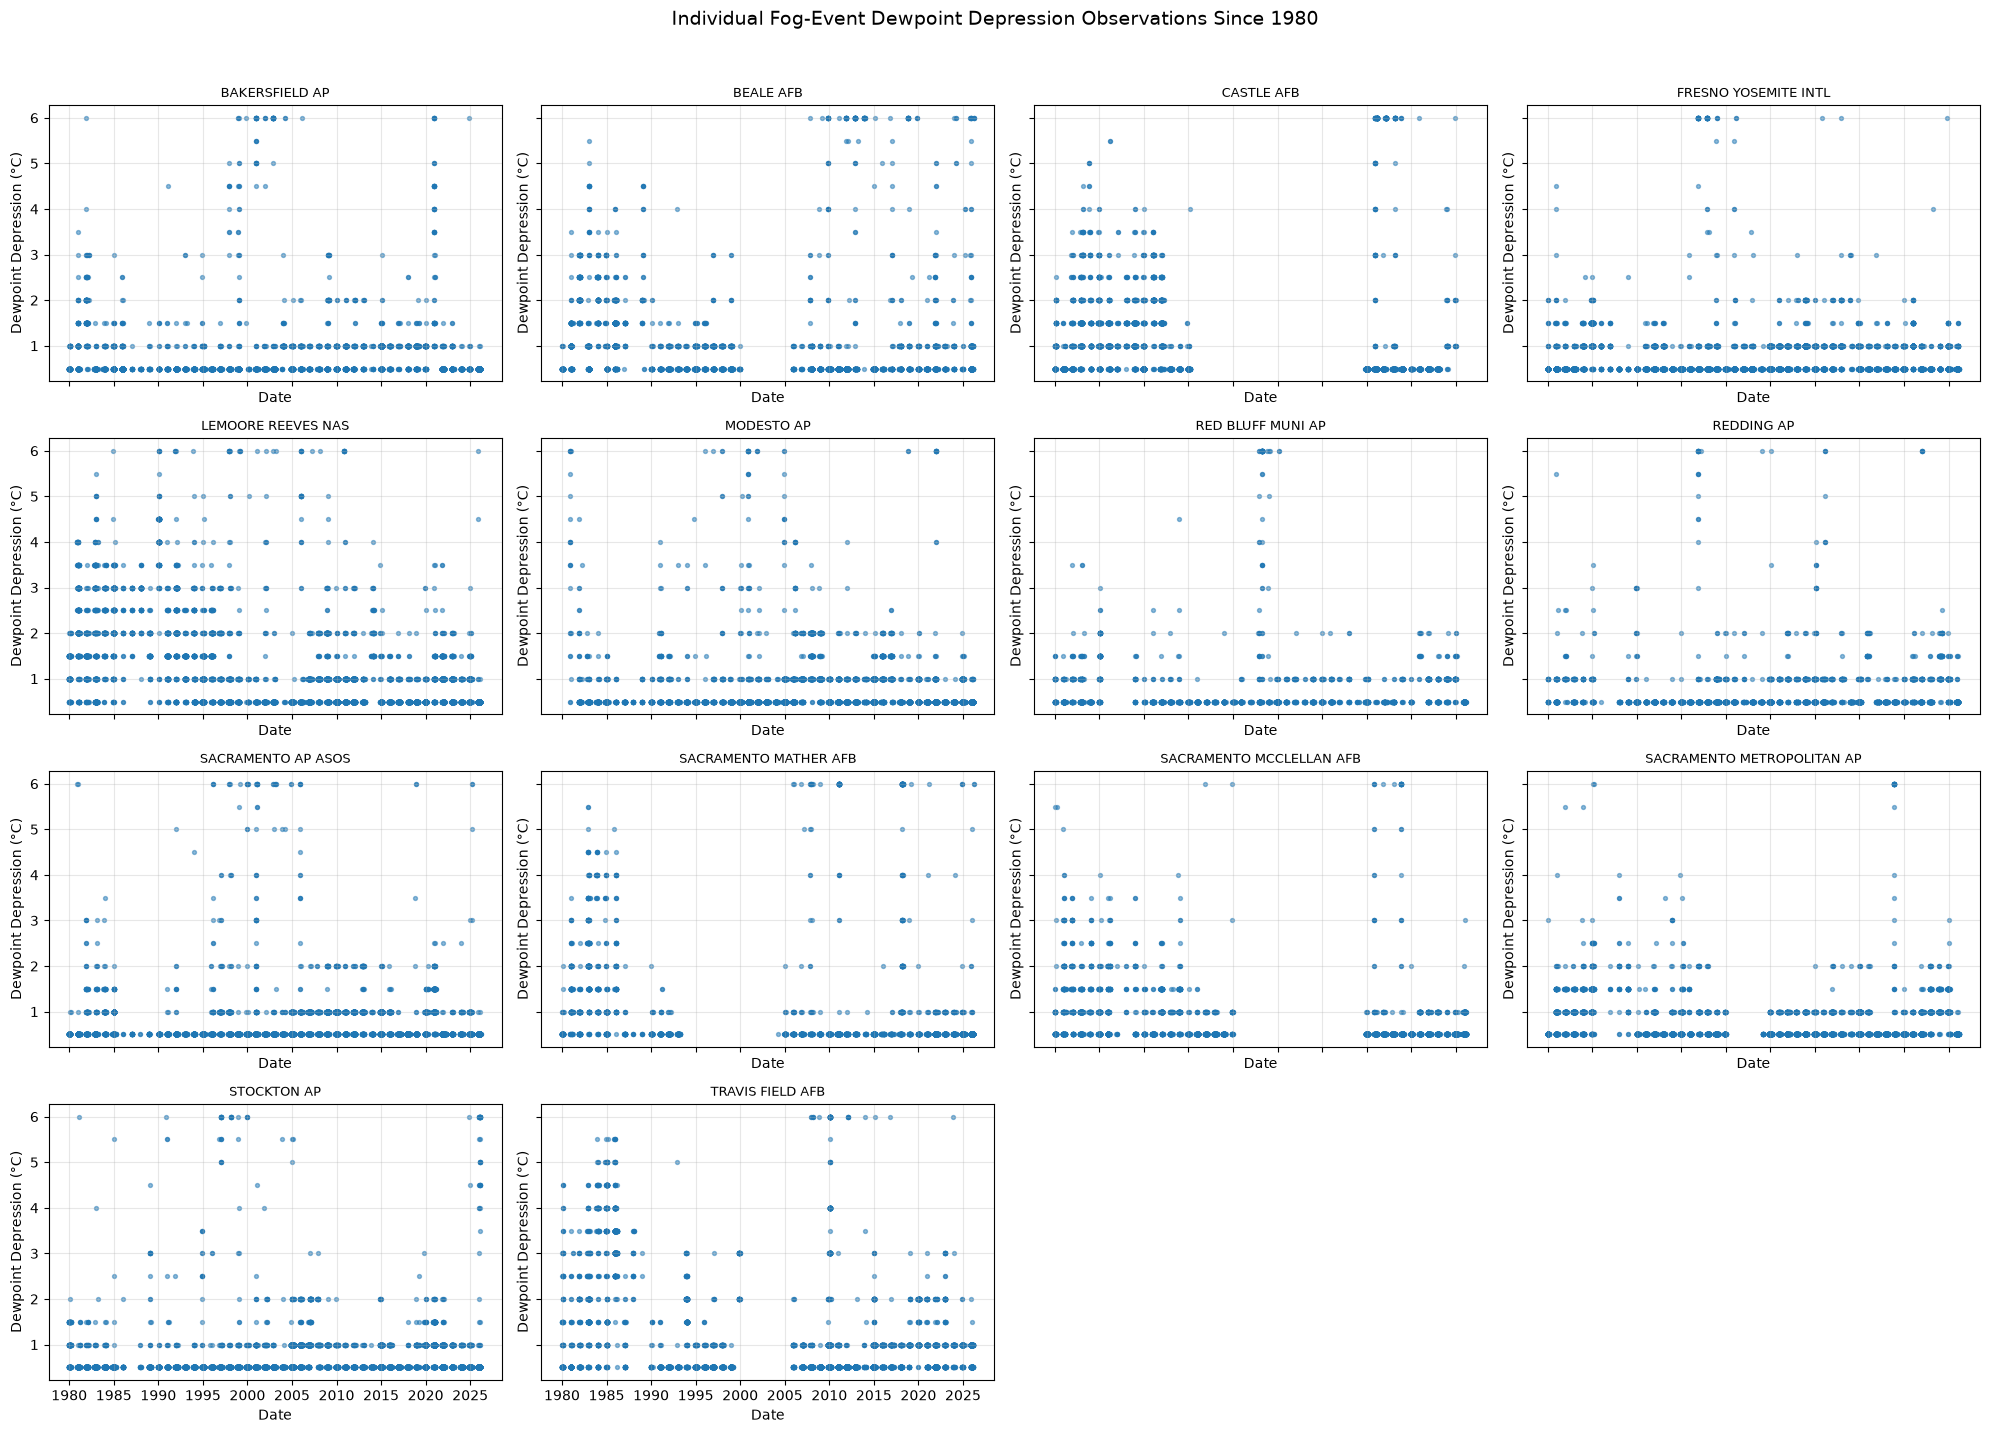

In [26]:
# Plot individual dewpoint-depression events over time for each station

plot_source = fog_event_long_1980.copy()
plot_source["DATE"] = pd.to_datetime(plot_source["DATE"], errors="coerce")
plot_source = plot_source.dropna(
    subset=["STATION", "DATE", "HourlyDewpointDepression"]
)

stations_event_plot = sorted(plot_source["STATION"].unique())
ncols_event_plot = 4
nrows_event_plot = int(np.ceil(len(stations_event_plot) / ncols_event_plot))

fig, axes_event_plot = plt.subplots(
    nrows=nrows_event_plot,
    ncols=ncols_event_plot,
    figsize=(5 * ncols_event_plot, 3.5 * nrows_event_plot),
    sharex=True,
    sharey=True
)

axes_event_plot = np.asarray(axes_event_plot).reshape(-1)

for i, station_name in enumerate(stations_event_plot):
    ax = axes_event_plot[i]
    station_data = plot_source[
        plot_source["STATION"] == station_name
    ].sort_values("DATE")

    ax.scatter(
        station_data["DATE"],
        station_data["HourlyDewpointDepression"],
        s=8,
        alpha=0.5
    )

    ax.set_title(station_name, fontsize=9)
    ax.set_xlabel("Date")
    ax.set_ylabel("Dewpoint Depression (°C)")
    ax.grid(alpha=0.3)

for ax in axes_event_plot[len(stations_event_plot):]:
    ax.axis("off")

fig.suptitle(
    "Individual Fog-Event Dewpoint Depression Observations Since 1980",
    y=1.02,
    fontsize=14
)

plt.tight_layout()
plt.show()

In [27]:
# Compute HourlyDewpointDepression for CV_filtered_rows and examine relationship
# between low dewpoint depression (<1, <2) and fog occurrence (HourlyVisibility < 1) by station

analysis_df = CV_filtered_rows.dropna(
    subset=["HourlyDryBulbTemperature", "HourlyDewPointTemperature", "HourlyVisibility"]
).copy()

analysis_df["HourlyDewpointDepression"] = (
    analysis_df["HourlyDryBulbTemperature"] - analysis_df["HourlyDewPointTemperature"]
).clip(lower=0)

analysis_df["dd_lt1"] = (analysis_df["HourlyDewpointDepression"] < 1).astype(int)
analysis_df["dd_lt2"] = (analysis_df["HourlyDewpointDepression"] < 2).astype(int)
analysis_df["is_fog"] = (analysis_df["HourlyVisibility"] < 1).astype(int)

station_results = []

for station_name, g in analysis_df.groupby("STATION"):
    n_rows = len(g)
    n_dd_lt1 = g["dd_lt1"].sum()
    n_dd_lt2 = g["dd_lt2"].sum()

    # Point-biserial correlation (Pearson corr between binary and binary/continuous works fine)
    if g["dd_lt1"].nunique() > 1 and g["is_fog"].nunique() > 1:
        corr_lt1 = g["dd_lt1"].corr(g["is_fog"])
    else:
        corr_lt1 = np.nan

    if g["dd_lt2"].nunique() > 1 and g["is_fog"].nunique() > 1:
        corr_lt2 = g["dd_lt2"].corr(g["is_fog"])
    else:
        corr_lt2 = np.nan

    station_results.append({
        "STATION": station_name,
        "n_rows": n_rows,
        "n_dd_lt1": n_dd_lt1,
        "n_dd_lt2": n_dd_lt2,
        "n_fog": g["is_fog"].sum(),
        "corr_dd_lt1_vs_fog": corr_lt1,
        "corr_dd_lt2_vs_fog": corr_lt2
    })

station_dd_fog_corr = pd.DataFrame(station_results).sort_values(
    "corr_dd_lt2_vs_fog", ascending=False
)

pd.set_option("display.max_rows", None)
print(station_dd_fog_corr)

                        STATION  n_rows  n_dd_lt1  n_dd_lt2  n_fog  \
10           LEMOORE REEVES NAS  212433     21629     54053  17010   
28           VERNALIS NAVAL AUX     898        68       159     30   
0                BAKERSFIELD AP  345808     27750     75341  14126   
9          HANFORD MUNICIPAL AP  113610     28308     59452  15024   
6          FRESNO YOSEMITE INTL  307221     46661    110171  20363   
8                    HAMMER AAF    3132       628      1403    271   
15          MERCED MUNICIPAL AP  105703     16840     45257   8324   
24   SACRAMENTO METROPOLITAN AP  161170     26334     61551  10237   
5   FRESNO CHANDLER DOWNTOWN AP   78719     18882     32340   5387   
25                  STOCKTON AP  258254     48910    107203  17603   
2                    CASTLE AFB  208386     45810     79195  14798   
16                   MODESTO AP  170101     27747     64077  10424   
13          MADERA MUNICIPAL AP  103730     13815     41954   6526   
23     SACRAMENTO MC

                       STATION  n_years  slope_C_per_year  slope_C_per_decade  \
7                   REDDING AP       33         -0.025687           -0.256869   
4           LEMOORE REEVES NAS       44         -0.012114           -0.121136   
5                   MODESTO AP       35         -0.003844           -0.038438   
8           SACRAMENTO AP ASOS       38         -0.001813           -0.018125   
6            RED BLUFF MUNI AP       24          0.002187            0.021870   
3         FRESNO YOSEMITE INTL       40          0.002807            0.028072   
13            TRAVIS FIELD AFB       38          0.004276            0.042758   
11  SACRAMENTO METROPOLITAN AP       31          0.005213            0.052128   
12                 STOCKTON AP       36          0.007229            0.072292   
0               BAKERSFIELD AP       38          0.012118            0.121177   
10    SACRAMENTO MCCLELLAN AFB       22          0.057247            0.572474   
9        SACRAMENTO MATHER A

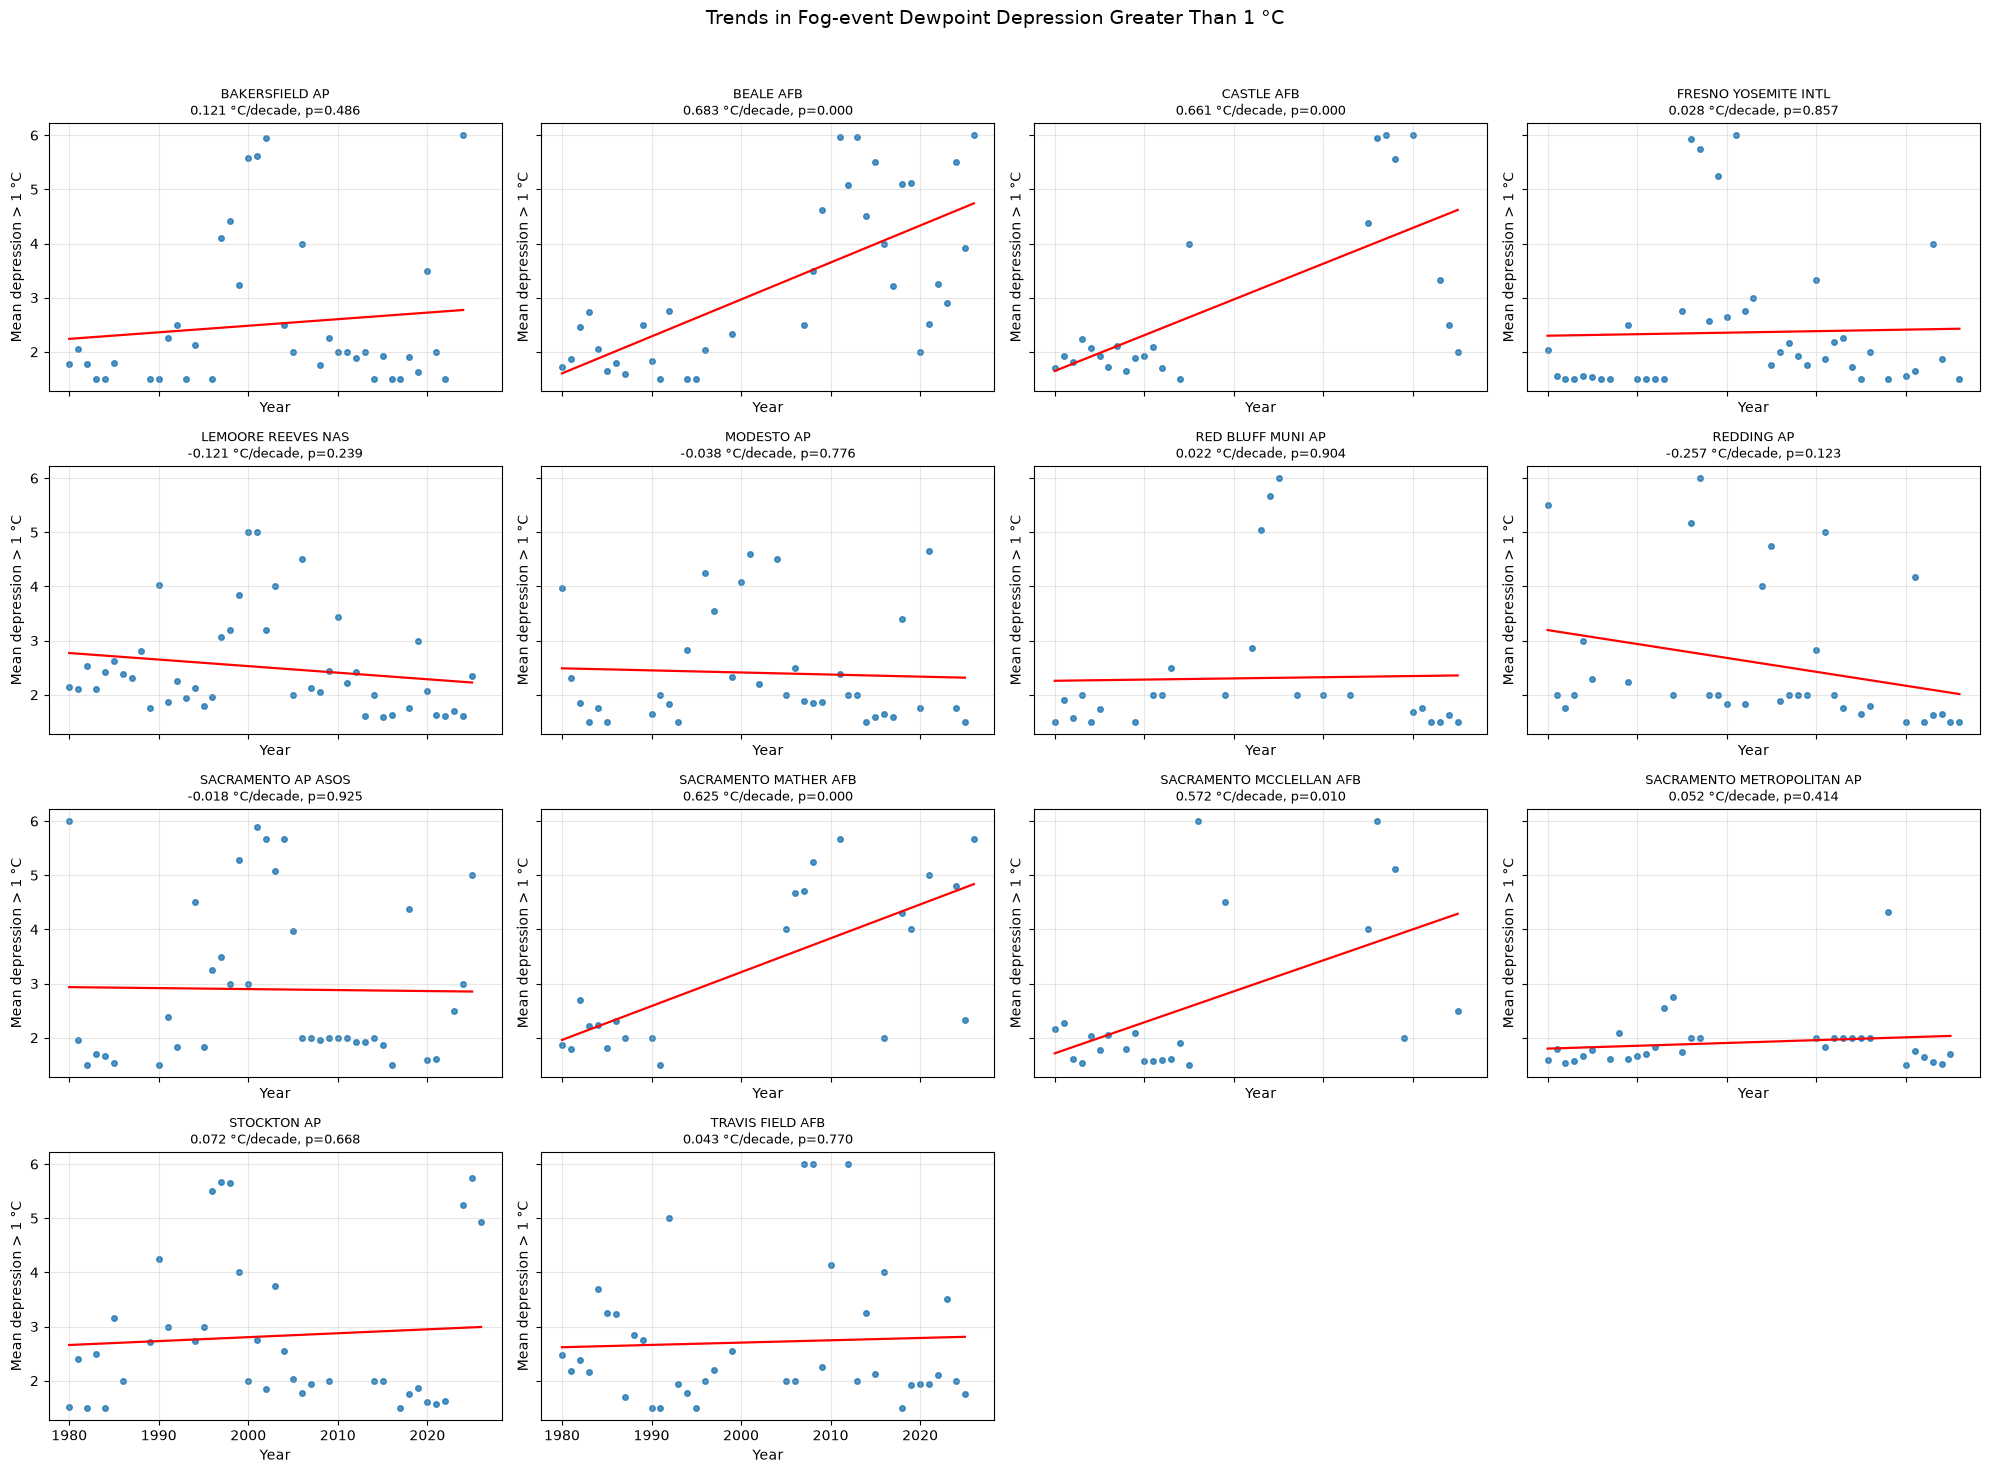

In [28]:
# Trends in fog-event dewpoint depression > 1 °C since 1980

trend_source = fog_event_long_1980.copy()
trend_source["DATE"] = pd.to_datetime(trend_source["DATE"], errors="coerce")
trend_source["year"] = trend_source["DATE"].dt.year

trend_source = trend_source[
    (trend_source["HourlyDewpointDepression"] > 1) &
    (trend_source["year"] >= 1980)
].dropna(subset=["STATION", "year", "HourlyDewpointDepression"])

# Annual mean depression above 1 °C by station
annual_dd_gt1 = (
    trend_source
    .groupby(["STATION", "year"], as_index=False)
    ["HourlyDewpointDepression"]
    .mean()
)

trend_rows = []

for station_name, group in annual_dd_gt1.groupby("STATION"):
    group = group.sort_values("year")

    if group["year"].nunique() < 2:
        continue

    fit = stats.linregress(
        group["year"],
        group["HourlyDewpointDepression"]
    )

    trend_rows.append({
        "STATION": station_name,
        "n_years": group["year"].nunique(),
        "slope_C_per_year": fit.slope,
        "slope_C_per_decade": fit.slope * 10,
        "p_value": fit.pvalue,
        "r_squared": fit.rvalue ** 2,
        "significant_p05": fit.pvalue < 0.05
    })

trends_dd_gt1 = (
    pd.DataFrame(trend_rows)
    .sort_values("slope_C_per_decade")
)

print(trends_dd_gt1)

# Plot annual means and linear trends
stations_gt1 = sorted(annual_dd_gt1["STATION"].unique())
ncols = 4
nrows = int(np.ceil(len(stations_gt1) / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5 * ncols, 3.6 * nrows),
    sharex=True,
    sharey=True
)
axes = np.asarray(axes).reshape(-1)

for i, station_name in enumerate(stations_gt1):
    ax = axes[i]
    group = annual_dd_gt1[
        annual_dd_gt1["STATION"] == station_name
    ].sort_values("year")

    x = group["year"].to_numpy()
    y = group["HourlyDewpointDepression"].to_numpy()
    fit = stats.linregress(x, y)

    ax.scatter(x, y, s=16, alpha=0.8)
    ax.plot(
        x,
        fit.intercept + fit.slope * x,
        color="red",
        linewidth=1.6
    )

    ax.set_title(
        f"{station_name}\n"
        f"{fit.slope * 10:.3f} °C/decade, p={fit.pvalue:.3f}",
        fontsize=9
    )
    ax.set_xlabel("Year")
    ax.set_ylabel("Mean depression > 1 °C")
    ax.grid(alpha=0.3)

for ax in axes[len(stations_gt1):]:
    ax.axis("off")

fig.suptitle(
    "Trends in Fog-event Dewpoint Depression Greater Than 1 °C",
    y=1.02,
    fontsize=14
)
plt.tight_layout()
plt.show()

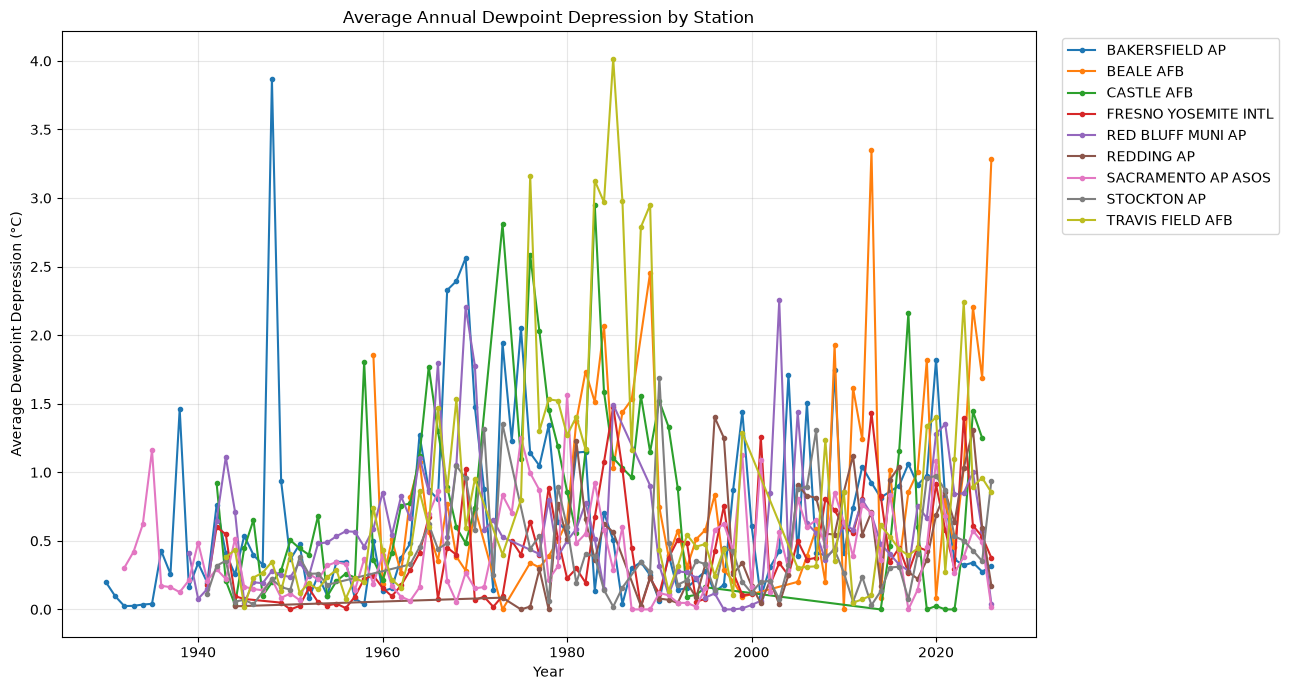

In [29]:
selected_stations = [
    "REDDING AP",
    "RED BLUFF MUNI AP",
    "BEALE AFB",
    "SACRAMENTO AP ASOS",
    "STOCKTON AP",
    "TRAVIS FIELD AFB",
    "CASTLE AFB",
    "FRESNO YOSEMITE INTL",
    "BAKERSFIELD AP",
]

plot_data = annual_station[
    annual_station["STATION"].isin(selected_stations)
].sort_values(["STATION", "year"])

fig, ax = plt.subplots(figsize=(13, 7))

for station_name, group in plot_data.groupby("STATION"):
    ax.plot(
        group["year"],
        group["HourlyDewpointDepression"],
        marker="o",
        markersize=3,
        linewidth=1.5,
        label=station_name
    )

ax.set_title("Average Annual Dewpoint Depression by Station")
ax.set_xlabel("Year")
ax.set_ylabel("Average Dewpoint Depression (°C)")
ax.grid(alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

                       STATION  slope_per_year  slope_per_decade  \
4           LEMOORE REEVES NAS       -0.037851         -0.378512   
13            TRAVIS FIELD AFB       -0.025090         -0.250899   
10    SACRAMENTO MCCLELLAN AFB       -0.012905         -0.129047   
9        SACRAMENTO MATHER AFB       -0.012287         -0.122873   
11  SACRAMENTO METROPOLITAN AP       -0.008503         -0.085034   
1                    BEALE AFB       -0.007346         -0.073459   
5                   MODESTO AP       -0.006881         -0.068809   
2                   CASTLE AFB       -0.004300         -0.042997   
3         FRESNO YOSEMITE INTL       -0.001335         -0.013345   
6            RED BLUFF MUNI AP        0.000997          0.009968   
8           SACRAMENTO AP ASOS        0.001032          0.010324   
7                   REDDING AP        0.001113          0.011133   
12                 STOCKTON AP        0.003587          0.035875   
0               BAKERSFIELD AP        0.003706  

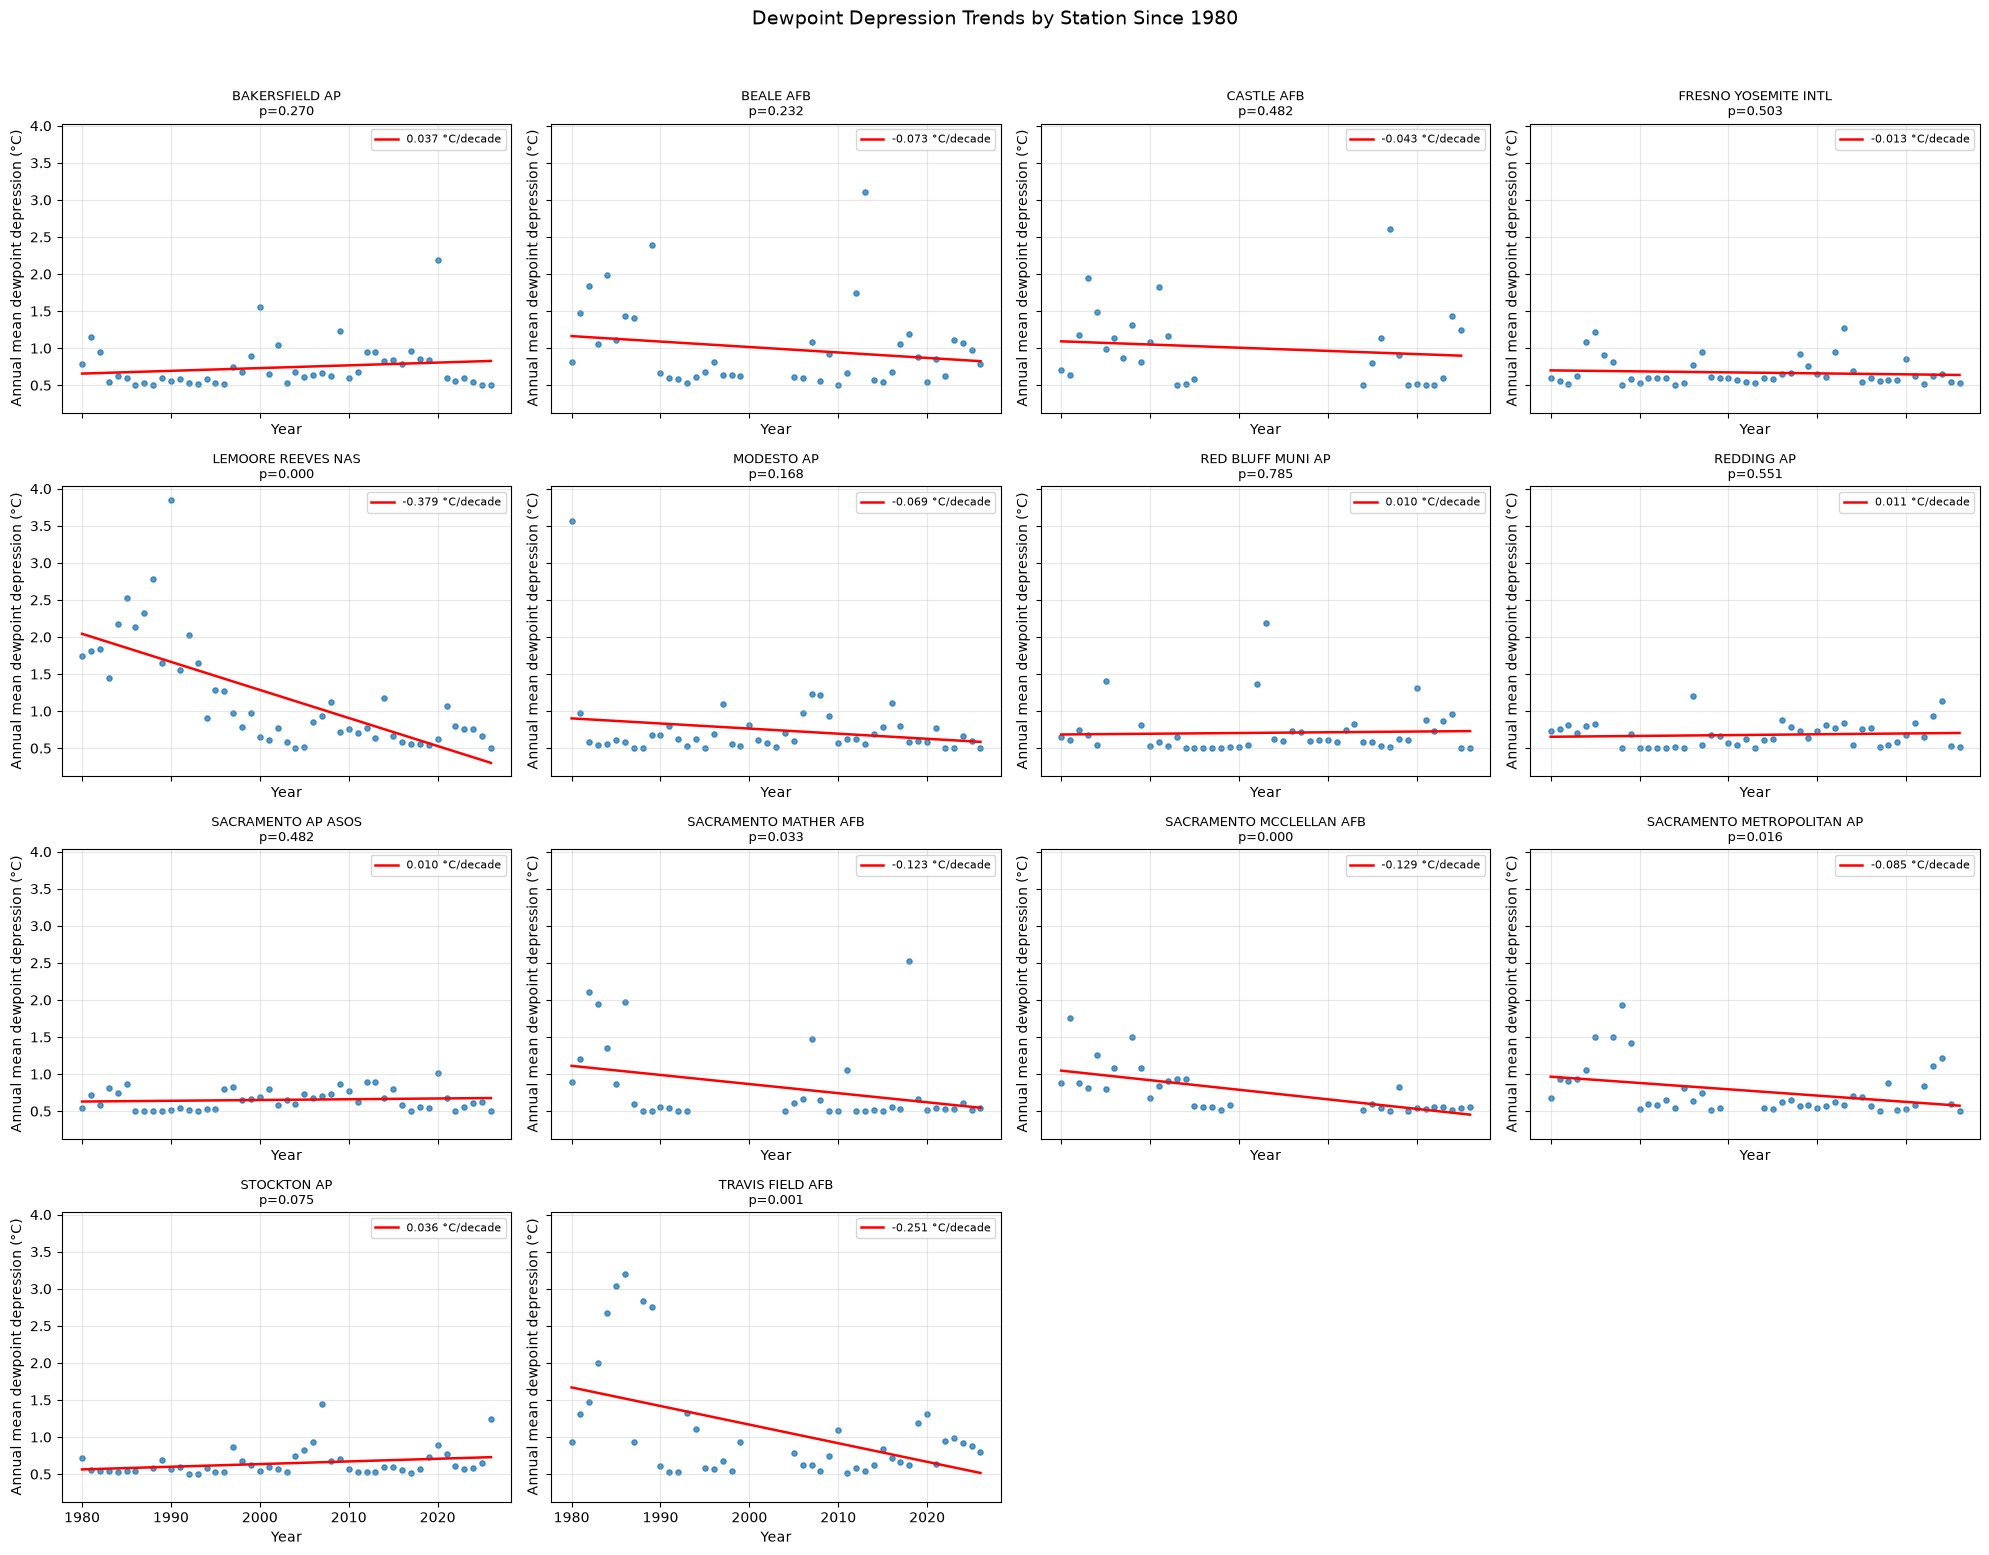

In [30]:
# Fit linear trends to annual mean dewpoint depression for each station

trend_source = fog_event_long_1980.copy()
trend_source["DATE"] = pd.to_datetime(trend_source["DATE"], errors="coerce")
trend_source["year"] = trend_source["DATE"].dt.year

station_year_dd = (
    trend_source
    .groupby(["STATION", "year"], as_index=False)["HourlyDewpointDepression"]
    .mean()
)

trend_results = []

for station_name, group in station_year_dd.groupby("STATION"):
    group = group.sort_values("year")

    if group["year"].nunique() < 2:
        continue

    fit = stats.linregress(
        group["year"],
        group["HourlyDewpointDepression"]
    )

    trend_results.append({
        "STATION": station_name,
        "slope_per_year": fit.slope,
        "slope_per_decade": fit.slope * 10,
        "p_value": fit.pvalue,
        "r_squared": fit.rvalue ** 2,
        "n_years": group["year"].nunique()
    })

trend_results = (
    pd.DataFrame(trend_results)
    .sort_values("slope_per_year")
)

print(trend_results)

# Plot station-level trends
stations_trend = sorted(station_year_dd["STATION"].unique())
ncols = 4
nrows = int(np.ceil(len(stations_trend) / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5 * ncols, 3.8 * nrows),
    sharex=True,
    sharey=True
)

axes = np.asarray(axes).reshape(-1)

for i, station_name in enumerate(stations_trend):
    ax = axes[i]
    group = station_year_dd[
        station_year_dd["STATION"] == station_name
    ].sort_values("year")

    x = group["year"].to_numpy()
    y = group["HourlyDewpointDepression"].to_numpy()

    fit = stats.linregress(x, y)
    x_line = np.array([x.min(), x.max()])
    y_line = fit.intercept + fit.slope * x_line

    ax.scatter(x, y, s=14, alpha=0.75)
    ax.plot(
        x_line,
        y_line,
        color="red",
        linewidth=1.8,
        label=f"{fit.slope * 10:.3f} °C/decade"
    )

    ax.set_title(
        f"{station_name}\np={fit.pvalue:.3f}",
        fontsize=9
    )
    ax.set_xlabel("Year")
    ax.set_ylabel("Annual mean dewpoint depression (°C)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

for ax in axes[len(stations_trend):]:
    ax.axis("off")

fig.suptitle(
    "Dewpoint Depression Trends by Station Since 1980",
    y=1.02,
    fontsize=14
)

plt.tight_layout()
plt.show()

In [31]:
# Trends in individual fog-event-hour dewpoint depression since 1980

selected_stations = [
    "BAKERSFIELD AP",
    "FRESNO YOSEMITE INTL",
    "RED BLUFF MUNI AP",
    "SACRAMENTO AP ASOS",
    "STOCKTON AP",
    "TRAVIS FIELD AFB",
]

# Prepare data for hourly dewpoint depression trends
fog_hourly_trends_source = fog_event_dd.copy()
fog_hourly_trends_source["DATE"] = pd.to_datetime(
    fog_hourly_trends_source["DATE"], errors="coerce"
)

fog_hourly_trends_source = fog_hourly_trends_source[
    fog_hourly_trends_source["STATION"].isin(selected_stations)
    & (fog_hourly_trends_source["DATE"].dt.year >= 1980)
].dropna(subset=["DATE", "HourlyDewpointDepression"]).copy()

fog_hourly_trends_source["year"] = (
    fog_hourly_trends_source["DATE"].dt.year
)

hourly_trend_rows = []

for station_name, group in fog_hourly_trends_source.groupby("STATION"):
    if group["year"].nunique() < 2:
        continue

    fit = stats.linregress(
        group["year"],
        group["HourlyDewpointDepression"]
    )

    hourly_trend_rows.append({
        "STATION": station_name,
        "n_fog_event_hours": len(group),
        "n_years": group["year"].nunique(),
        "slope_C_per_year": fit.slope,
        "slope_C_per_decade": fit.slope * 10,
        "p_value": fit.pvalue,
        "r_squared": fit.rvalue ** 2,
        "significant_p05": fit.pvalue < 0.05
    })

fog_hourly_trends = (
    pd.DataFrame(hourly_trend_rows)
    .set_index("STATION")
    .reindex(selected_stations)
)

print(fog_hourly_trends)

                      n_fog_event_hours  n_years  slope_C_per_year  \
STATION                                                              
BAKERSFIELD AP                     7204       47          0.003475   
FRESNO YOSEMITE INTL              11749       47          0.001072   
RED BLUFF MUNI AP                  3542       44         -0.000994   
SACRAMENTO AP ASOS                11007       47          0.001252   
STOCKTON AP                       12426       46          0.009687   
TRAVIS FIELD AFB                  10512       42         -0.028219   

                      slope_C_per_decade        p_value  r_squared  \
STATION                                                              
BAKERSFIELD AP                  0.034755   1.244693e-07   0.003874   
FRESNO YOSEMITE INTL            0.010721   1.247907e-02   0.000531   
RED BLUFF MUNI AP              -0.009941   2.629867e-01   0.000354   
SACRAMENTO AP ASOS              0.012523   9.057204e-03   0.000619   
STOCKTON AP        

In [32]:
# Exclude dewpoint depression outliers during fog events using IQR
fog_dd_df = CV_fog_rows.dropna(subset=["HourlyDewpointDepression"]).copy()

q1 = fog_dd_df["HourlyDewpointDepression"].quantile(0.25)
q3 = fog_dd_df["HourlyDewpointDepression"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

fog_dd_no_outliers = fog_dd_df[
    fog_dd_df["HourlyDewpointDepression"].between(lower, upper, inclusive="both")
].copy()

print(f"IQR bounds: [{lower:.3f}, {upper:.3f}]")
print("Original fog-event rows:", len(fog_dd_df))
print("Rows after outlier removal:", len(fog_dd_no_outliers))
print("Rows removed:", len(fog_dd_df) - len(fog_dd_no_outliers))

fog_dd_no_outliers.head()

IQR bounds: [-1.500, 2.500]
Original fog-event rows: 246728
Rows after outlier removal: 239654
Rows removed: 7074


,STATION_ID,LATITUDE,LONGITUDE,DATE,REPORT_TYPE,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyPrecipitation,HourlyPresentWeatherType,HourlySkyConditions,HourlyVisibility,HourlyWindDirection,HourlyWindSpeed,year,month,day,hour,minute,STATION,HourlyDewpointDepression
6,USM00074917,35.117,-119.3,1941-12-01 06:00:00,SAO,11.9,11.9,0.0,||FG,NaN,0.2,45.0,0.5,1941,12,1,6,0,GARDNER AAF,0.0
7,USM00074917,35.117,-119.3,1941-12-01 07:00:00,SAO,11.9,11.9,0.0,||FG,NaN,0.0,315.0,0.5,1941,12,1,7,0,GARDNER AAF,0.0
8,USM00074917,35.117,-119.3,1941-12-01 08:00:00,SAO,11.9,11.9,0.0,||FG,NaN,0.0,90.0,0.5,1941,12,1,8,0,GARDNER AAF,0.0
9,USM00074917,35.117,-119.3,1941-12-01 09:00:00,SAO,11.9,11.9,0.0,||FG,NaN,0.2,0.0,0.0,1941,12,1,9,0,GARDNER AAF,0.0
10,USM00074917,35.117,-119.3,1941-12-01 10:00:00,SAO,12.4,13.5,0.0,||FG,OVC:08,0.8,158.0,0.5,1941,12,1,10,0,GARDNER AAF,1.1


=== Since-1980 trend (all stations combined) ===
(0,1] share slope: 0.3875 %-points/year (3.875 per decade), p=6.998e-05
(1,2] share slope: -0.4071 %-points/year (-4.071 per decade), p=0.00321


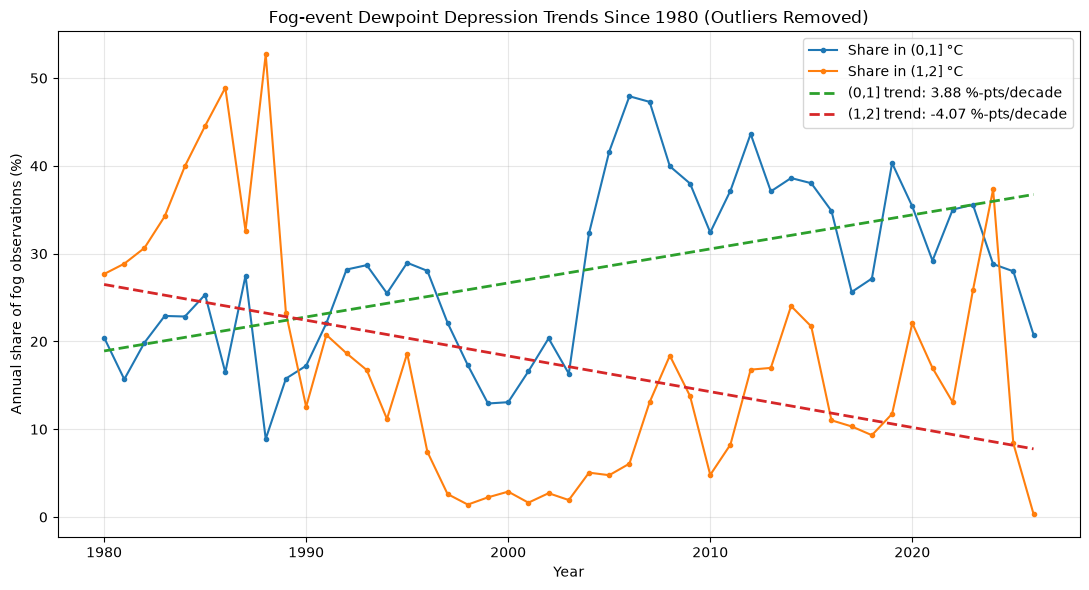


=== Station-level trend summary (>=10 years) ===
                       STATION  n_years  slope_pct01_per_year       p_pct01  \
22        VISALIA MUNICIPAL AP       22             -2.466610  6.661265e-05   
1                    BEALE AFB       41              0.445642  9.906275e-02   
17    SACRAMENTO MCCLELLAN AFB       32             -0.465898  4.312959e-04   
2                   CASTLE AFB       28             -0.035845  8.801371e-01   
16       SACRAMENTO MATHER AFB       37             -0.450184  3.588511e-04   
18  SACRAMENTO METROPOLITAN AP       42              0.348093  9.452273e-02   
20            TRAVIS FIELD AFB       41              1.257868  9.491122e-07   
6           LEMOORE REEVES NAS       47              1.050609  6.323054e-07   
4         FRESNO YOSEMITE INTL       47              0.740497  1.345233e-04   
21  VACAVILLE/NUT TREE AP ASOS       18              1.490573  1.922980e-01   
14                  REDDING AP       45              0.922075  2.288111e-06   
15

In [33]:
# Since-1980 subset from outlier-filtered fog events
fog_dd_1980 = fog_dd_no_outliers.copy()
fog_dd_1980["DATE"] = pd.to_datetime(fog_dd_1980["DATE"], errors="coerce")
fog_dd_1980 = fog_dd_1980.dropna(subset=["DATE", "HourlyDewpointDepression"])
fog_dd_1980 = fog_dd_1980[fog_dd_1980["DATE"].dt.year >= 1980].copy()
fog_dd_1980["year"] = fog_dd_1980["DATE"].dt.year

# Indicators:
# (0,1] = dewpoint depression >0 and <=1
# (1,2] = dewpoint depression >1 and <=2
fog_dd_1980["dd_0_1"] = (
    (fog_dd_1980["HourlyDewpointDepression"] > 0) &
    (fog_dd_1980["HourlyDewpointDepression"] <= 1)
).astype(int)

fog_dd_1980["dd_1_2"] = (
    (fog_dd_1980["HourlyDewpointDepression"] > 1) &
    (fog_dd_1980["HourlyDewpointDepression"] <= 2)
).astype(int)

# Annual aggregate (all stations combined)
annual_dd = (
    fog_dd_1980.groupby("year", as_index=False)
    .agg(
        total_fog_obs=("HourlyDewpointDepression", "size"),
        n_dd_0_1=("dd_0_1", "sum"),
        n_dd_1_2=("dd_1_2", "sum")
    )
)

annual_dd["pct_dd_0_1"] = 100 * annual_dd["n_dd_0_1"] / annual_dd["total_fog_obs"]
annual_dd["pct_dd_1_2"] = 100 * annual_dd["n_dd_1_2"] / annual_dd["total_fog_obs"]

# Trend analysis (linear)
fit_01 = stats.linregress(annual_dd["year"], annual_dd["pct_dd_0_1"])
fit_02 = stats.linregress(annual_dd["year"], annual_dd["pct_dd_1_2"])

print("=== Since-1980 trend (all stations combined) ===")
print(f"(0,1] share slope: {fit_01.slope:.4f} %-points/year ({fit_01.slope*10:.3f} per decade), p={fit_01.pvalue:.4g}")
print(f"(1,2] share slope: {fit_02.slope:.4f} %-points/year ({fit_02.slope*10:.3f} per decade), p={fit_02.pvalue:.4g}")

# Plot annual shares + trend lines
x = annual_dd["year"].to_numpy()
y01 = annual_dd["pct_dd_0_1"].to_numpy()
y02 = annual_dd["pct_dd_1_2"].to_numpy()

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(x, y01, marker="o", markersize=3, linewidth=1.5, label="Share in (0,1] °C")
ax.plot(x, y02, marker="o", markersize=3, linewidth=1.5, label="Share in (1,2] °C")

ax.plot(x, fit_01.intercept + fit_01.slope * x, linestyle="--", linewidth=2,
        label=f"(0,1] trend: {fit_01.slope*10:.2f} %-pts/decade")
ax.plot(x, fit_02.intercept + fit_02.slope * x, linestyle="--", linewidth=2,
        label=f"(1,2] trend: {fit_02.slope*10:.2f} %-pts/decade")

ax.set_title("Fog-event Dewpoint Depression Trends Since 1980 (Outliers Removed)")
ax.set_xlabel("Year")
ax.set_ylabel("Annual share of fog observations (%)")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Optional station-level trend summary (shares), requiring >=10 years
station_year = (
    fog_dd_1980.groupby(["STATION", "year"], as_index=False)
    .agg(
        total=("HourlyDewpointDepression", "size"),
        n01=("dd_0_1", "sum"),
        n02=("dd_1_2", "sum")
    )
)
station_year["pct01"] = 100 * station_year["n01"] / station_year["total"]
station_year["pct12"] = 100 * station_year["n02"] / station_year["total"]

station_trends = []
for st, g in station_year.groupby("STATION"):
    if g["year"].nunique() < 10:
        continue
    g = g.sort_values("year")
    t01 = stats.linregress(g["year"], g["pct01"])
    t02 = stats.linregress(g["year"], g["pct12"])
    station_trends.append({
        "STATION": st,
        "n_years": g["year"].nunique(),
        "slope_pct01_per_year": t01.slope,
        "p_pct01": t01.pvalue,
        "sig_pct01": t01.pvalue < 0.05,
        "slope_pct12_per_year": t02.slope,
        "p_pct12": t02.pvalue,
        "sig_pct12": t02.pvalue < 0.05
    })

station_trends = pd.DataFrame(station_trends).sort_values("slope_pct12_per_year")
print("\n=== Station-level trend summary (>=10 years) ===")
print(station_trends)
print("\nSignificant station trends for (0,1] share (p<0.05):")
print(station_trends[station_trends["sig_pct01"]][["STATION", "slope_pct01_per_year", "p_pct01"]])
print("\nSignificant station trends for (1,2] share (p<0.05):")
print(station_trends[station_trends["sig_pct12"]][["STATION", "slope_pct12_per_year", "p_pct12"]])

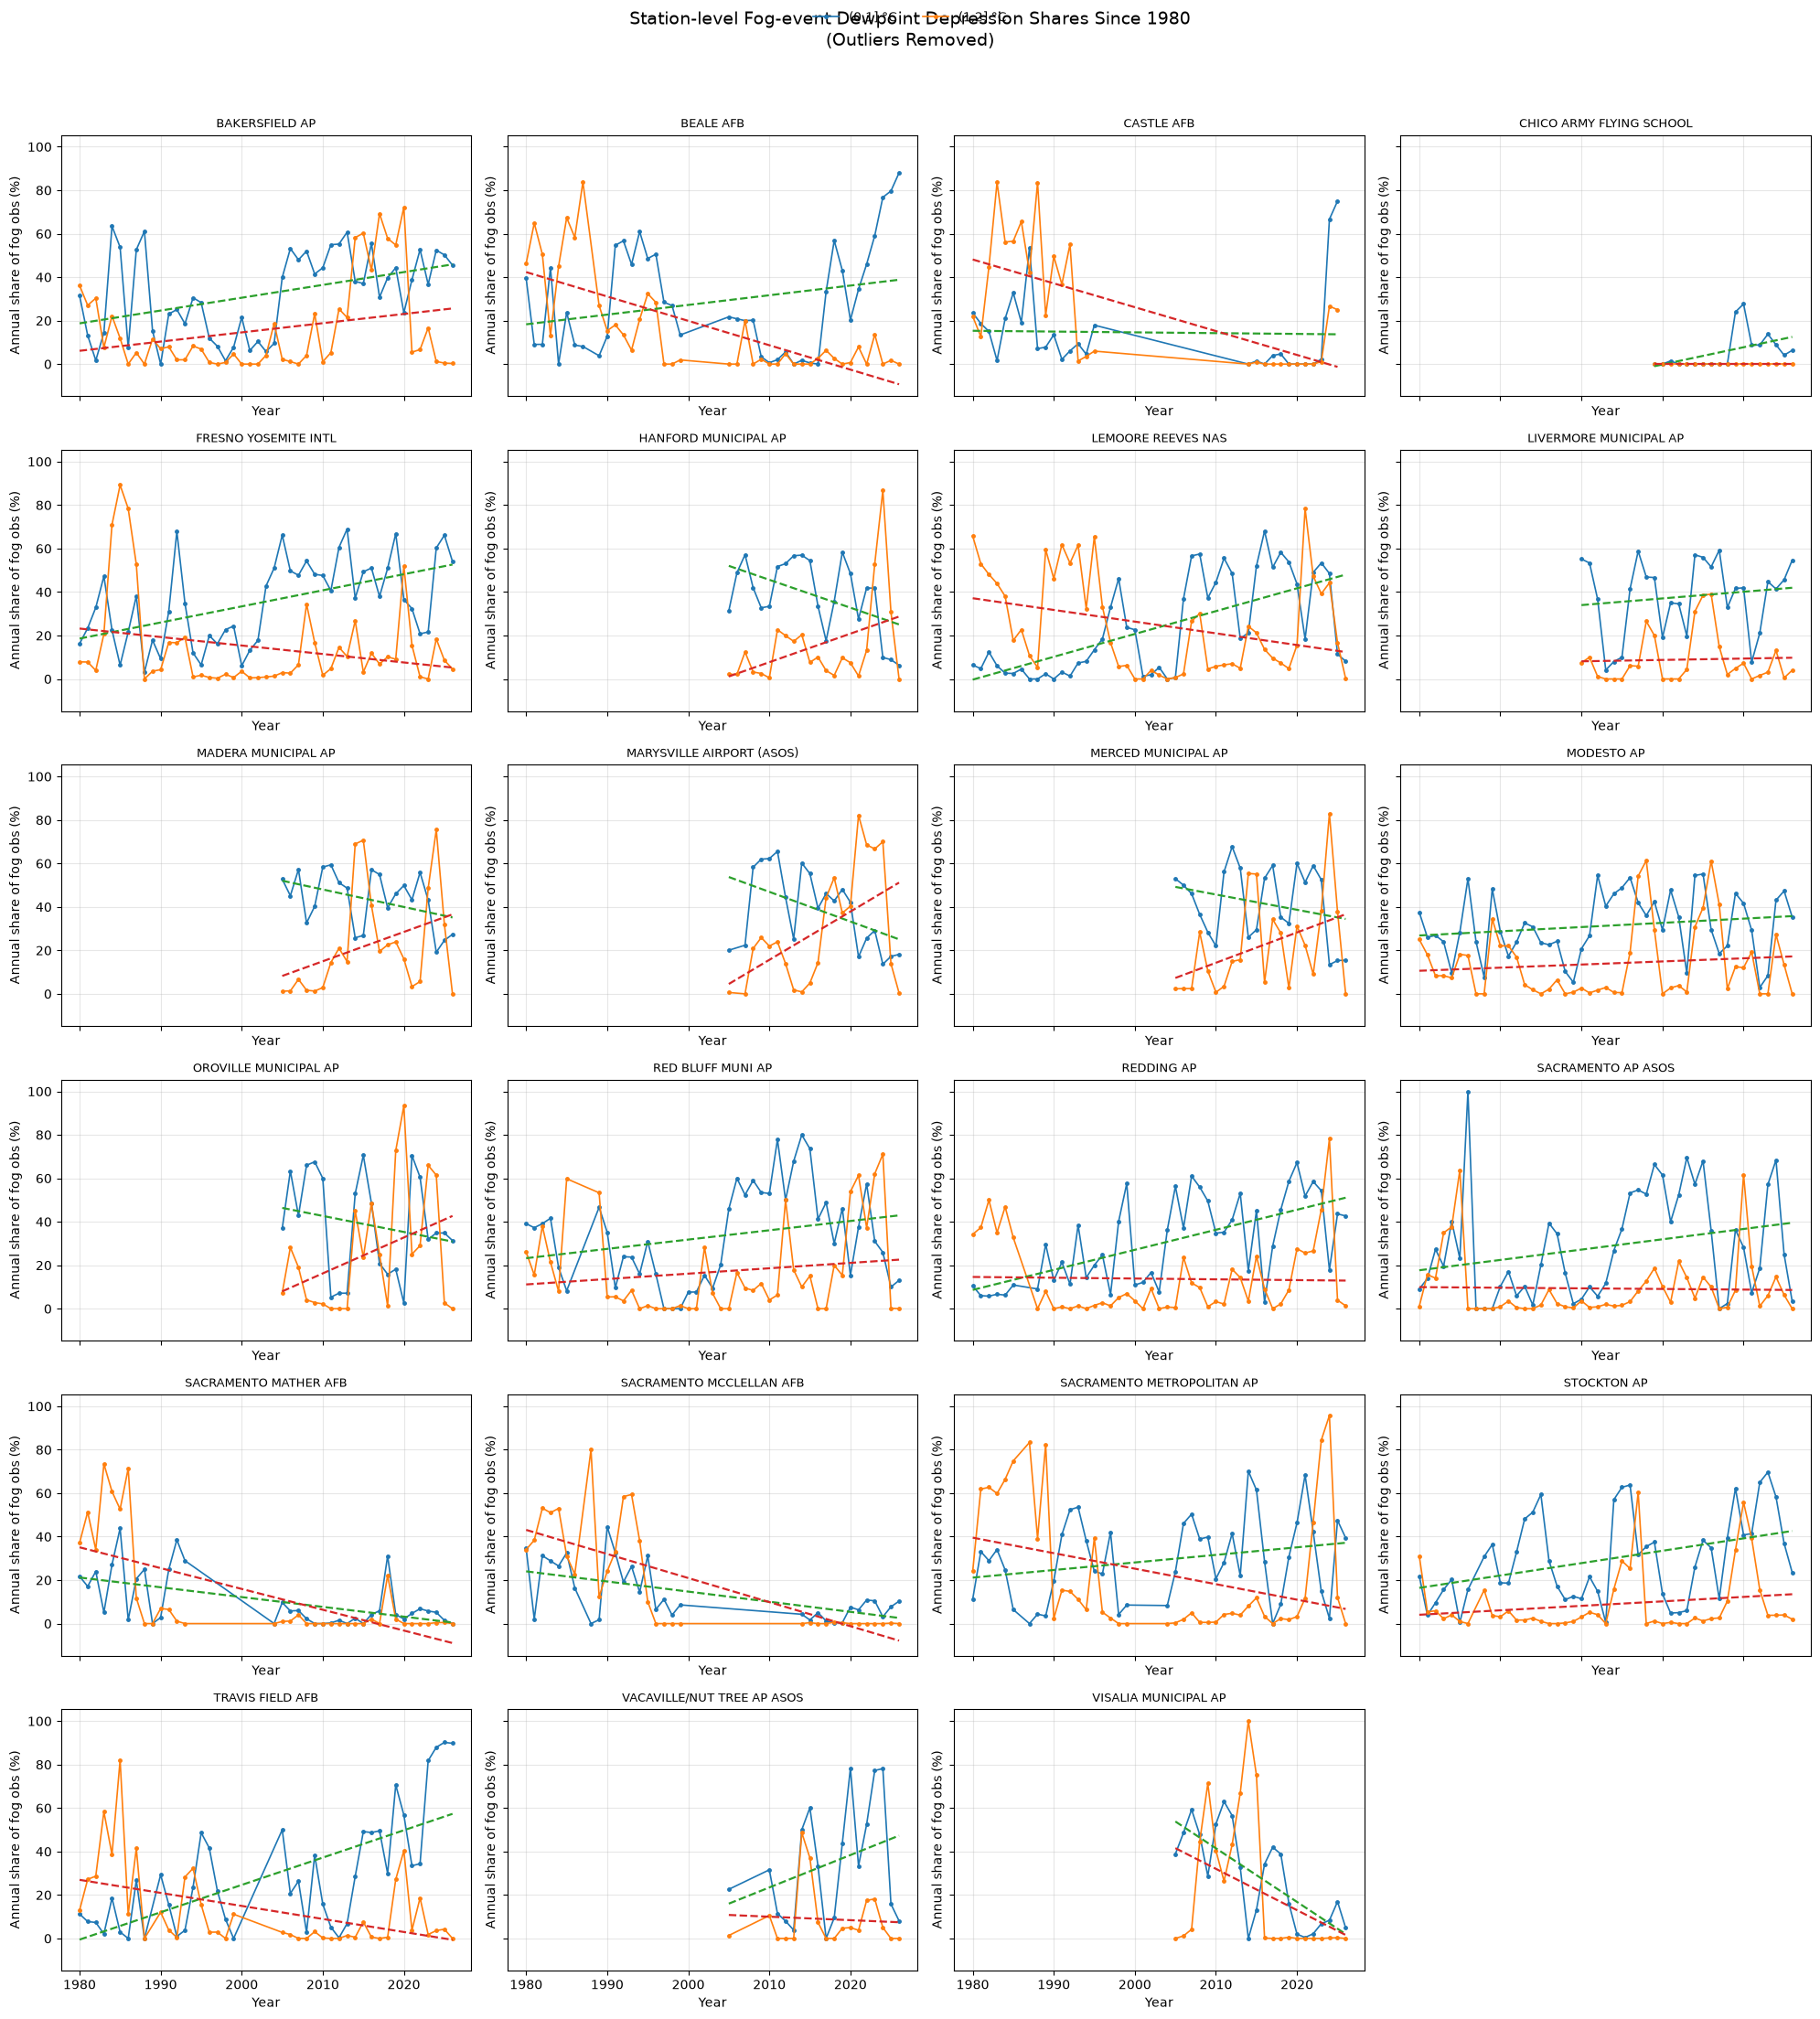

In [35]:
# Individual-station version of the annual_dd plot (since 1980, outliers removed)

# Reuse station_year if available; otherwise rebuild from fog_dd_1980
if "station_year" not in globals():
    station_year = (
        fog_dd_1980.groupby(["STATION", "year"], as_index=False)
        .agg(
            total=("HourlyDewpointDepression", "size"),
            n01=("dd_0_1", "sum"),
            n02=("dd_1_2", "sum")
        )
    )
    station_year["pct01"] = 100 * station_year["n01"] / station_year["total"]
    station_year["pct12"] = 100 * station_year["n02"] / station_year["total"]

# Keep stations with enough years for trends
min_years = 10
valid_counts = station_year.groupby("STATION")["year"].nunique()
stations_plot = sorted(valid_counts[valid_counts >= min_years].index)

n_stations = len(stations_plot)
if n_stations == 0:
    print(f"No stations with >= {min_years} years of data.")
else:
    ncols = 4
    nrows = int(np.ceil(n_stations / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(5 * ncols, 3.6 * nrows),
        sharex=True,
        sharey=True
    )
    axes = np.array(axes).reshape(-1)

    for i, stn in enumerate(stations_plot):
        ax = axes[i]
        g = station_year[station_year["STATION"] == stn].sort_values("year")

        x = g["year"].to_numpy()
        y01 = g["pct01"].to_numpy()
        y02 = g["pct12"].to_numpy()

        ax.plot(x, y01, marker="o", markersize=2.5, linewidth=1.2, label="(0,1] °C")
        ax.plot(x, y02, marker="o", markersize=2.5, linewidth=1.2, label="(1,2] °C")

        if g["year"].nunique() >= 2:
            fit01 = stats.linregress(x, y01)
            fit02 = stats.linregress(x, y02)
            ax.plot(x, fit01.intercept + fit01.slope * x, linestyle="--", linewidth=1.6)
            ax.plot(x, fit02.intercept + fit02.slope * x, linestyle="--", linewidth=1.6)

        ax.set_title(stn, fontsize=9)
        ax.set_xlabel("Year")
        ax.set_ylabel("Annual share of fog obs (%)")
        ax.grid(alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)

    fig.suptitle(
        "Station-level Fog-event Dewpoint Depression Shares Since 1980\n(Outliers Removed)",
        y=1.02,
        fontsize=14
    )
    plt.tight_layout()
    plt.show()

                       STATION  n_years  slope_per_year  slope_per_decade  \
22        VISALIA MUNICIPAL AP       22       -0.064007         -0.640073   
6           LEMOORE REEVES NAS       47       -0.029721         -0.297210   
1                    BEALE AFB       41       -0.022856         -0.228559   
17    SACRAMENTO MCCLELLAN AFB       32       -0.022218         -0.222183   
16       SACRAMENTO MATHER AFB       37       -0.021550         -0.215498   
2                   CASTLE AFB       28       -0.018028         -0.180283   
18  SACRAMENTO METROPOLITAN AP       42       -0.012168         -0.121685   
20            TRAVIS FIELD AFB       41       -0.010942         -0.109422   
7       LIVERMORE MUNICIPAL AP       27       -0.002470         -0.024704   
4         FRESNO YOSEMITE INTL       47        0.000151          0.001508   
11                  MODESTO AP       47        0.000751          0.007513   
15          SACRAMENTO AP ASOS       47        0.003634          0.036335   

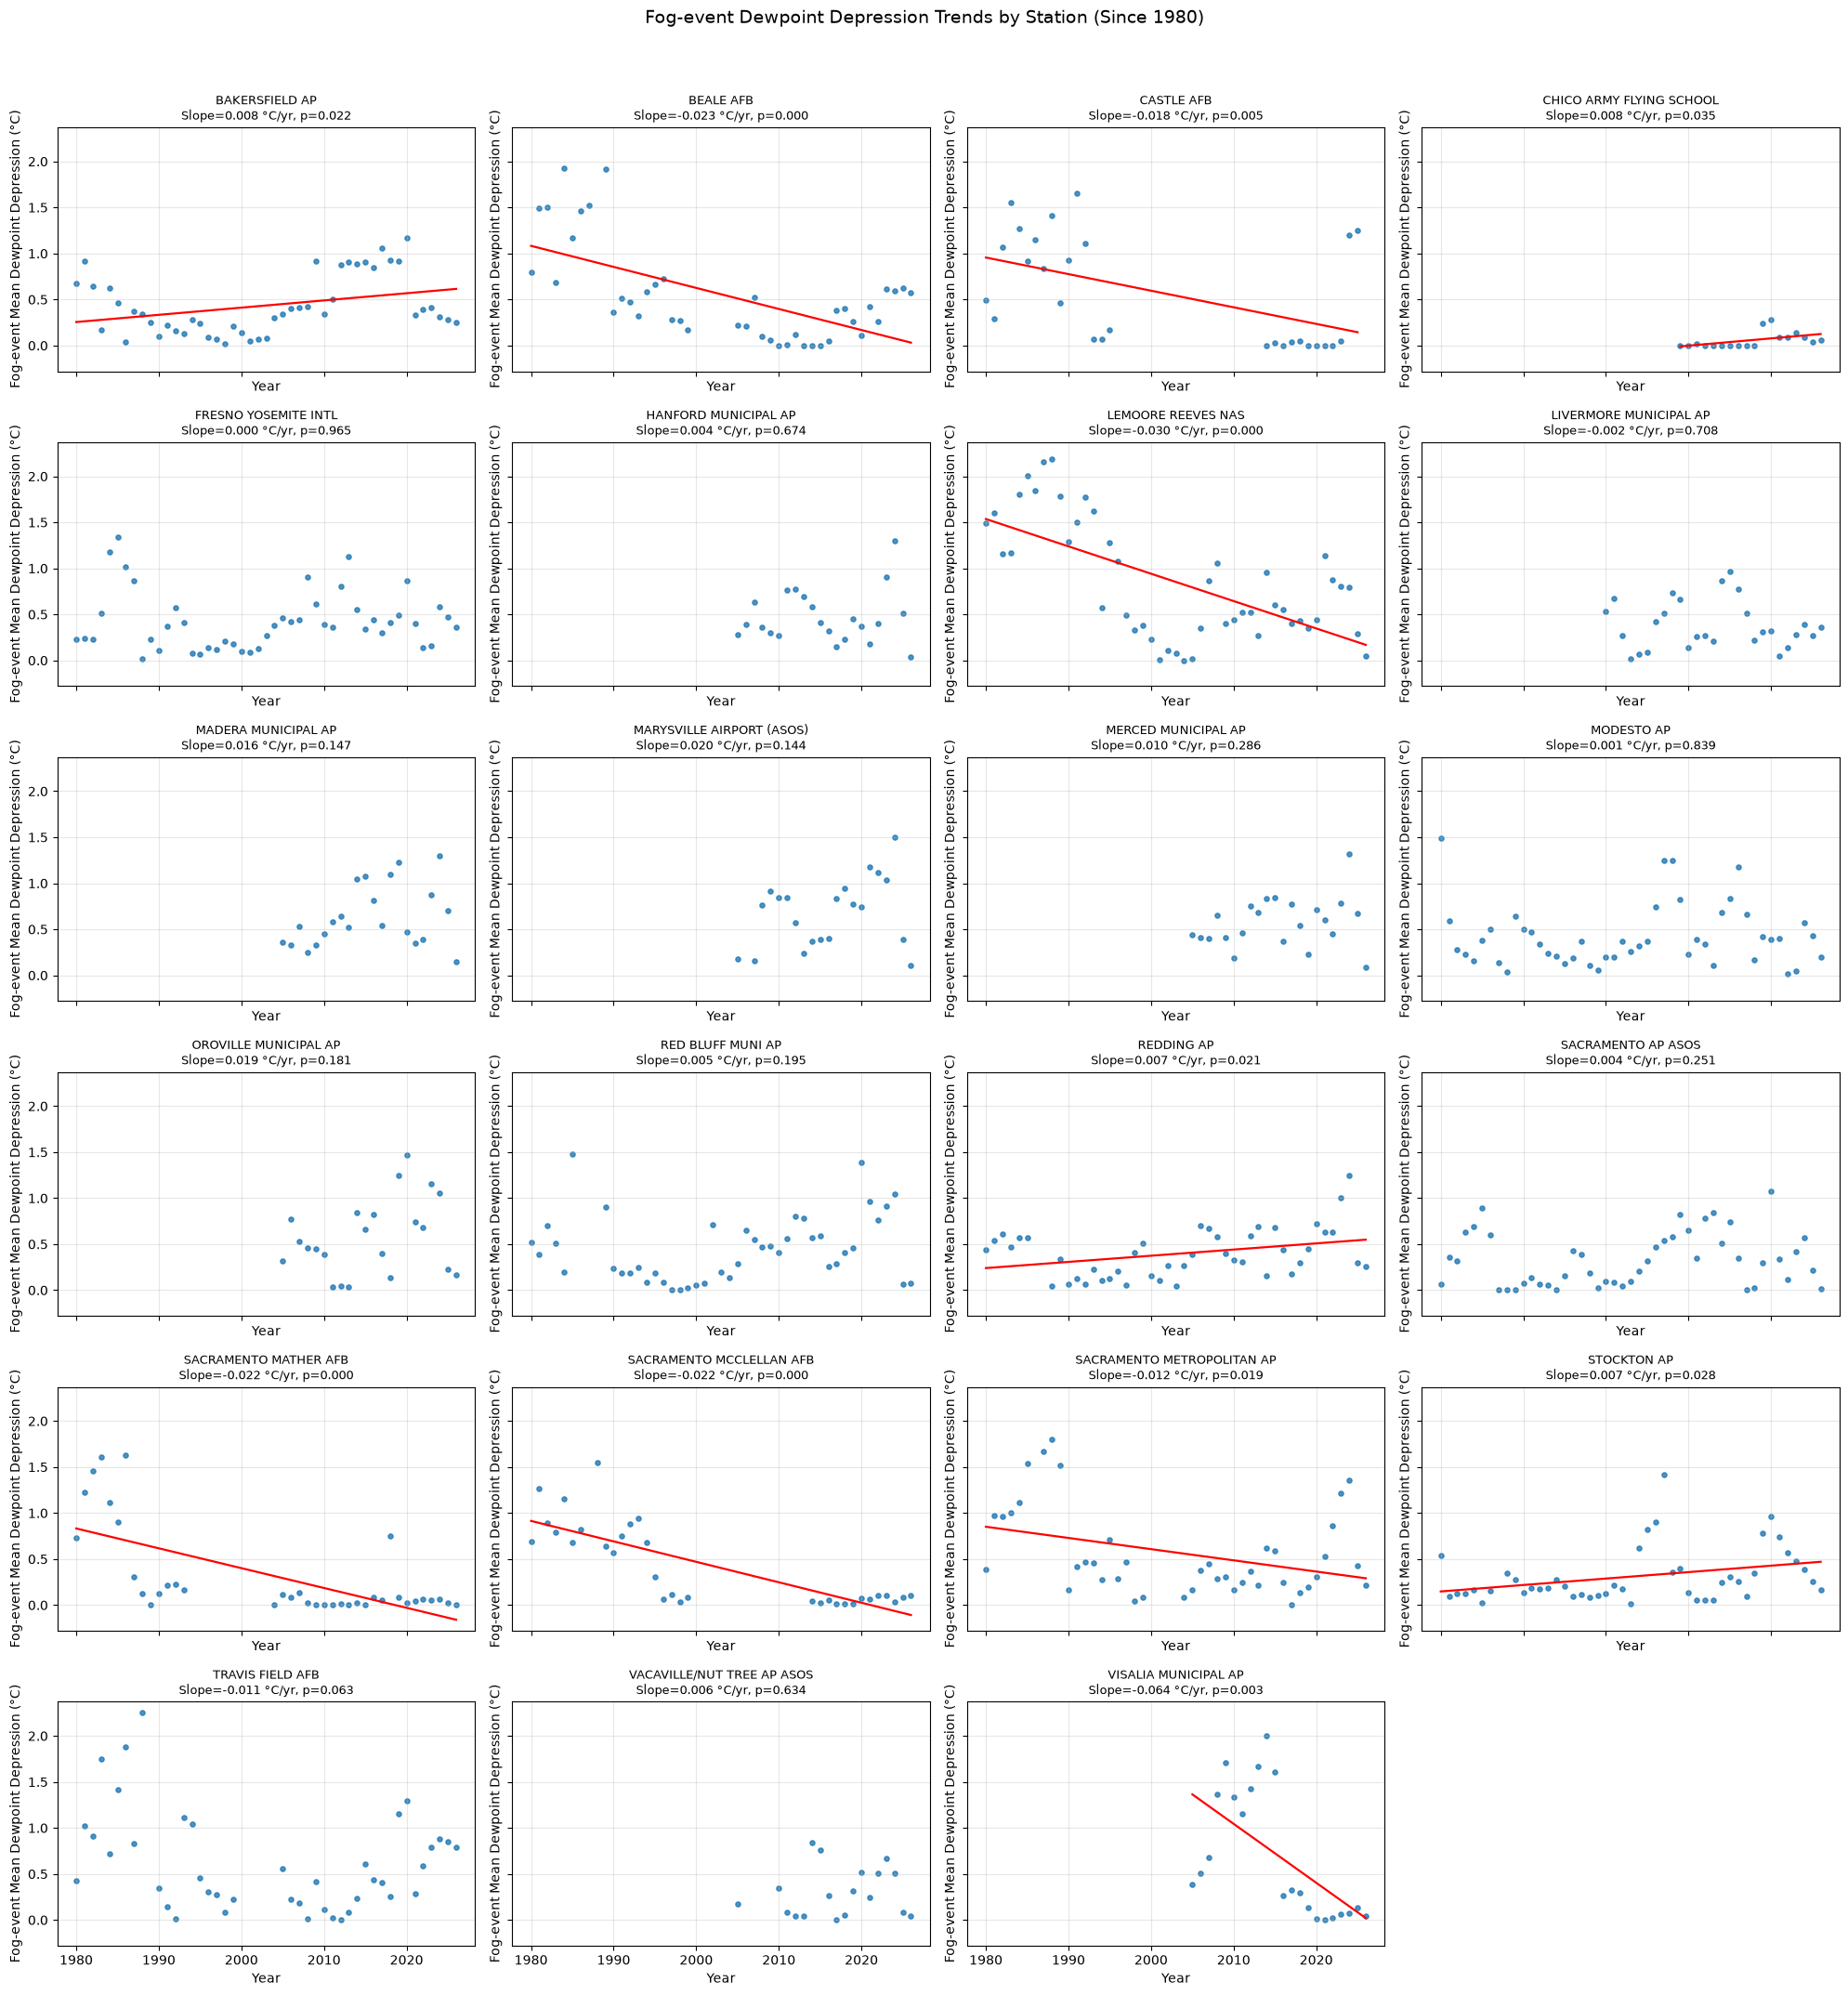

In [36]:
# Dewpoint depression trends for fog events (since 1980)

# Choose source dataframe
if "fog_dd_no_outliers" in globals():
    fog_trend_source = fog_dd_no_outliers.copy()
elif "fog_dd_df" in globals():
    fog_trend_source = fog_dd_df.copy()
else:
    fog_trend_source = CV_fog_rows.dropna(subset=["HourlyDewpointDepression"]).copy()

# Prepare time fields
fog_trend_source["DATE"] = pd.to_datetime(fog_trend_source["DATE"], errors="coerce")
fog_trend_source = fog_trend_source.dropna(subset=["DATE", "HourlyDewpointDepression"])
fog_trend_source = fog_trend_source[fog_trend_source["DATE"].dt.year >= 1980].copy()
fog_trend_source["year"] = fog_trend_source["DATE"].dt.year

# Annual mean dewpoint depression per station
fog_station_year = (
    fog_trend_source.groupby(["STATION", "year"], as_index=False)["HourlyDewpointDepression"]
    .mean()
)

# Keep stations with enough years
min_years = 10
counts = fog_station_year.groupby("STATION")["year"].nunique()
trend_stations = sorted(counts[counts >= min_years].index)

# Compute trends
trend_rows = []
for stn, g in fog_station_year[fog_station_year["STATION"].isin(trend_stations)].groupby("STATION"):
    g = g.sort_values("year")
    fit = stats.linregress(g["year"], g["HourlyDewpointDepression"])
    trend_rows.append({
        "STATION": stn,
        "n_years": g["year"].nunique(),
        "slope_per_year": fit.slope,
        "slope_per_decade": fit.slope * 10,
        "p_value": fit.pvalue,
        "r_value": fit.rvalue,
        "significant": fit.pvalue < 0.05
    })

fog_station_trends = pd.DataFrame(trend_rows).sort_values("slope_per_year")
print(fog_station_trends)

# Plot
n_stations = len(trend_stations)
if n_stations == 0:
    print(f"No stations with >= {min_years} years of fog-event data since 1980.")
else:
    ncols = 4
    nrows = int(np.ceil(n_stations / ncols))
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(5 * ncols, 3.5 * nrows),
        sharex=True, sharey=True
    )
    axes = np.array(axes).reshape(-1)

    for i, stn in enumerate(trend_stations):
        ax = axes[i]
        g = fog_station_year[fog_station_year["STATION"] == stn].sort_values("year")

        ax.scatter(g["year"], g["HourlyDewpointDepression"], s=14, alpha=0.8)

        fit = stats.linregress(g["year"], g["HourlyDewpointDepression"])
        x = np.array([g["year"].min(), g["year"].max()])
        # only plot the fitted line if the trend is significant at p<0.05
        if fit.pvalue < 0.05:
            y = fit.intercept + fit.slope * x
            ax.plot(x, y, color="red", linewidth=1.6)

        ax.set_title(f"{stn}\nSlope={fit.slope:.3f} °C/yr, p={fit.pvalue:.3f}", fontsize=9)
        ax.set_xlabel("Year")
        ax.set_ylabel("Fog-event Mean Dewpoint Depression (°C)")
        ax.grid(alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle("Fog-event Dewpoint Depression Trends by Station (Since 1980)", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

C:\Users\Work Account\AppData\Local\Temp\ipykernel_9252\2342315008.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


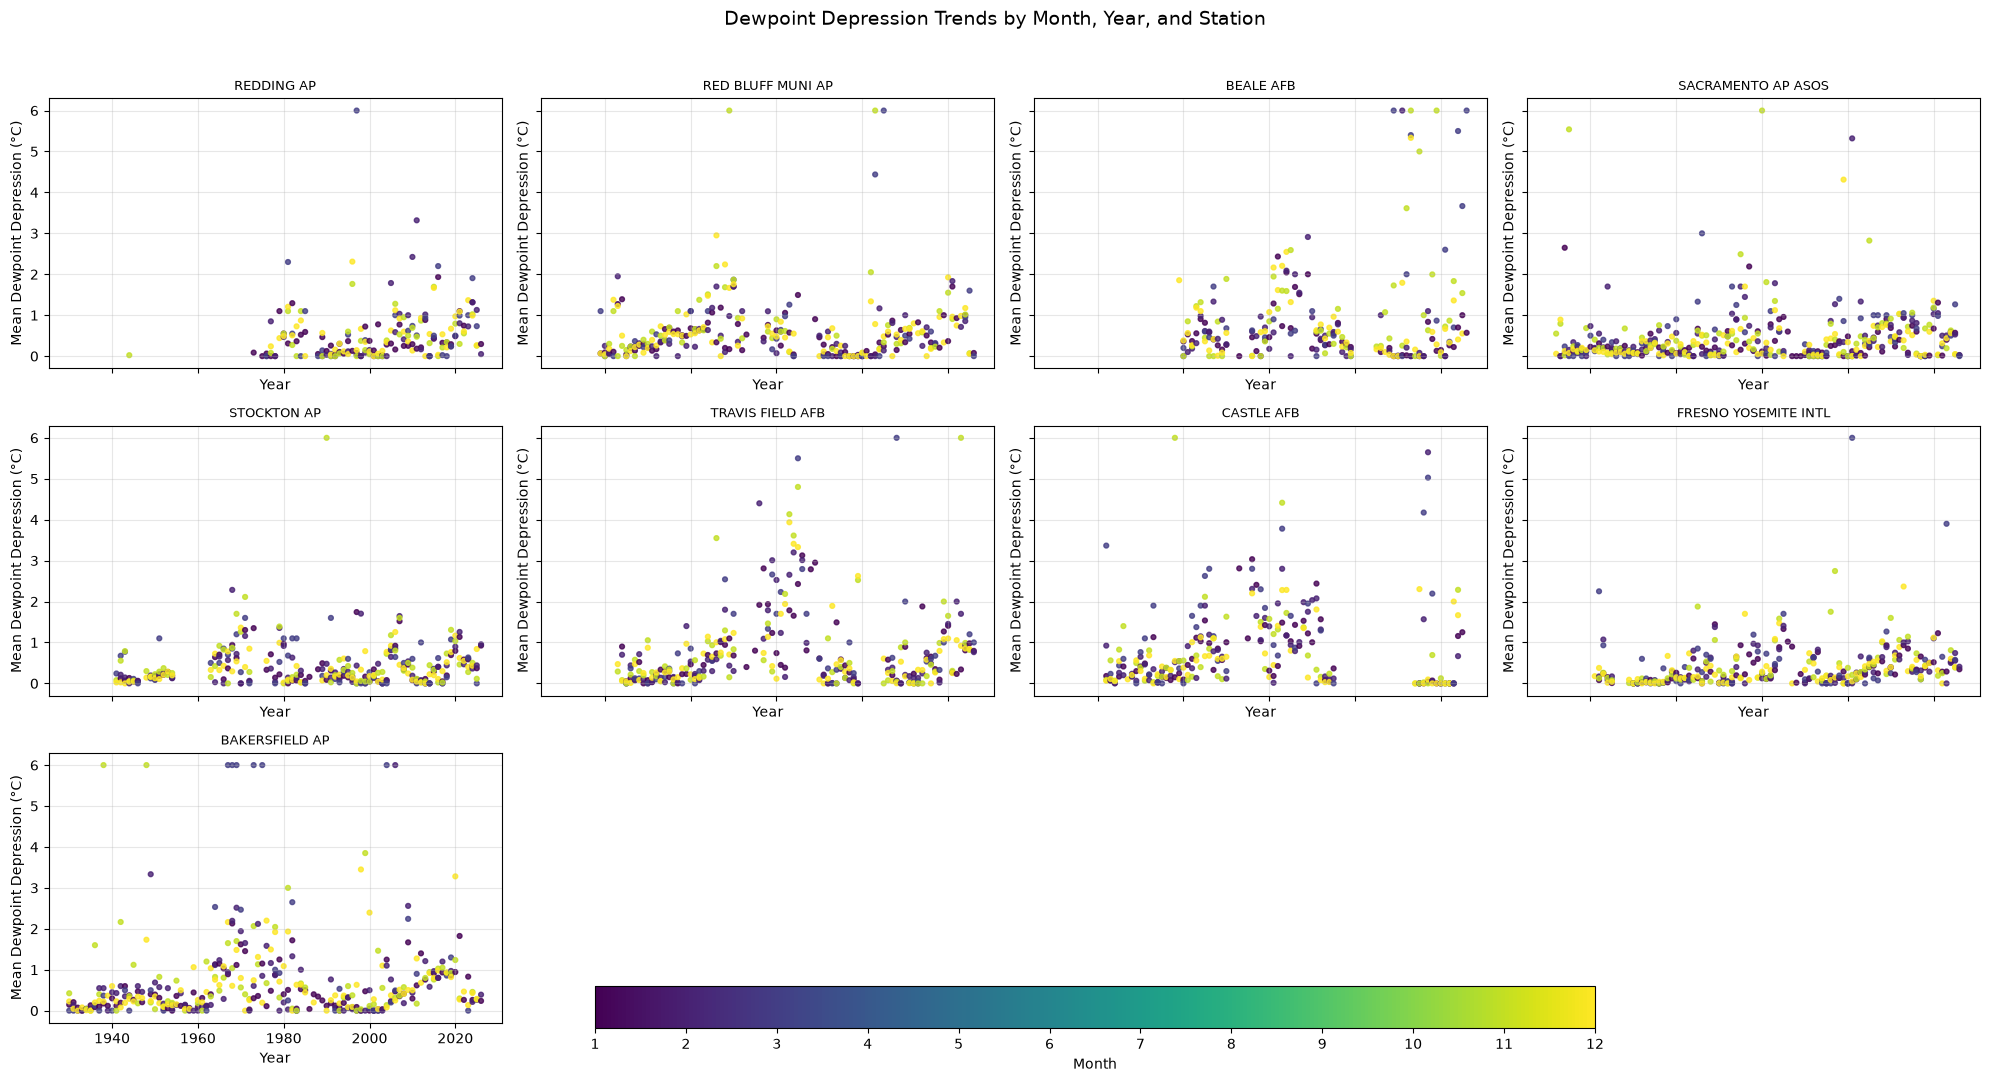

In [46]:
# Monthly mean dewpoint depression by station/year/month
# need to only calculate dewpoint depression if the rows have both temperature and dewpoint values
# # filter out rows without both temperature and dewpoint values
# CV_rows = CV_rows.dropna(subset=["HourlyDryBulbTemperature", "HourlyDewPointTemperature"])

stations = ["REDDING AP", "RED BLUFF MUNI AP", "BEALE AFB", "SACRAMENTO AP ASOS", "STOCKTON AP", "TRAVIS FIELD AFB", "CASTLE AFB", "FRESNO YOSEMITE INTL", "BAKERSFIELD AP"]
n_stations = len(stations)

ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5 * ncols, 3.5 * nrows),
    sharex=True,
    sharey=True
)
axes = np.array(axes).reshape(-1)

for i, station in enumerate(stations):
    ax = axes[i]
    sdata = monthly_station[monthly_station["STATION"] == station]

    ax.scatter(
        sdata["year"],
        sdata["HourlyDewpointDepression"],
        c=sdata["month"],
        cmap="viridis",
        vmin=1,
        vmax=12,
        s=12,
        alpha=0.8
    )
    ax.set_title(station, fontsize=9)
    ax.set_xlabel("Year")
    ax.set_ylabel("Mean Dewpoint Depression (°C)")
    ax.grid(alpha=0.3)

# Hide any unused subplot panels
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

# Shared colorbar for month
# put the colorbar on the bottom right of the figure
# set colorbar to be horizontal and below the subplots  
# Orient the colorbar horizontally and place it below the subplots
smb = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=1, vmax=12))
smb.set_array([])
ax = fig.add_axes([0.3, 0.05, 0.5, 0.04])  # [left, bottom, width, height]
cbar = fig.colorbar(smb, cax=ax, orientation="horizontal")
cbar.set_label("Month")
cbar.set_ticks(range(1, 13))

fig.suptitle("Dewpoint Depression Trends by Month, Year, and Station", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

C:\Users\Work Account\AppData\Local\Temp\ipykernel_9252\2427005990.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


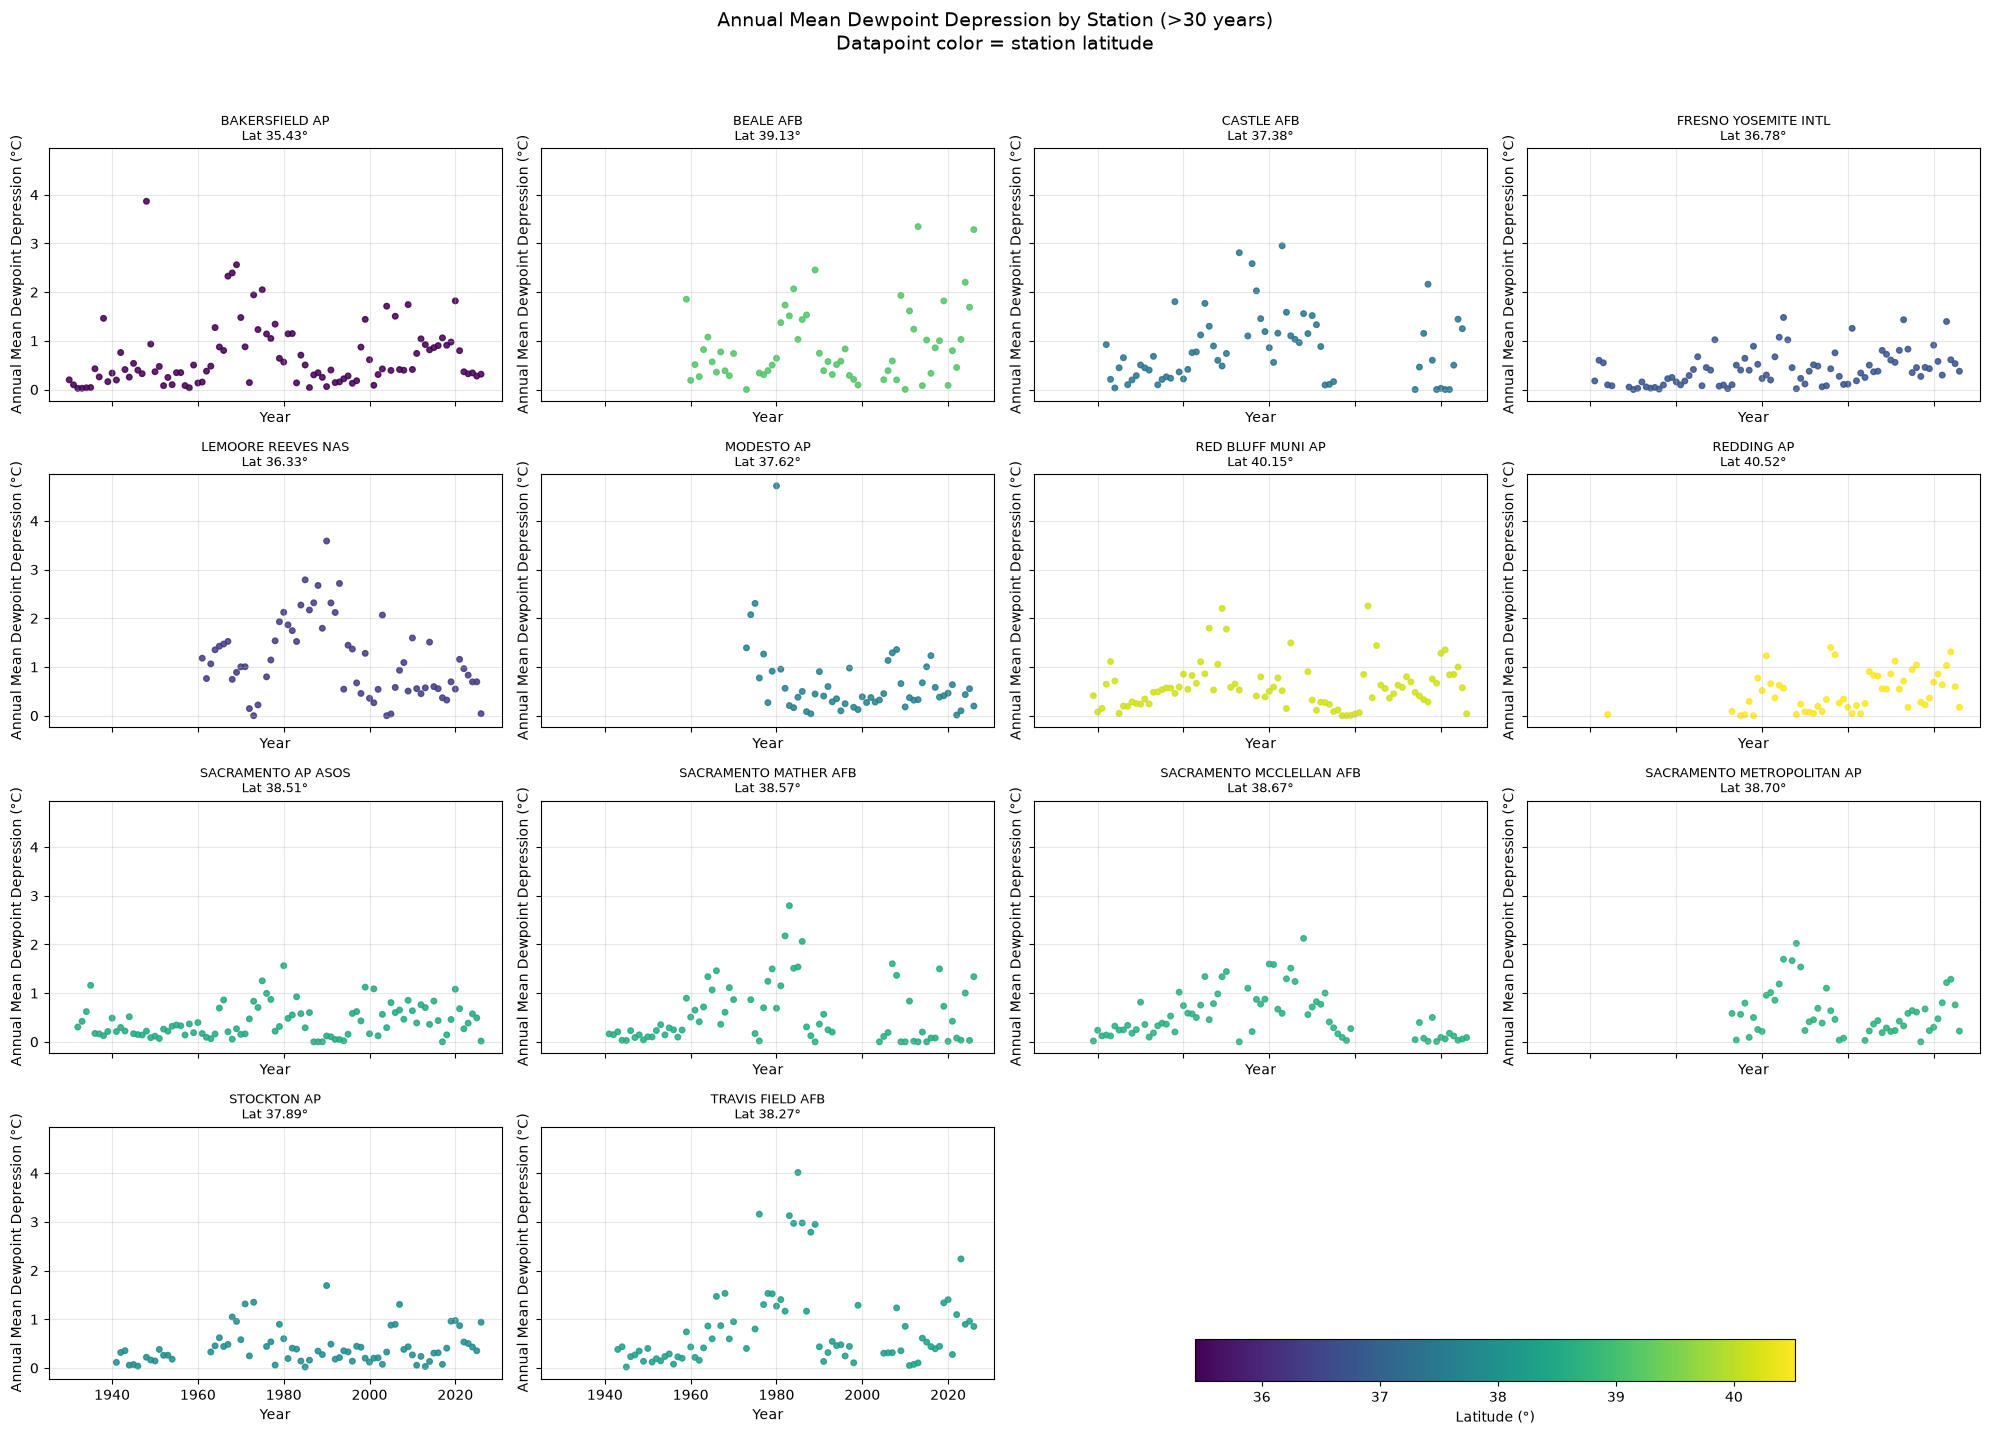

In [59]:
# # Annual mean dewpoint depression by station/year
# annual_station = (
#     monthly_station.groupby(["STATION", "year"], as_index=False)["HourlyDewpointDepression"]
#     .mean()
# )

# # Keep stations with >30 unique years of annual data
# year_counts = annual_station.groupby("STATION")["year"].nunique()
# eligible_stations_30 = year_counts[year_counts > 30].index

annual_station_30 = annual_station[annual_station["STATION"].isin(eligible_stations_30)].copy()

# Station latitude lookup
station_lat = (
    CV_rows[["STATION", "LATITUDE"]]
    .dropna()
    .groupby("STATION", as_index=True)["LATITUDE"]
    .median()
)

annual_station_30["LATITUDE"] = annual_station_30["STATION"].map(station_lat)

# Plot
stations_30 = sorted(annual_station_30["STATION"].dropna().unique())
n_stations_30 = len(stations_30)

if n_stations_30 == 0:
    print("No stations found with more than 30 years of data.")
else:
    ncols = 4
    nrows = int(np.ceil(n_stations_30 / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(5 * ncols, 3.5 * nrows),
        sharex=True,
        sharey=True
    )
    axes = np.array(axes).reshape(-1)

    lat_min = annual_station_30["LATITUDE"].min()
    lat_max = annual_station_30["LATITUDE"].max()
    norm = plt.Normalize(vmin=lat_min, vmax=lat_max)
    cmap = "viridis"

    for idx, station_name in enumerate(stations_30):
        ax = axes[idx]
        g = annual_station_30[annual_station_30["STATION"] == station_name].sort_values("year")
        lat_val = g["LATITUDE"].iloc[0]

        ax.scatter(
            g["year"],
            g["HourlyDewpointDepression"],
            c=np.full(len(g), lat_val),
            cmap=cmap,
            norm=norm,
            s=16,
            alpha=0.85
        )
        ax.set_title(f"{station_name}\nLat {lat_val:.2f}°", fontsize=9)
        ax.set_xlabel("Year")
        ax.set_ylabel("Annual Mean Dewpoint Depression (°C)")
        ax.grid(alpha=0.3)

    for idx in range(n_stations_30, len(axes)):
        axes[idx].axis("off")

    sma = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sma.set_array([])
    ax = fig.add_axes([0.6, 0.04, 0.3, 0.03])  # [left, bottom, width, height]
    cbar = fig.colorbar(sma, cax=ax, orientation="horizontal")
    cbar.set_label("Latitude (°)")

    fig.suptitle(
        "Annual Mean Dewpoint Depression by Station (>30 years)\nDatapoint color = station latitude",
        y=1.02,
        fontsize=14
    )
    plt.tight_layout()
    plt.show()

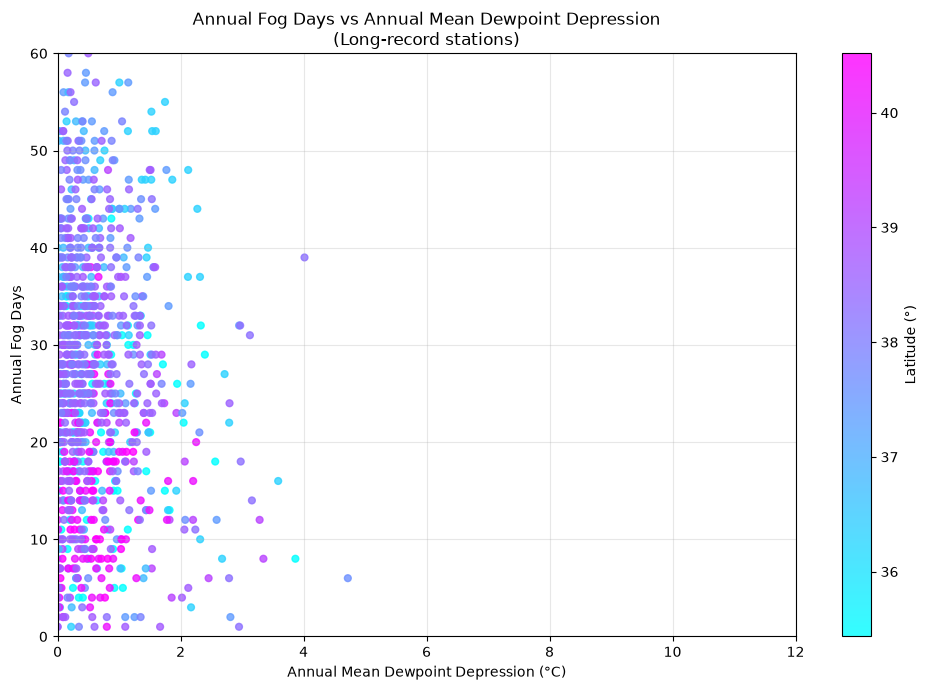

In [60]:
# Annual fog days (unique dates with fog) by station/year
fog_days_annual = (
    CV_fog_rows.assign(fog_date=pd.to_datetime(CV_fog_rows["DATE"], errors="coerce").dt.date)
    .dropna(subset=["fog_date"])
    .groupby(["STATION", "year"], as_index=False)["fog_date"]
    .nunique()
    .rename(columns={"fog_date": "annual_fog_days"})
)

# Keep only stations with long records (as defined above)
long_record_stations = set(eligible_stations_30)
fog_days_annual = fog_days_annual[fog_days_annual["STATION"].isin(long_record_stations)]

# Merge with annual mean dewpoint depression and latitude
plot_df = fog_days_annual.merge(
    annual_station_30[["STATION", "year", "HourlyDewpointDepression", "LATITUDE"]],
    on=["STATION", "year"],
    how="inner"
)

# Scatterplot: annual fog days vs annual mean dewpoint depression, colored by latitude
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(
    plot_df["HourlyDewpointDepression"],
    plot_df["annual_fog_days"],
    c=plot_df["LATITUDE"],
    cmap="cool",  # make colorbar blue to red for north to south
    s=24,
    alpha=0.8
)

plt.xlim(0,12)
plt.ylim(0,60)


ax.set_title("Annual Fog Days vs Annual Mean Dewpoint Depression\n(Long-record stations)")
ax.set_xlabel("Annual Mean Dewpoint Depression (°C)")
ax.set_ylabel("Annual Fog Days")
ax.grid(alpha=0.3)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Latitude (°)")

plt.tight_layout()
plt.show()

Rows before outlier removal: 991
Rows after outlier removal: 937
                            OLS Regression Results                            
Dep. Variable:        annual_fog_days   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.049
Method:                 Least Squares   F-statistic:                     25.16
Date:                Fri, 28 Aug 2026   Prob (F-statistic):           2.29e-11
Time:                        14:52:49   Log-Likelihood:                -3705.1
No. Observations:                 937   AIC:                             7416.
Df Residuals:                     934   BIC:                             7431.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------

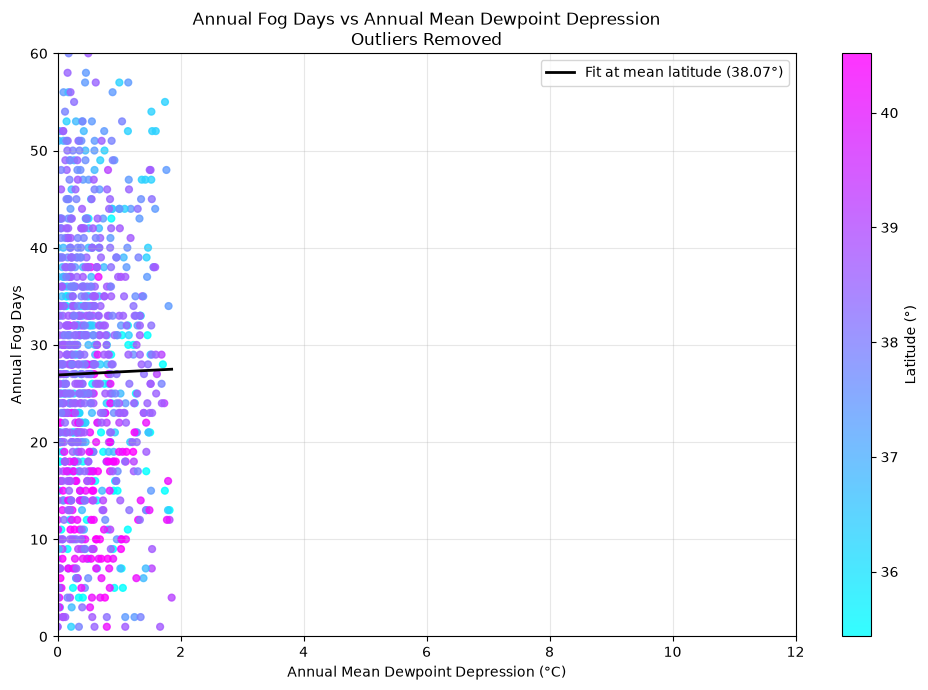

In [61]:
# Remove outliers from plot_df using the IQR rule and fit a linear model

clean_df = plot_df[["HourlyDewpointDepression", "annual_fog_days", "LATITUDE"]].dropna().copy()

for col in ["HourlyDewpointDepression", "annual_fog_days"]:
    q1 = clean_df[col].quantile(0.25)
    q3 = clean_df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    clean_df = clean_df[(clean_df[col] >= lower) & (clean_df[col] <= upper)]

print("Rows before outlier removal:", len(plot_df))
print("Rows after outlier removal:", len(clean_df))

X_clean = sm.add_constant(clean_df[["HourlyDewpointDepression", "LATITUDE"]])
y_clean = clean_df["annual_fog_days"]

clean_model = sm.OLS(y_clean, X_clean).fit()
print(clean_model.summary())

lat_ref_clean = clean_df["LATITUDE"].mean()
dd_range_clean = np.linspace(
    clean_df["HourlyDewpointDepression"].min(),
    clean_df["HourlyDewpointDepression"].max(),
    100
)

pred_clean_df = pd.DataFrame({
    "const": 1.0,
    "HourlyDewpointDepression": dd_range_clean,
    "LATITUDE": lat_ref_clean
})
pred_clean_df["predicted_fog_days"] = clean_model.predict(pred_clean_df)

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(
    clean_df["HourlyDewpointDepression"],
    clean_df["annual_fog_days"],
    c=clean_df["LATITUDE"],
    cmap="cool",
    s=24,
    alpha=0.8
)

ax.plot(
    pred_clean_df["HourlyDewpointDepression"],
    pred_clean_df["predicted_fog_days"],
    color="black",
    linewidth=2,
    label=f"Fit at mean latitude ({lat_ref_clean:.2f}°)"
)

plt.xlim(0,12)
plt.ylim(0,60)

ax.set_title("Annual Fog Days vs Annual Mean Dewpoint Depression\nOutliers Removed")
ax.set_xlabel("Annual Mean Dewpoint Depression (°C)")
ax.set_ylabel("Annual Fog Days")
ax.grid(alpha=0.3)
ax.legend()

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Latitude (°)")

plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:        annual_fog_days   R-squared:                       0.058
Model:                            OLS   Adj. R-squared:                  0.056
Method:                 Least Squares   F-statistic:                     30.41
Date:                Fri, 28 Aug 2026   Prob (F-statistic):           1.53e-13
Time:                        14:52:58   Log-Likelihood:                -3943.6
No. Observations:                 991   AIC:                             7893.
Df Residuals:                     988   BIC:                             7908.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

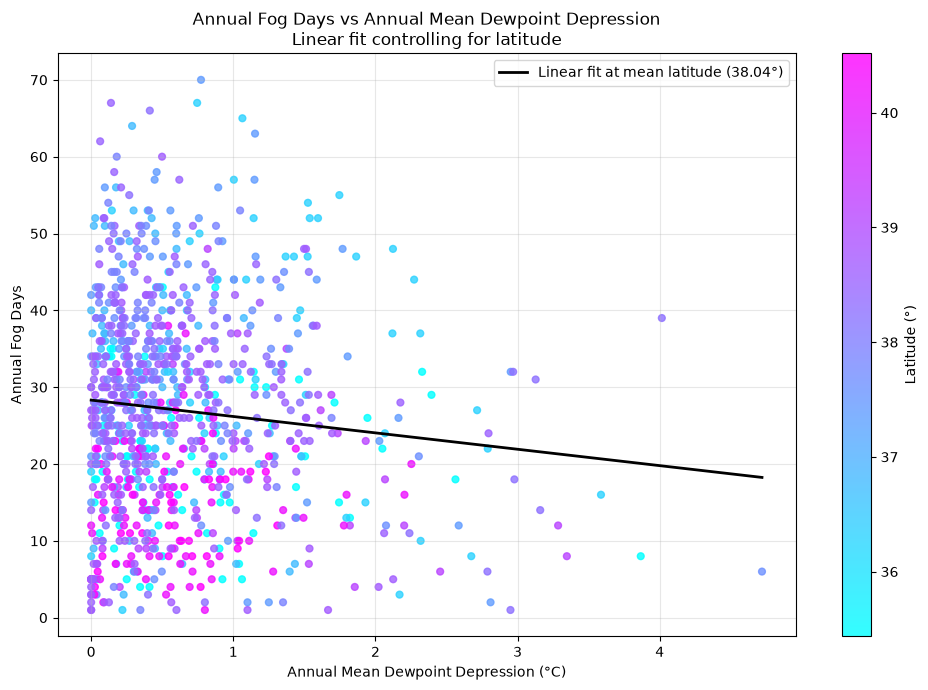

In [62]:
# Multiple linear regression: annual fog days as a function of
# annual mean dewpoint depression and latitude
X_fit = sm.add_constant(plot_df[["HourlyDewpointDepression", "LATITUDE"]])
y_fit = plot_df["annual_fog_days"]

fog_dd_lat_model = sm.OLS(y_fit, X_fit).fit()
print(fog_dd_lat_model.summary())

# Predicted relationship at mean latitude
lat_ref_fit = plot_df["LATITUDE"].mean()
dd_range_fit = np.linspace(
    plot_df["HourlyDewpointDepression"].min(),
    plot_df["HourlyDewpointDepression"].max(),
    100
)

pred_fit_df = pd.DataFrame({
    "const": 1.0,
    "HourlyDewpointDepression": dd_range_fit,
    "LATITUDE": lat_ref_fit
})
pred_fit_df["predicted_fog_days"] = fog_dd_lat_model.predict(pred_fit_df)

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(
    plot_df["HourlyDewpointDepression"],
    plot_df["annual_fog_days"],
    c=plot_df["LATITUDE"],
    cmap="cool",
    s=24,
    alpha=0.8
)

ax.plot(
    pred_fit_df["HourlyDewpointDepression"],
    pred_fit_df["predicted_fog_days"],
    color="black",
    linewidth=2,
    label=f"Linear fit at mean latitude ({lat_ref_fit:.2f}°)"
)

ax.set_title("Annual Fog Days vs Annual Mean Dewpoint Depression\nLinear fit controlling for latitude")
ax.set_xlabel("Annual Mean Dewpoint Depression (°C)")
ax.set_ylabel("Annual Fog Days")
ax.grid(alpha=0.3)
ax.legend()

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Latitude (°)")

plt.tight_layout()
plt.show()